# Winner Complacency: Primary Margins vs General-Election Multipliers (2008, 2016, 2020)

This notebook tests the “winner complacency” story ithin a single election cycle. The core question is: *if one party dominates the primary (in turnout), does that party “scale up” less from the primary to the general election than the other party does?* If so, that would be consistent with a form of complacency: when your side looks safe early, you may not expand your turnout as much in November.

Everything here uses **two-party totals** (Republican + Democratic) and is built from county-level results that have already been cleaned and standardized into one merged file per year. I aggregate counties to the state level for the main model, but I also do a few county-level sanity checks along the way so I’m not building the story on a weird artifact of the data.

A key definition I use throughout is the “primary winner” versus “primary loser.” This is not “who won the nomination." Here, “winner” simply means: *the party with higher total primary turnout in that state-year* (Republican vs Democratic primary totals). The “loser” is the other party. That choice lets me treat the primary as a two-party “strength signal,” then ask how each side scales into the general election.

The main output of the notebook is a set of scatter plots and a small linear model relating:

- the **primary margin** (how lopsided the two-party primary turnout was), and  
- the **general-election multiplier** (general votes divided by primary votes, computed separately for the primary winner and primary loser).

Author: Uyen Nguyen
Last update: Dec 19, 2025

## 0. Import Libraries & Define Data Path

I start by importing the packages I need for data manipulation and plotting, then I point to the processed `merged.csv` files for each election year. The notebook assumes the cleaning/ETL has already produced standardized columns like `rep_primary_total`, `dem_primary_total`, `rep_general_total`, and `dem_general_total` at the county level.

Even if a few imports look “extra” (e.g., optimization utilities), I keep them here because I experimented with multiple model forms while building this notebook. The actual multiplier model used at the end relies mainly on NumPy, pandas, matplotlib, and a small least-squares fit.


In [2]:
# Import necessary libraries
import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from scipy.special import expit  # logistic function
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

# Matplotlib defaults
plt.rcParams["figure.dpi"] = 140
plt.rcParams["figure.figsize"] = (10, 6)

/Users/amourtu1934/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


I keep the imports grouped because the notebook mixes three kinds of work: data manipulation (pandas/NumPy), visualization (matplotlib), and light-weight regression fitting (scikit-learn). The multiplier model at the end is solved with a plain least-squares system, so it stays transparent and easy to audit.


In [3]:
# Data path
DATA_DIR_2008 = Path("../../data/processed/2008")
DATA_DIR_2016 = Path("../../data/processed/2016")
DATA_DIR_2020 = Path("../../data/processed/2020")

FILE_PATH_2008 = DATA_DIR_2008 / "merged.csv"
FILE_PATH_2016 = DATA_DIR_2016 / "merged.csv"
FILE_PATH_2020 = DATA_DIR_2020 / "merged.csv"

The `merged.csv` files under `data/processed/<year>/` are assumed to be the standardized outputs of my cleaning pipeline. At minimum, each row corresponds to a county (or equivalent unit) with a state identifier and two-party vote totals for primary and general elections. Using a single merged file per year keeps the analysis code short and makes it easy to swap in new years later.


## 1. Data Processing

In this section I load the cleaned county-level data for each year and collapse it to state totals. That gives me consistent state-level totals for the Republican and Democratic primaries and generals, plus two-party shares and the primary margin I use later.

Before I do any modeling, I want the state-level table in a clean, comparable format across years. The workflow for 2008, 2016, and 2020 is intentionally the same:

I read the merged county-level file, create two-party totals for the primary and general, then aggregate counties to the state level by summing vote totals. From there, I compute two-party shares (Republican share and Democratic share) for both the primary and general, and I compute a single summary statistic per state-year: the **primary margin**.

The **primary margin** is defined as the absolute difference between the Democratic and Republican *primary* two-party shares. Values near 0 mean the two parties had similar primary turnout; values closer to 0.5 mean one party dominated the primary turnout in that state-year.


### 1.1. 2008 Presidential Election

We load the merged county-level dataset for 2008. Each row is a county-precinct observation with Republican and Democratic totals in both the primary and general.

In [12]:
# Read in the merged CSV file for 2008
dt_2008 = pd.read_csv(FILE_PATH_2008)
dt_2008.head(10)

,state,county,rep_general_total,dem_general_total,rep_primary_total,dem_primary_total,rep_primary_share,rep_general_share,primary_total_votes,general_total_votes
0,AZ,Apache,8551.0,15390.0,2361.0,6481.0,0.267021,0.357170,8842.0,23941.0
1,AZ,Cochise,29026.0,18943.0,10699.0,9393.0,0.532500,0.605099,20092.0,47969.0
2,AZ,Coconino,22186.0,31433.0,8281.0,12050.0,0.407309,0.413771,20331.0,53619.0
3,AZ,Gila,14095.0,7884.0,6046.0,5852.0,0.508153,0.641294,11898.0,21979.0
4,AZ,Graham,8376.0,3487.0,2801.0,2244.0,0.555203,0.706061,5045.0,11863.0
5,AZ,Greenlee,1712.0,1165.0,368.0,1142.0,0.243709,0.595064,1510.0,2877.0
6,AZ,La Paz,3509.0,1929.0,1332.0,1041.0,0.561315,0.645274,2373.0,5438.0
7,AZ,Maricopa,746448.0,602166.0,350246.0,253985.0,0.579656,0.553493,604231.0,1348614.0
8,AZ,Mohave,44333.0,22092.0,17511.0,10679.0,0.621178,0.667414,28190.0,66425.0
9,AZ,Navajo,19761.0,15579.0,7579.0,7472.0,0.503555,0.559168,15051.0,35340.0


This loads the already-cleaned county-level dataset for 2008. A quick `.head()` here is not just cosmetic: I use it to confirm column names and to spot the usual data issues early (unexpected NaNs, weird state codes, totals accidentally stored as strings, etc.).


In [13]:
# Add the primary and general total votes
dt_2008['primary_total_votes'] = dt_2008['rep_primary_total'] + dt_2008['dem_primary_total']
dt_2008['general_total_votes'] = dt_2008['rep_general_total'] + dt_2008['dem_general_total']

I create two additional “sanity” columns: the total two-party primary turnout and the total two-party general turnout. These totals become the denominators when I compute shares, and they also let me build county-level diagnostics (like primary vs general turnout) without mixing parties.


In [14]:
# Aggregate to state level
state_2008 = (
    dt_2008.groupby('state', as_index=False)
            .agg({
                'rep_primary_total': 'sum',
                'dem_primary_total': 'sum',
                'rep_general_total': 'sum',
                'dem_general_total': 'sum',
            })
)

# Calculate totals and shares at state level
state_2008['primary_total_votes'] = (
    state_2008['rep_primary_total'] + state_2008['dem_primary_total']
)
state_2008['general_total_votes'] = (
    state_2008['rep_general_total'] + state_2008['dem_general_total']
)

state_2008['rep_primary_share'] = state_2008['rep_primary_total'] / state_2008['primary_total_votes']
state_2008['dem_primary_share'] = state_2008['dem_primary_total'] / state_2008['primary_total_votes']
state_2008['rep_general_share'] = state_2008['rep_general_total'] / state_2008['general_total_votes']
state_2008['dem_general_share'] = state_2008['dem_general_total'] / state_2008['general_total_votes']

# Calculate the absolute margin in the primary
state_2008['primary_margin'] = np.abs(
    state_2008['dem_primary_share'] - state_2008['rep_primary_share']
)

state_2008.head(10)

,state,rep_primary_total,dem_primary_total,rep_general_total,dem_general_total,primary_total_votes,general_total_votes,rep_primary_share,dem_primary_share,rep_general_share,dem_general_share,primary_margin
0,AZ,541035.0,455635.0,1230111.0,1034707.0,996670.0,2264818.0,0.542843,0.457157,0.543139,0.456861,0.085685
1,DE,100474.0,192682.0,304748.0,510918.0,293156.0,815666.0,0.342732,0.657268,0.373619,0.626381,0.314536
2,GA,963541.0,1060851.0,2048759.0,1844123.0,2024392.0,3892882.0,0.475966,0.524034,0.526283,0.473717,0.048069
3,ID,117245.0,40836.0,403012.0,236440.0,158081.0,639452.0,0.741677,0.258323,0.630246,0.369754,0.483353
4,IL,899422.0,2038614.0,2031179.0,3419348.0,2938036.0,5450527.0,0.306130,0.693870,0.372657,0.627343,0.387739
5,IN,412684.0,1278355.0,1345649.0,1374039.0,1691039.0,2719688.0,0.244042,0.755958,0.494781,0.505219,0.511917
6,LA,161169.0,384346.0,1148275.0,782989.0,545515.0,1931264.0,0.295444,0.704556,0.594572,0.405428,0.409112
7,MA,497059.0,1247603.0,1108854.0,1904097.0,1744662.0,3012951.0,0.284903,0.715097,0.368029,0.631971,0.430195
8,MT,95730.0,182421.0,242763.0,231667.0,278151.0,474430.0,0.344166,0.655834,0.511694,0.488306,0.311669
9,OH,1045624.0,2354721.0,2677820.0,2940044.0,3400345.0,5617864.0,0.307505,0.692495,0.476662,0.523338,0.384989


Here I collapse counties to the state level by summing each party’s total votes. After aggregation, I compute two-party shares within the primary and within the general. The `primary_margin` is the absolute difference between Democratic and Republican primary shares, so it is always between 0 and 1 (and practically between 0 and 0.5 for two-party shares). This single number is the main “how lopsided was the primary?” variable used later.


At this point, each row is a state and each column is a two-party total or share. The main thing I need from this table later is:

the primary margin (how lopsided the primary turnout was across parties) and the party-specific primary/general totals that let me build the multiplier ratio.

I treat third parties and write-ins as outside the scope here, because I’m explicitly trying to track how the *two major party coalitions* scale from primary to general. If I later want to talk about third-party effects, I would do that as a separate robustness check.


### 1.2. 2016 Presidential Election

In [15]:
# Read in the merged CSV file for 2016
dt_2016 = pd.read_csv(FILE_PATH_2016)
dt_2016.head(10)

/var/folders/10/yh5g9ksn5fb_2pzdwtzd2tlh0000gn/T/ipykernel_23346/4057115596.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  dt_2016 = pd.read_csv(FILE_PATH_2016)


,state,geography,rep_general_total,dem_general_total,rep_primary_total,dem_primary_total,precinct,rep_primary_share,rep_general_share
0,GA,APPLING1B,685.0,92.0,382.0,37.0,NaN,0.911695,0.881596
1,GA,APPLING1C,496.0,42.0,303.0,20.0,NaN,0.938080,0.921933
2,GA,APPLING2,427.0,742.0,206.0,329.0,NaN,0.385047,0.365269
3,GA,APPLING3A,209.0,4.0,116.0,4.0,NaN,0.966667,0.981221
4,GA,APPLING3A1,319.0,17.0,180.0,17.0,NaN,0.913706,0.949405
5,GA,APPLING3B,101.0,98.0,73.0,47.0,NaN,0.608333,0.507538
6,GA,APPLING3C,670.0,154.0,392.0,70.0,NaN,0.848485,0.813107
7,GA,APPLING4A,261.0,14.0,145.0,7.0,NaN,0.953947,0.949091
8,GA,APPLING4B,305.0,7.0,195.0,4.0,NaN,0.979899,0.977564
9,GA,APPLING4C,284.0,10.0,168.0,5.0,NaN,0.971098,0.965986


I repeat the same read step for 2016. Keeping the input format identical year-to-year is important: if I change column meanings between years, the multipliers would stop being comparable.


In [16]:
# Add the primary and general total votes
dt_2016['primary_total_votes'] = dt_2016['rep_primary_total'] + dt_2016['dem_primary_total']
dt_2016['general_total_votes'] = dt_2016['rep_general_total'] + dt_2016['dem_general_total']

Again I compute two-party totals at the county level. Even though the main multiplier model is state-level, doing the totals at the county level first makes the exploratory plots straightforward and ensures the aggregation step is a clean sum of comparable quantities.


In [17]:
# Aggregate to state level
state_2016 = (
    dt_2016.groupby('state', as_index=False)
            .agg({
                'rep_primary_total': 'sum',
                'dem_primary_total': 'sum',
                'rep_general_total': 'sum',
                'dem_general_total': 'sum',
            })
)

# Calculate totals and shares at state level
state_2016['primary_total_votes'] = (state_2016['rep_primary_total'] + state_2016['dem_primary_total'])
state_2016['general_total_votes'] = (state_2016['rep_general_total'] + state_2016['dem_general_total'])

state_2016['rep_primary_share'] = state_2016['rep_primary_total'] / state_2016['primary_total_votes']
state_2016['dem_primary_share'] = state_2016['dem_primary_total'] / state_2016['primary_total_votes']
state_2016['rep_general_share'] = state_2016['rep_general_total'] / state_2016['general_total_votes']
state_2016['dem_general_share'] = state_2016['dem_general_total'] / state_2016['general_total_votes']

# Calculate the absolute margin in the primary
state_2016['primary_margin'] = np.abs(
    state_2016['dem_primary_share'] - state_2016['rep_primary_share']
)

# Drop states with zero primary totals if any (e.g., missing data)
state_2016 = state_2016[state_2016['primary_total_votes'] > 0]

state_2016.head(10)

,state,rep_primary_total,dem_primary_total,rep_general_total,dem_general_total,primary_total_votes,general_total_votes,rep_primary_share,dem_primary_share,rep_general_share,dem_general_share,primary_margin
0,AL,808732.0,373498.0,1250017.0,694195.0,1182230.0,1944212.0,0.684073,0.315927,0.642943,0.357057,0.368147
1,AR,378047.0,208305.0,622222.0,356251.0,586352.0,978473.0,0.644744,0.355256,0.635911,0.364089,0.289488
2,CA,2015766.0,4806070.0,3996488.0,7978051.0,6821836.0,11974539.0,0.295487,0.704513,0.333749,0.666251,0.409025
3,FL,2223370.0,1622844.0,4505168.0,4399608.0,3846214.0,8904776.0,0.578067,0.421933,0.505927,0.494073,0.156134
4,GA,2570377.0,1510889.0,4153229.0,3717038.0,4081266.0,7870267.0,0.629799,0.370201,0.527711,0.472289,0.259598
6,MD,372516.0,641954.0,654730.0,897203.0,1014470.0,1551933.0,0.367203,0.632797,0.421880,0.578120,0.265595
7,MS,428427.0,228872.0,724068.0,493012.0,657299.0,1217080.0,0.651799,0.348201,0.594922,0.405078,0.303599
8,MT,145022.0,117062.0,270838.0,172698.0,262084.0,443536.0,0.553342,0.446658,0.610634,0.389366,0.106683
9,NC,1133982.0,1097885.0,2334585.0,2171288.0,2231867.0,4505873.0,0.508087,0.491913,0.518120,0.481880,0.016173
10,NM,104627.0,216075.0,319667.0,385234.0,320702.0,704901.0,0.326244,0.673756,0.453492,0.546508,0.347513


This is the 2016 mirror of the 2008 aggregation: sum counties to states, compute two-party shares, then compute the absolute primary margin. At the end of this step, `state_2016` has the same schema as `state_2008`, which lets the modeling code treat years uniformly.


We repeat exactly the same aggregation for 2016, so the columns and definitions match 2008. Keeping the pipeline identical is important here: I want differences across years to come from electoral dynamics, not from “I cleaned the data differently in 2016.”


### 1.3. 2020 Presidential Election

2020 uses the same end goal (a standardized merged file per year), but the upstream reality is messier: states report results in different formats, and the cycle is affected by unusual turnout conditions. In this notebook I treat `merged.csv` for 2020 as the post-ETL output, then I apply the same aggregation logic as 2008 and 2016 so the downstream analysis is apples-to-apples.


In [18]:
# Read in the merged CSV file for 2020
dt_2020 = pd.read_csv(FILE_PATH_2020)
dt_2020.head(10)

,state,county,rep_general_total,dem_general_total,rep_primary_total,dem_primary_total,rep_primary_share,rep_general_share,primary_total_votes,general_total_votes
0,AL,Autauga,19838,7503,10080.0,3593.0,0.737219,0.725577,13673.0,27341
1,AL,Baldwin,83544,24578,41138.0,12651.0,0.764803,0.772683,53789.0,108122
2,AL,Barbour,5622,4816,2807.0,2581.0,0.520973,0.538609,5388.0,10438
3,AL,Bibb,7525,1986,4086.0,1010.0,0.801805,0.791189,5096.0,9511
4,AL,Blount,24711,2640,13168.0,1304.0,0.909895,0.903477,14472.0,27351
5,AL,Bullock,1146,3446,431.0,2393.0,0.152620,0.249564,2824.0,4592
6,AL,Calhoun,35101,15216,17103.0,7968.0,0.682183,0.697597,25071.0,50317
7,AL,Chambers,8753,6365,4257.0,2834.0,0.600338,0.578979,7091.0,15118
8,AL,Cherokee,10583,1624,5869.0,858.0,0.872454,0.866962,6727.0,12207
9,AL,Chilton,16085,3073,9174.0,1385.0,0.868832,0.839597,10559.0,19158


For 2020 I start from the same standardized merged file. The `.head()` check matters even more here because 2020 cleaning is typically the most heterogeneous across states (different reporting, uncontested primaries, and different vote categories).


In [19]:
# Add the primary and general total votes
dt_2020['primary_total_votes'] = dt_2020['rep_primary_total'] + dt_2020['dem_primary_total']
dt_2020['general_total_votes'] = dt_2020['rep_general_total'] + dt_2020['dem_general_total']

Two-party primary and general totals are added at the county level again. This makes the later diagnostics (histograms and county-level regressions) consistent across all three years.


In [20]:
# Aggregate to state level
state_2020 = (
    dt_2020.groupby('state', as_index=False)
            .agg({
                'rep_primary_total': 'sum',
                'dem_primary_total': 'sum',
                'rep_general_total': 'sum',
                'dem_general_total': 'sum',
            })
)

# Calculate totals and shares at state level
state_2020['primary_total_votes'] = (state_2020['rep_primary_total'] + state_2020['dem_primary_total'])
state_2020['general_total_votes'] = (state_2020['rep_general_total'] + state_2020['dem_general_total'])

state_2020['rep_primary_share'] = state_2020['rep_primary_total'] / state_2020['primary_total_votes']
state_2020['dem_primary_share'] = state_2020['dem_primary_total'] / state_2020['primary_total_votes']
state_2020['rep_general_share'] = state_2020['rep_general_total'] / state_2020['general_total_votes']
state_2020['dem_general_share'] = state_2020['dem_general_total'] / state_2020['general_total_votes']

# Calculate the absolute margin in the primary
state_2020['primary_margin'] = np.abs(
    state_2020['dem_primary_share'] - state_2020['rep_primary_share']
)

# Drop states with zero primary totals if any (e.g., missing data)
state_2020 = state_2020[state_2020['primary_total_votes'] > 0]

state_2020.head(20)

,state,rep_primary_total,dem_primary_total,rep_general_total,dem_general_total,primary_total_votes,general_total_votes,rep_primary_share,dem_primary_share,rep_general_share,dem_general_share,primary_margin
0,AL,728058.0,453197.0,1434114,841011,1181255.0,2275125,0.616343,0.383657,0.630345,0.369655,0.232686
1,AR,136090.0,132321.0,760647,423932,268411.0,1184579,0.507021,0.492979,0.642124,0.357876,0.014042
2,CO,681623.0,960128.0,1364607,1804352,1641751.0,3168959,0.415180,0.584820,0.430617,0.569383,0.169639
3,CT,91451.0,264416.0,715291,1080680,355867.0,1795971,0.256981,0.743019,0.398275,0.601725,0.486038
4,DE,200603.0,296267.0,200603,296268,496870.0,496871,0.403733,0.596267,0.403733,0.596267,0.192533
5,GA,947341.0,1086564.0,2461837,2474507,2033905.0,4936344,0.465774,0.534226,0.498717,0.501283,0.068451
6,ID,92736.0,98512.0,549965,285948,191248.0,835913,0.484899,0.515101,0.657921,0.342079,0.030202
7,IN,549246.0,497927.0,2422802,1587645,1047173.0,4010447,0.524504,0.475496,0.604123,0.395877,0.049007
8,MA,274760.0,1414119.0,1167202,2382202,1688879.0,3549404,0.162688,0.837312,0.328845,0.671155,0.674624
9,MS,245381.0,274391.0,756764,539398,519772.0,1296162,0.472094,0.527906,0.583850,0.416150,0.055813


I aggregate 2020 counties up to the state level and compute shares and the primary margin in the same way as 2008/2016. This is the point where I enforce comparability: whatever upstream complexity exists in 2020, the downstream model sees the same set of state-level inputs.


## 2. Exploratory Check

Before the multiplier model, I run a few quick diagnostics. The goal here is not to “prove the model,” but to make sure the data behaves in a way that makes the later ratios meaningful.

I look at (1) the distribution of county-level general-election totals by state (mostly to see how skewed it is and how much a few large counties dominate), and (2) a simple county-level linear relationship between primary total votes and general total votes. If primary turnout is completely unrelated to general turnout, then using primary totals as a baseline for “how big each side is” would be questionable.


In [21]:
def freedman_diaconis_bins(data: np.ndarray, default_bins: int = 10) -> int:
    """Compute the number of histogram bins using the Freedman--Diaconis rule.
    Falls back to default_bins if the data are too small or degenerate.
    """
    data = np.asarray(data)
    data = data[~np.isnan(data)]
    if data.size <= 1:
        return 1
    q25, q75 = np.percentile(data, [25, 75])
    iqr = q75 - q25
    if iqr <= 0:
        return default_bins
    bin_width = 2 * iqr / (data.size ** (1/3))
    if bin_width <= 0:
        return default_bins
    bins = int(np.ceil((data.max() - data.min()) / bin_width))
    return max(bins, 1)

I use the Freedman–Diaconis rule to choose histogram bin widths in a way that adapts to sample size and spread. Counties-per-state varies a lot (compare Delaware vs Texas), so fixed bins can make histograms visually misleading. A data-adaptive bin choice gives me a more honest “shape check” across states.


### 2.1. 2008 Presidential Election

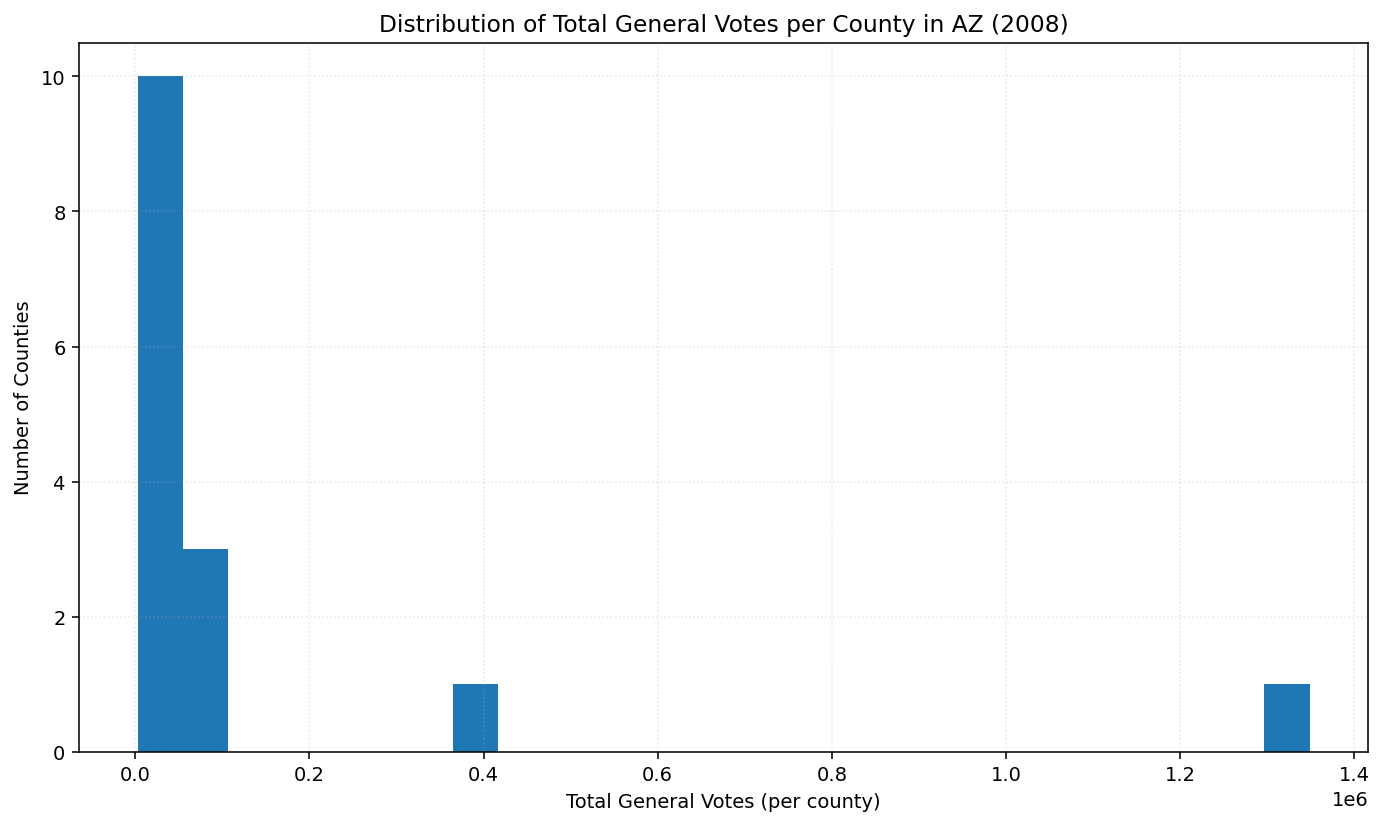

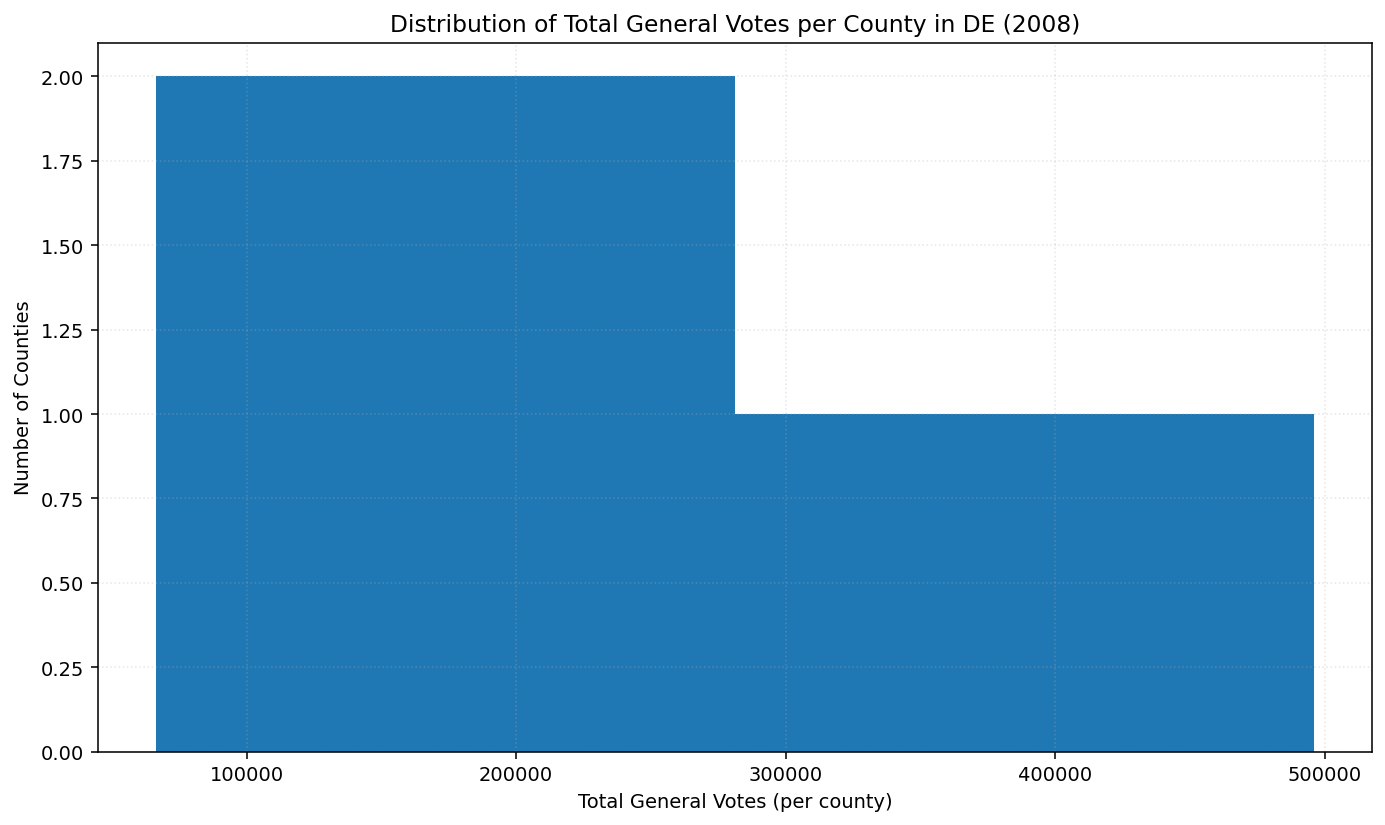

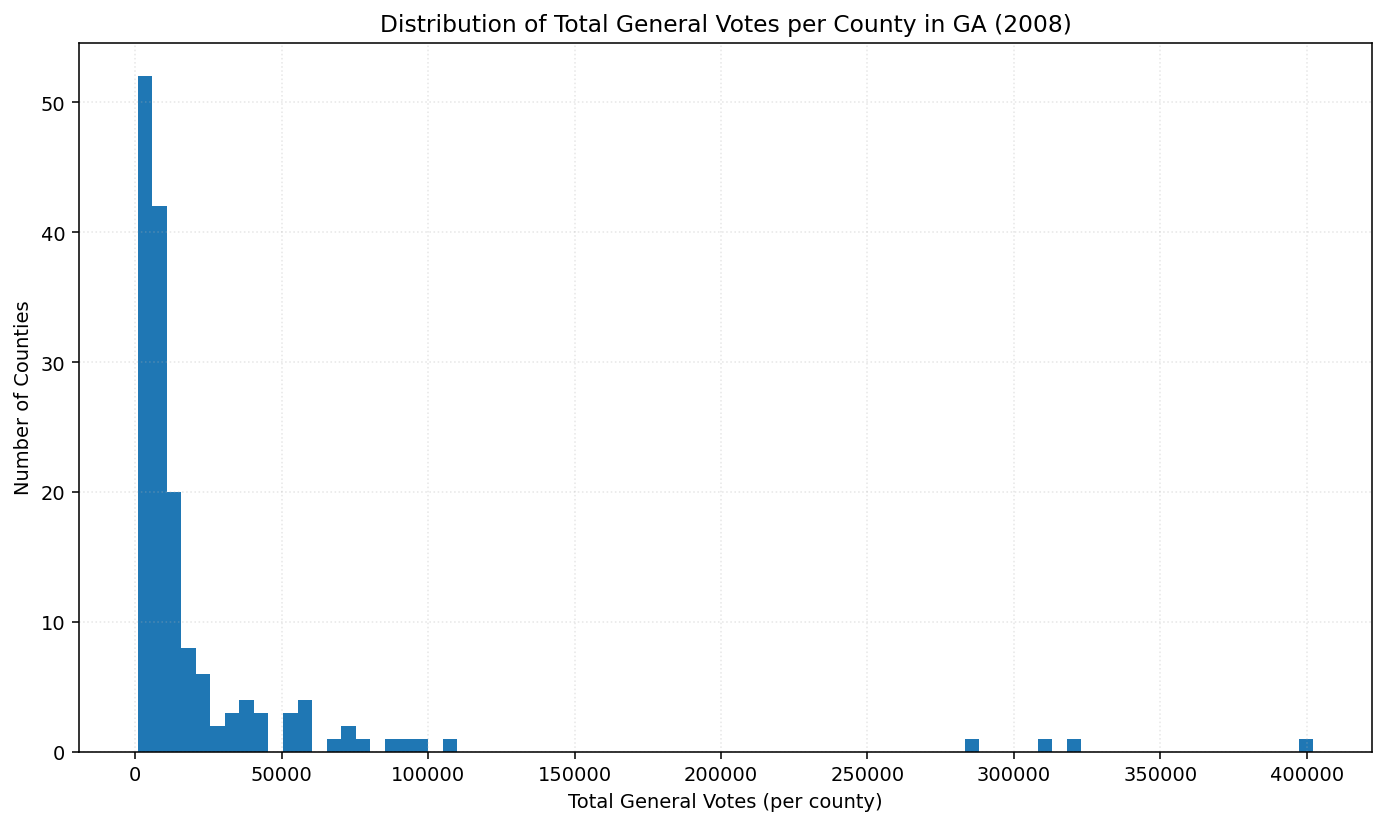

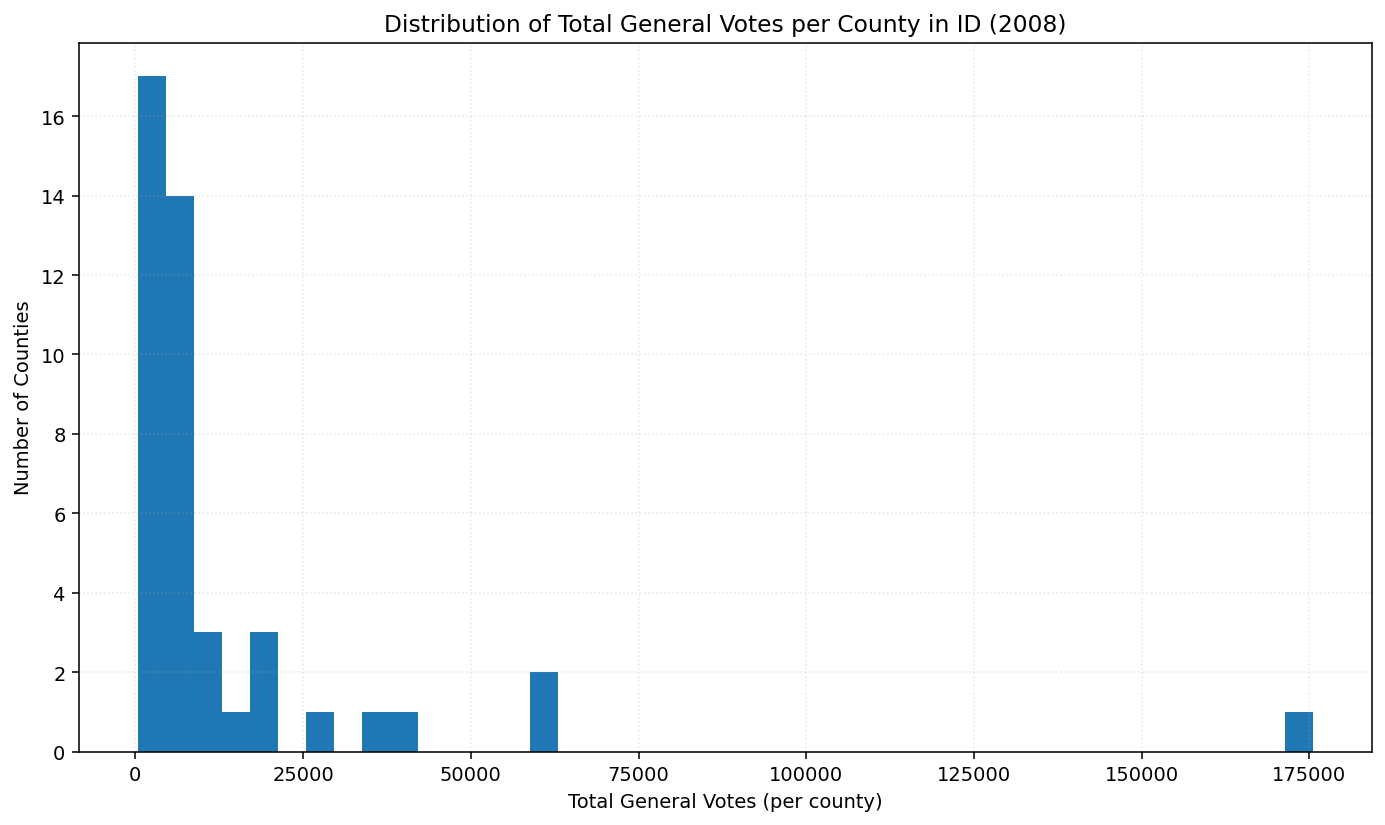

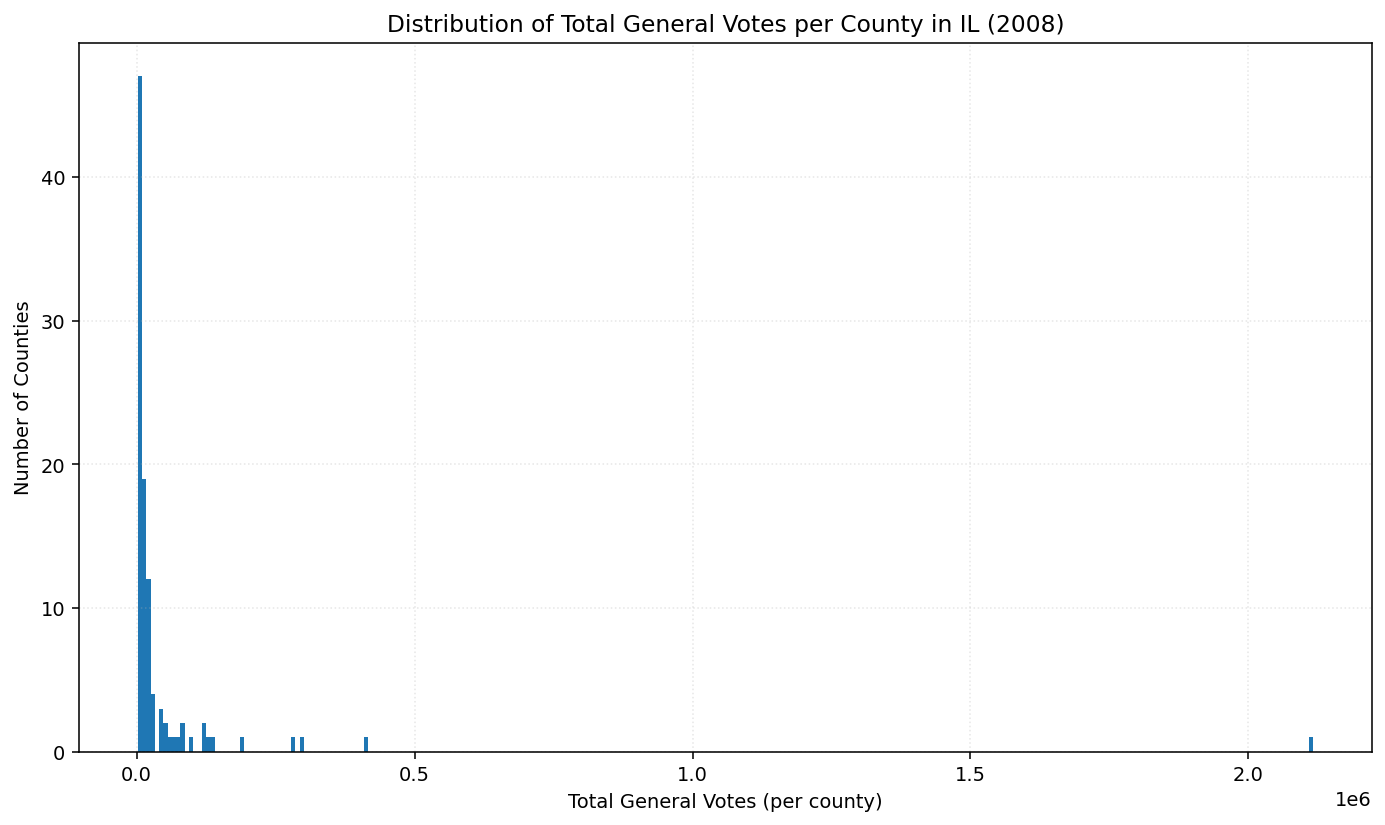

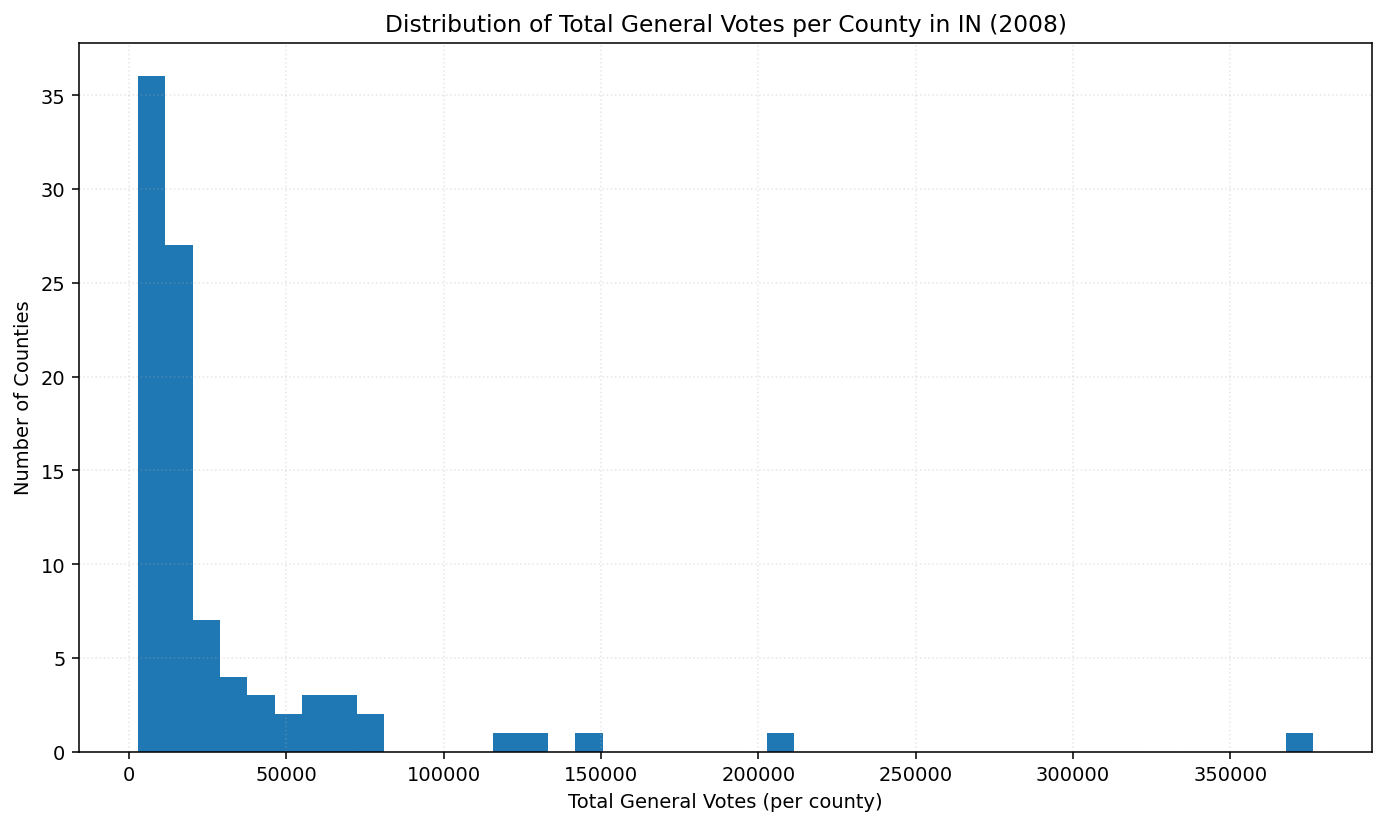

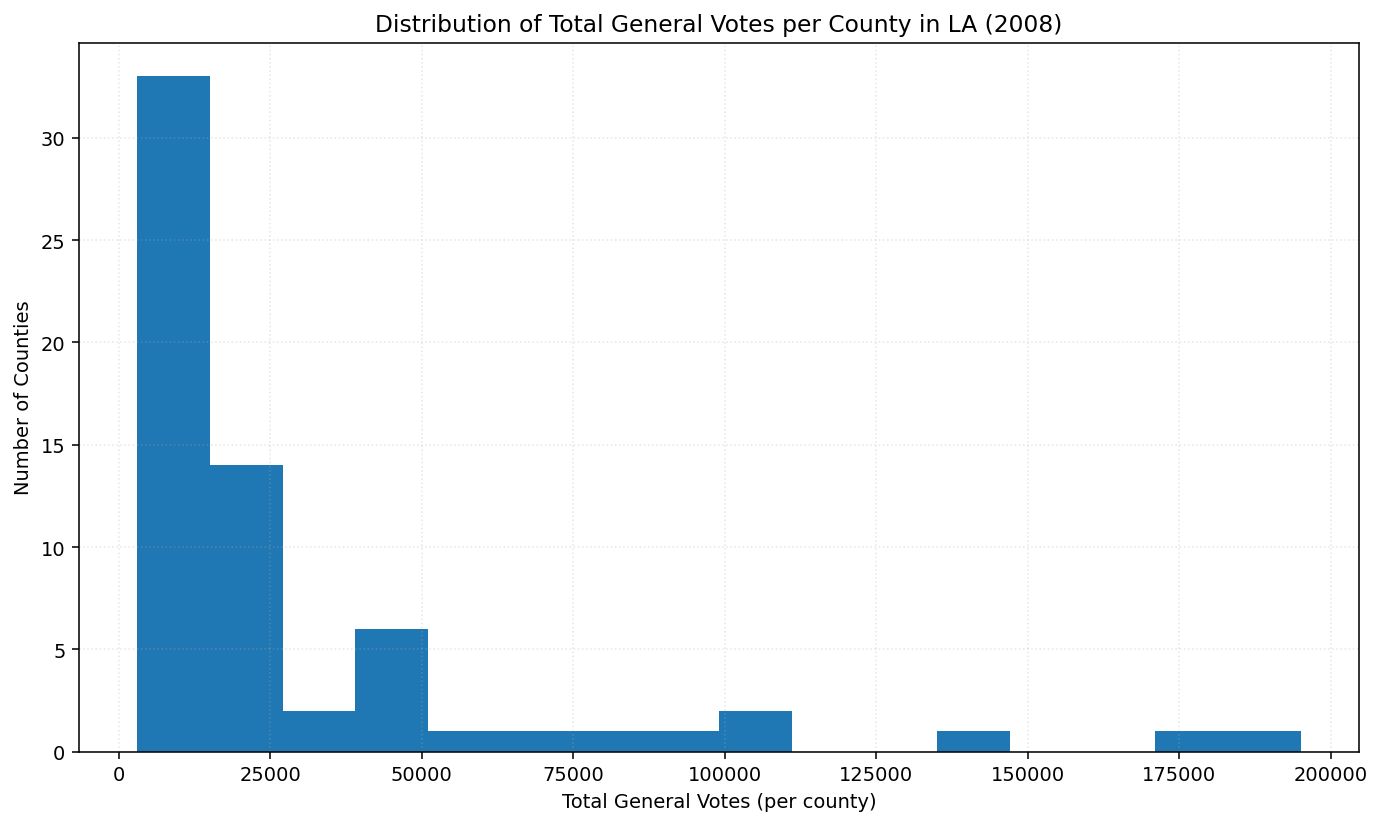

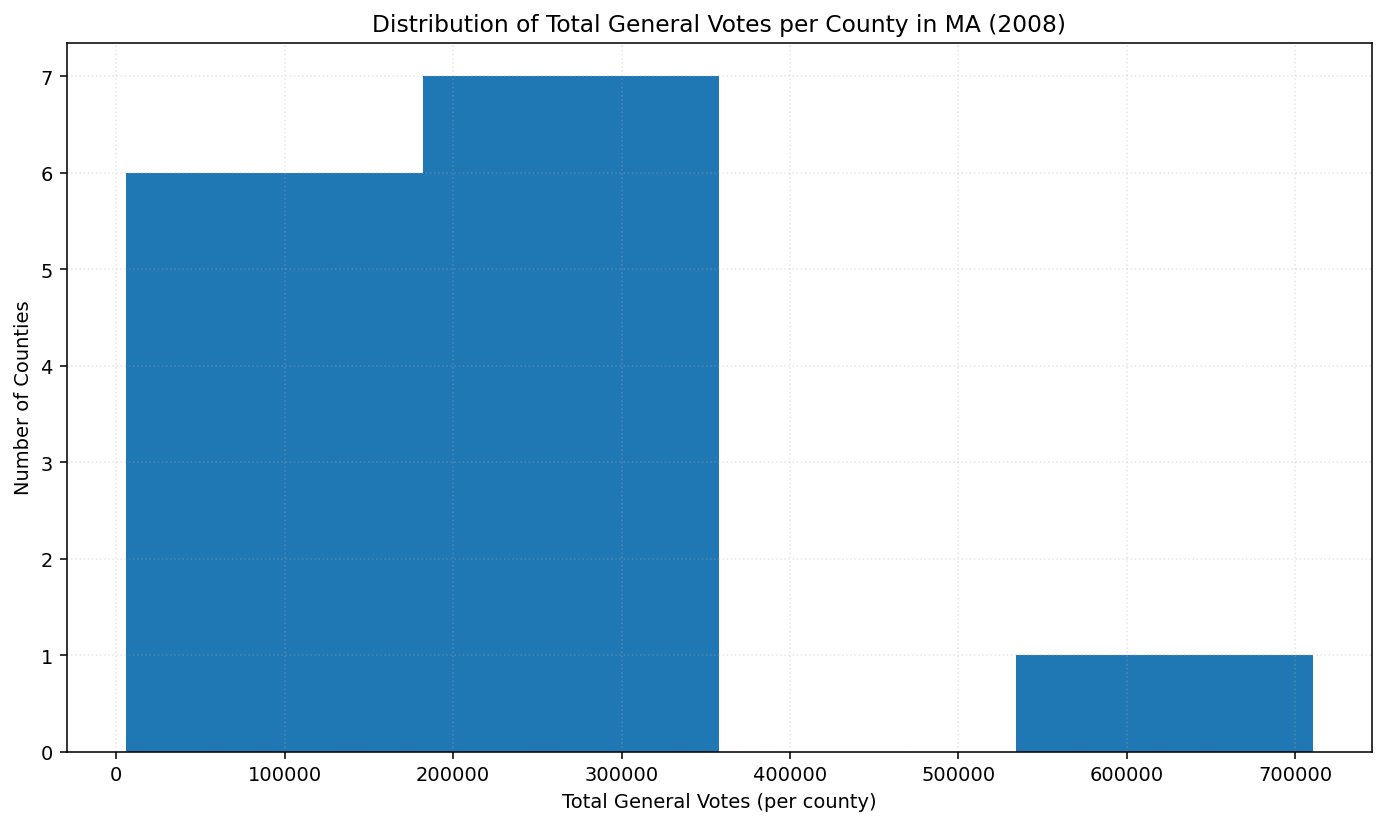

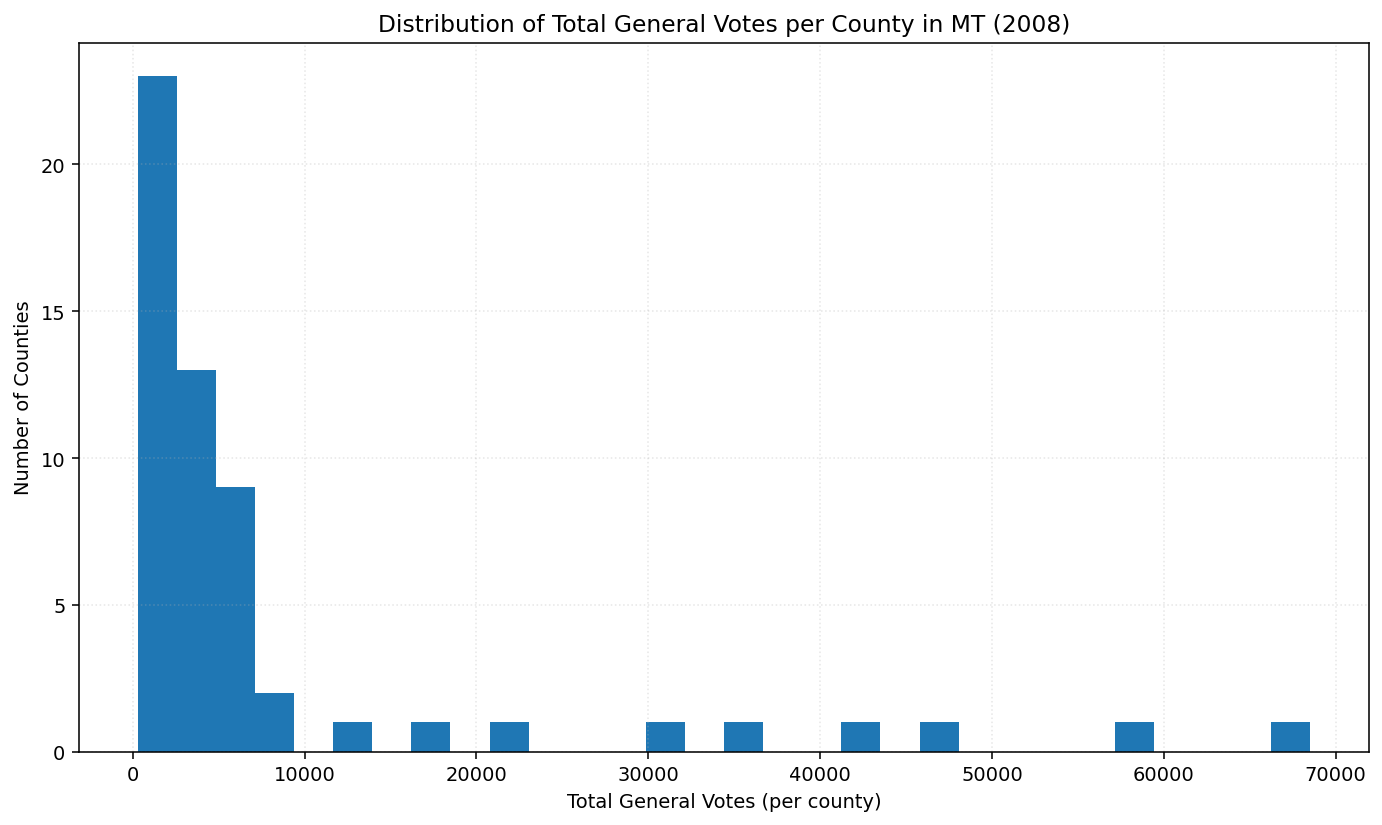

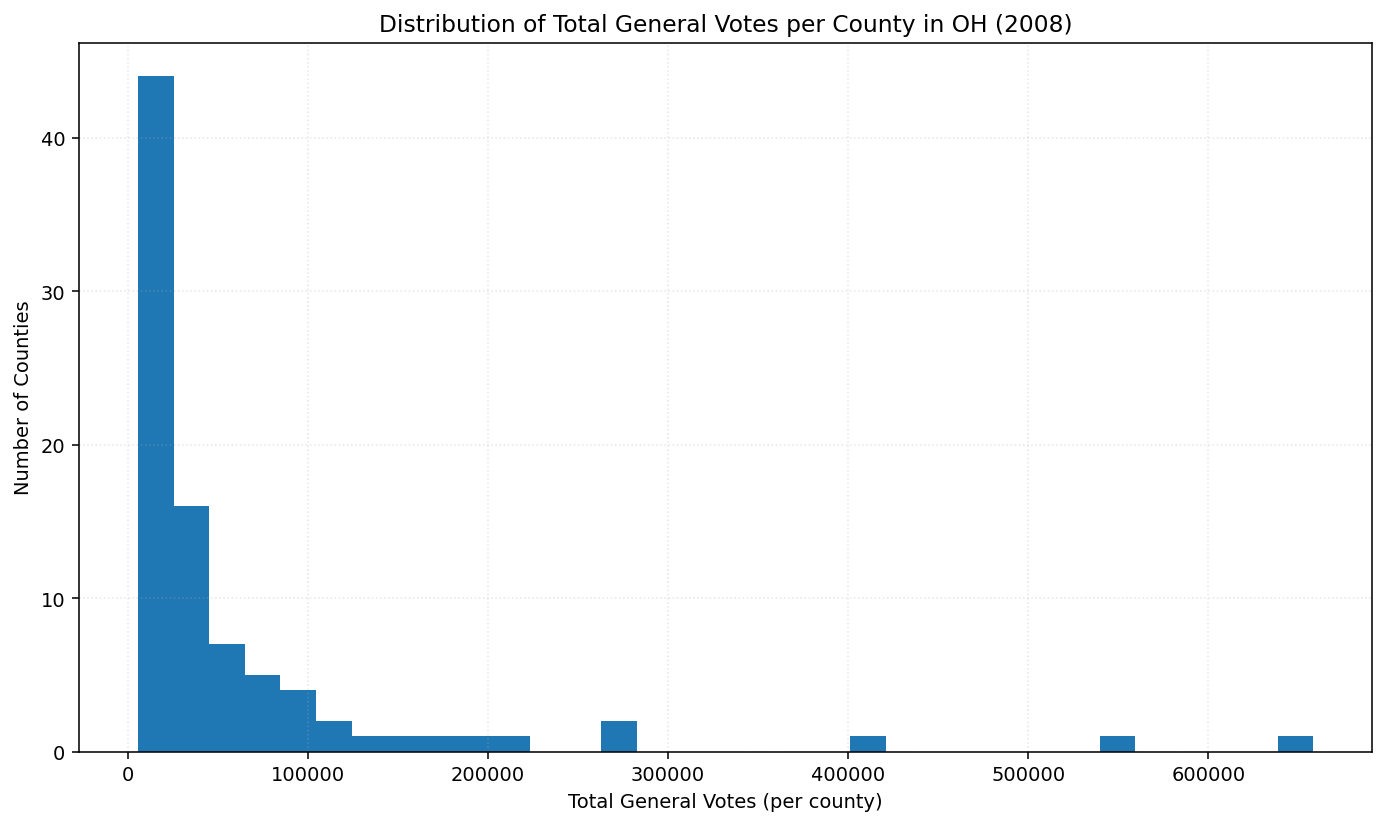

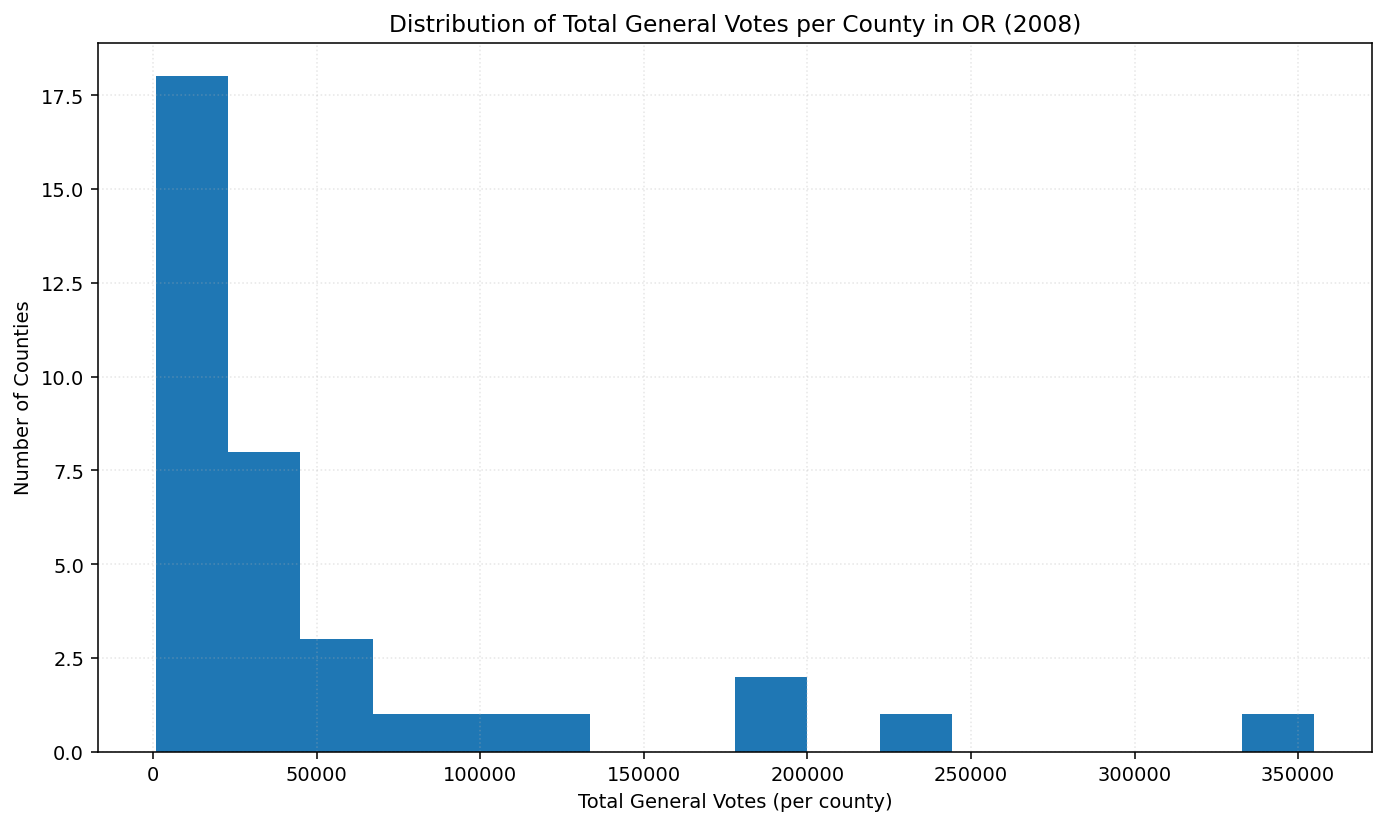

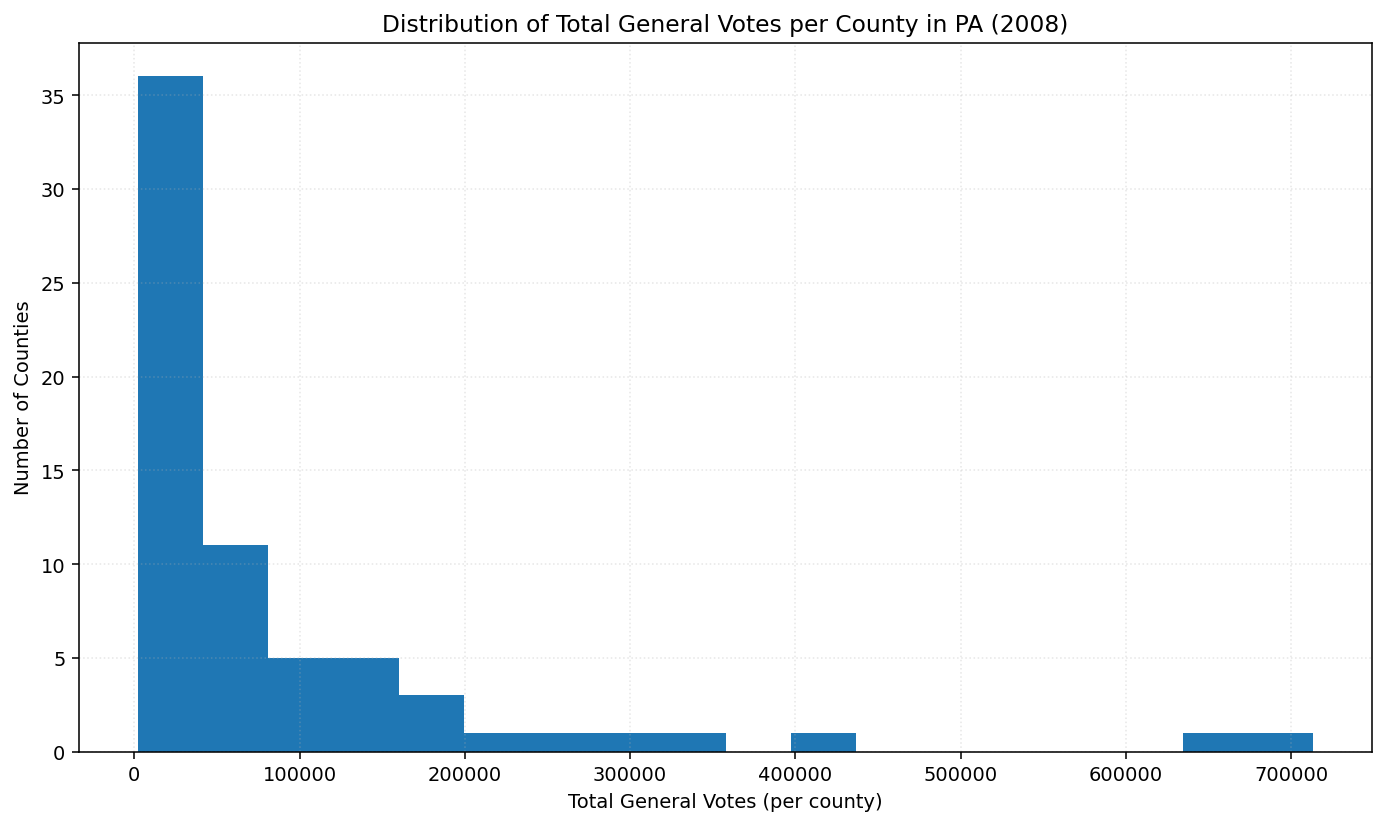

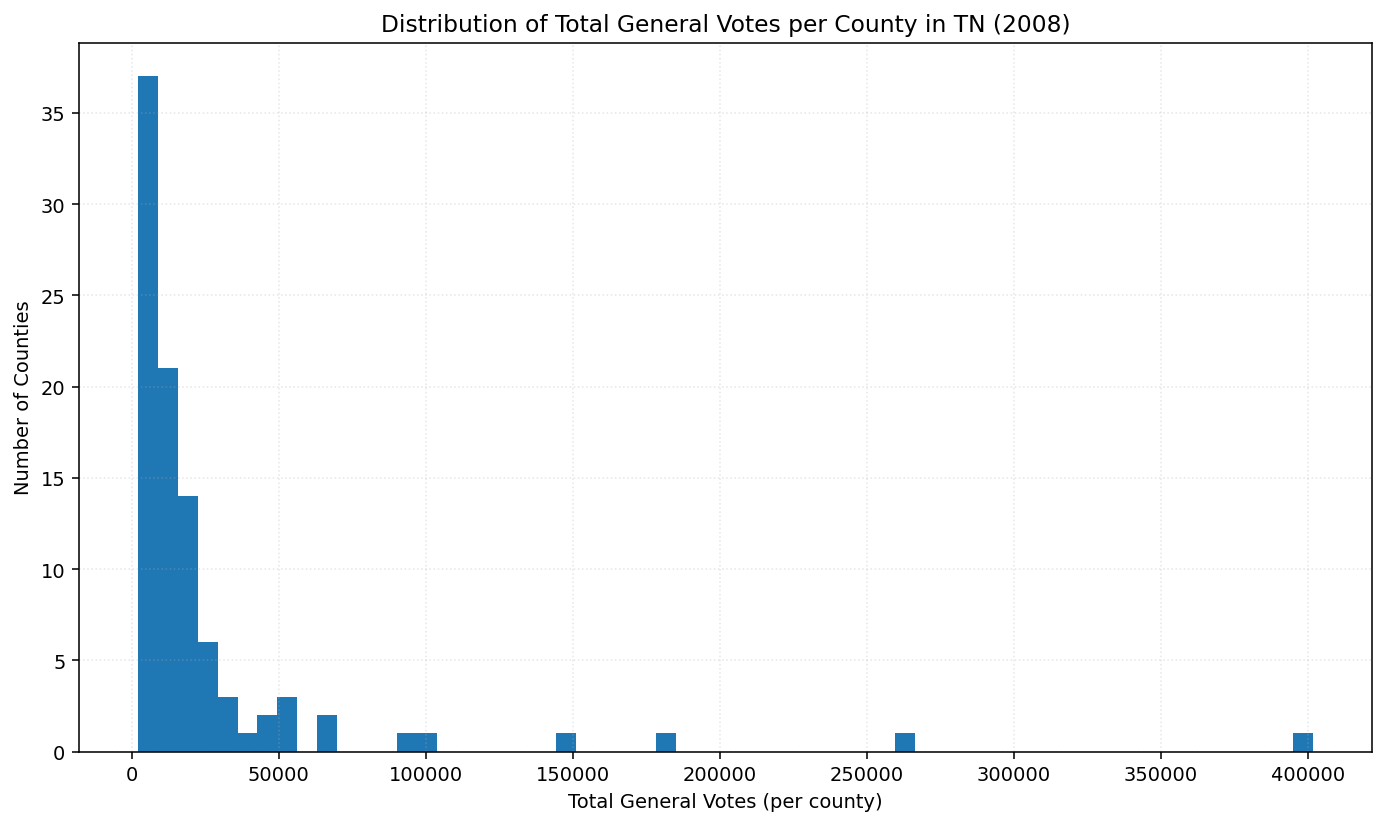

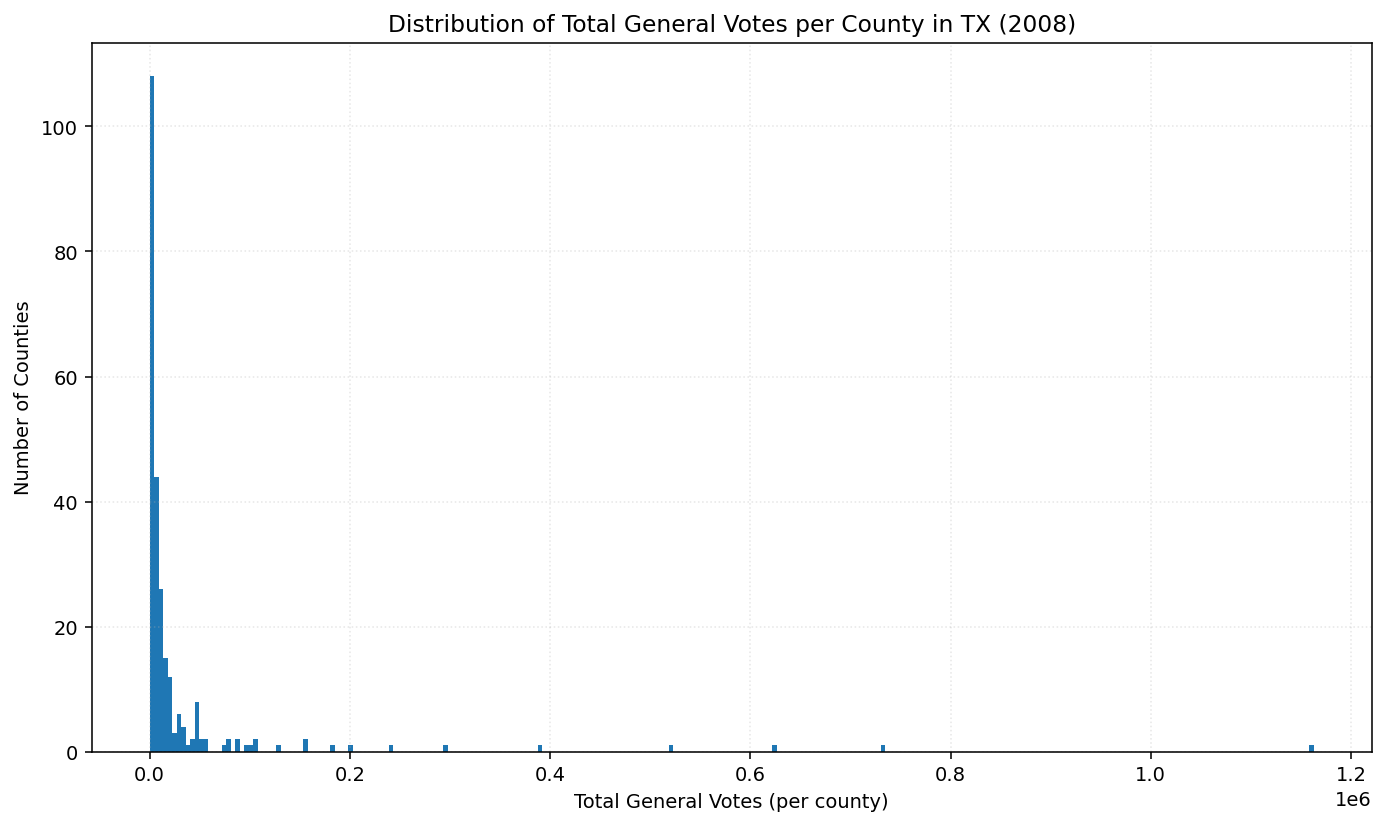

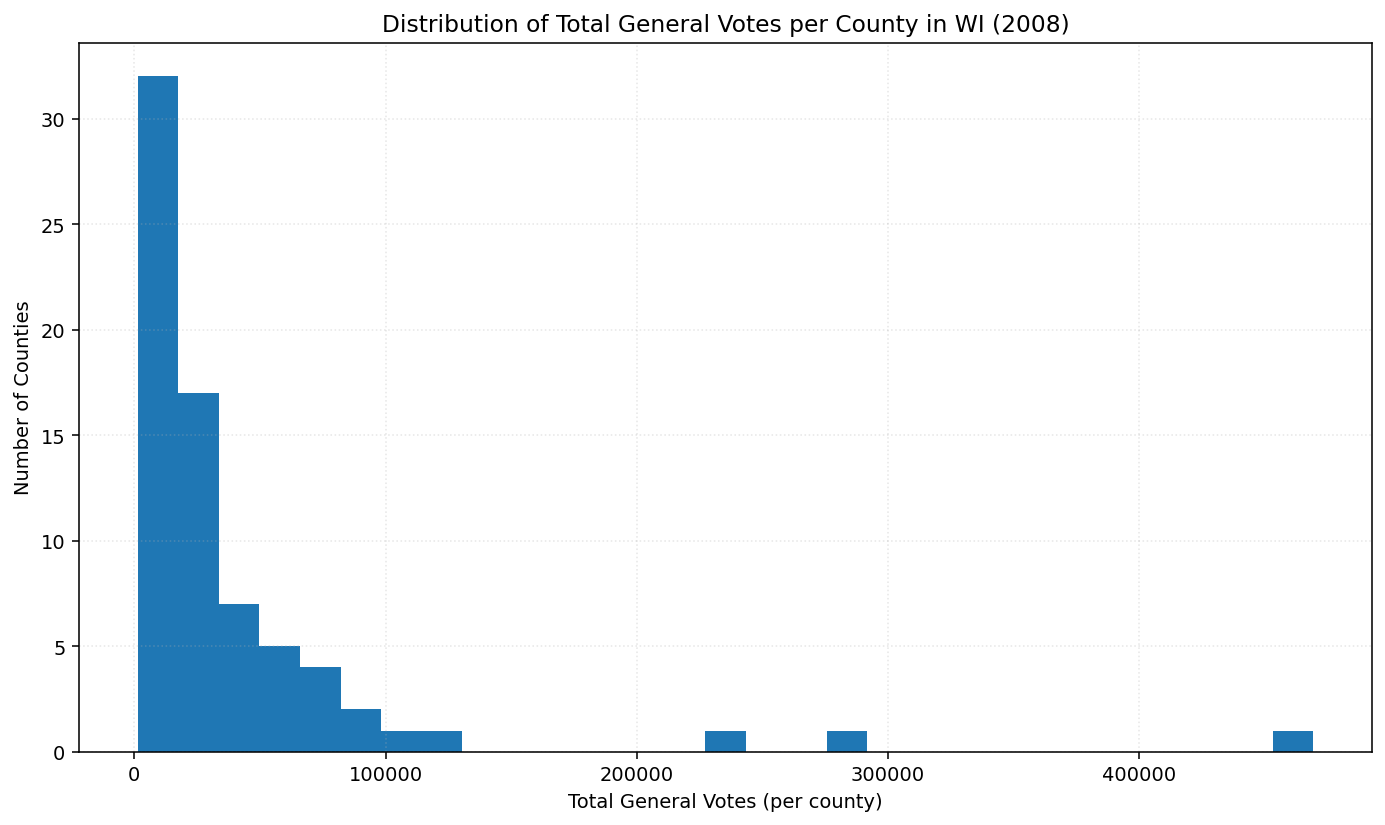

In [22]:
states_2008 = sorted(dt_2008['state'].unique())

for state in states_2008:
    state_df_2008 = dt_2008[dt_2008['state'] == state]
    data = state_df_2008['general_total_votes'].dropna().values
    if data.size == 0:
        continue
    bins = freedman_diaconis_bins(data)
    fig, ax = plt.subplots()
    ax.hist(data, bins=bins)
    ax.set_title(f'Distribution of Total General Votes per County in {state} (2008)')
    ax.set_xlabel('Total General Votes (per county)')
    ax.set_ylabel('Number of Counties')
    ax.grid(True, linestyle=':', alpha=0.3)
    plt.tight_layout()
    plt.show()

The histograms of *general votes per county* in 2008 show that turnout is extremely
uneven across counties. Most counties cluster at relatively low turnout levels,
with a long right tail corresponding to a few very populous counties. This pattern
is typical of U.S. elections and reminds us that our state-level variables are
aggregates over highly heterogeneous local units.

The important takeaway is that there is no obvious pathology: every state exhibits
a sensible distribution of county-level turnout, so it is reasonable to compress
counties into a single state-level observation in the subsequent models.

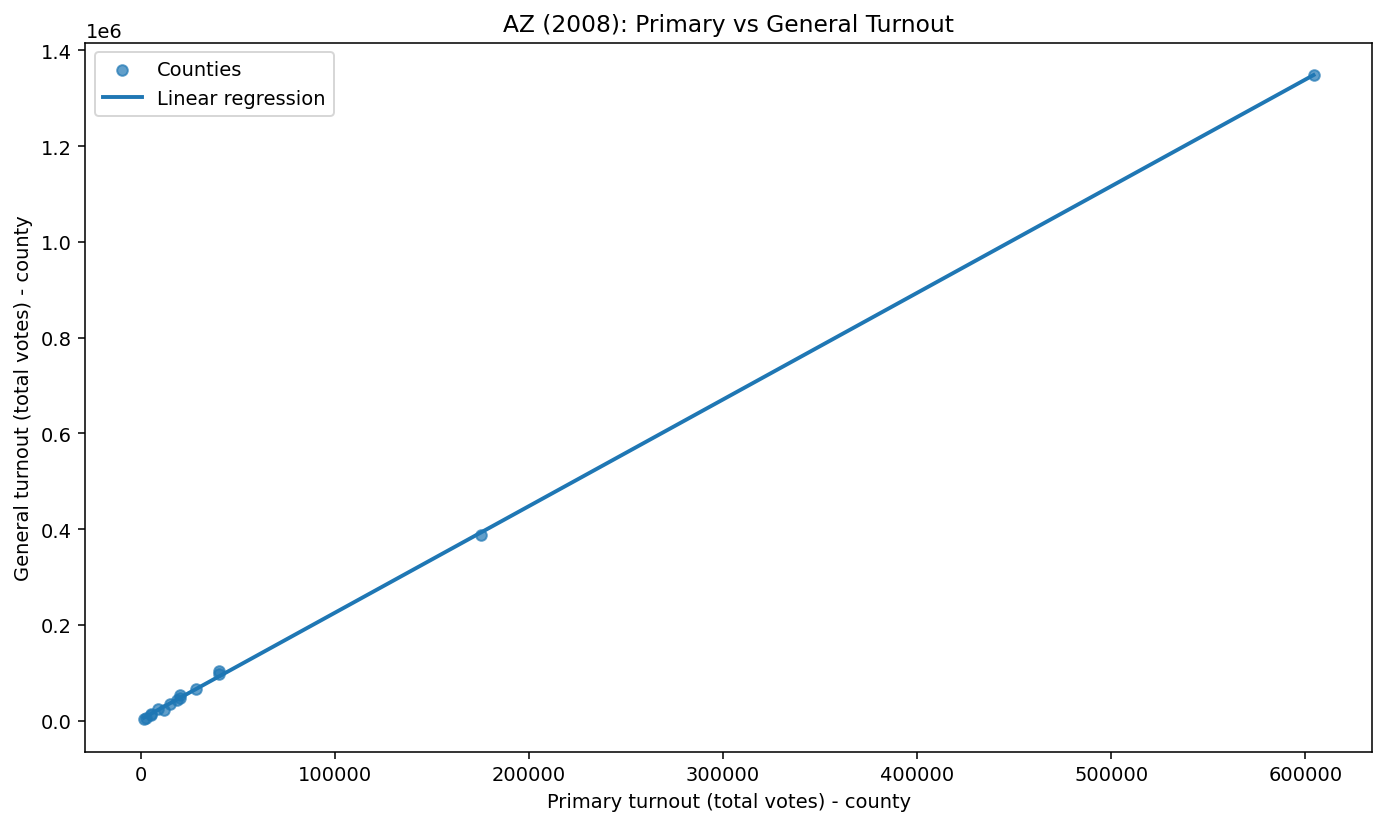

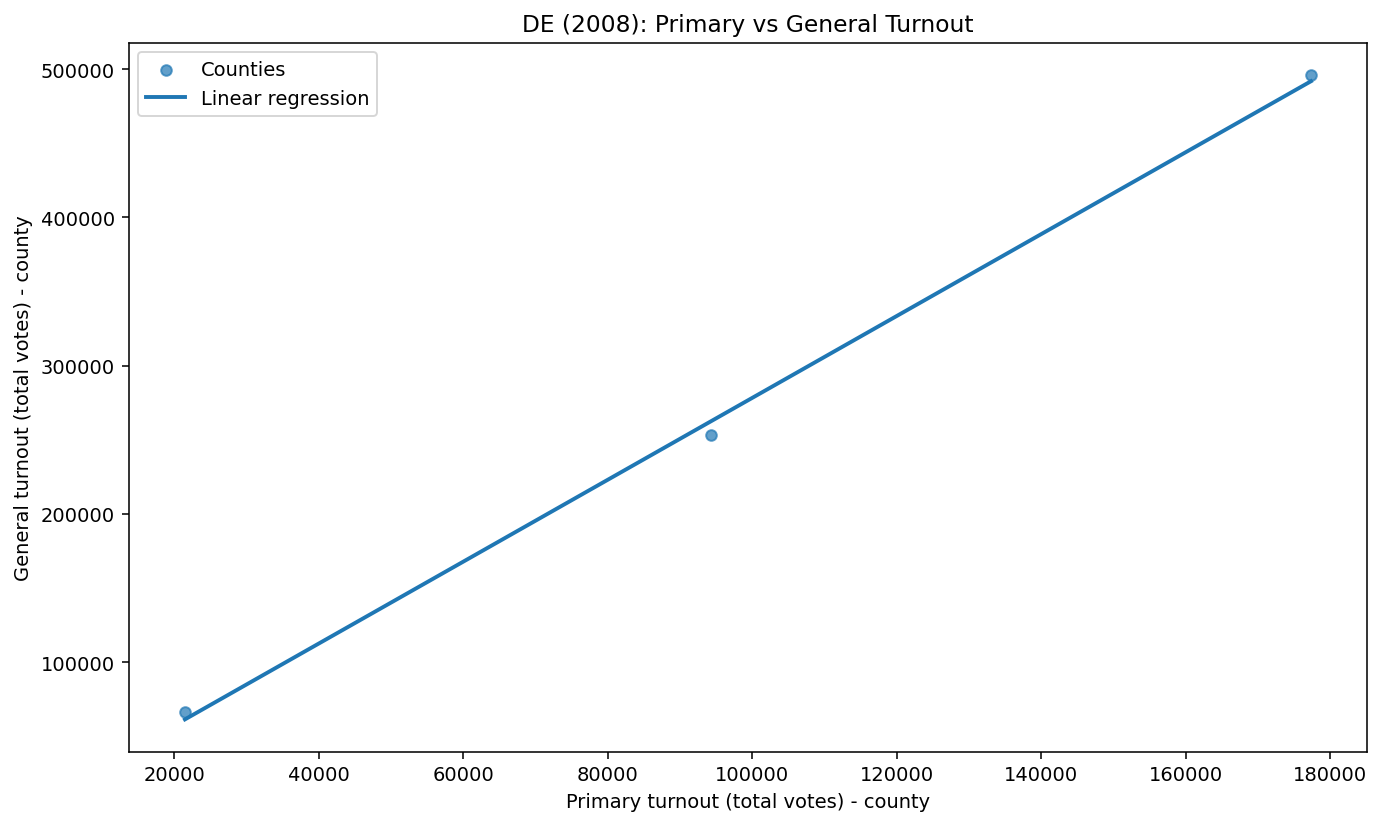

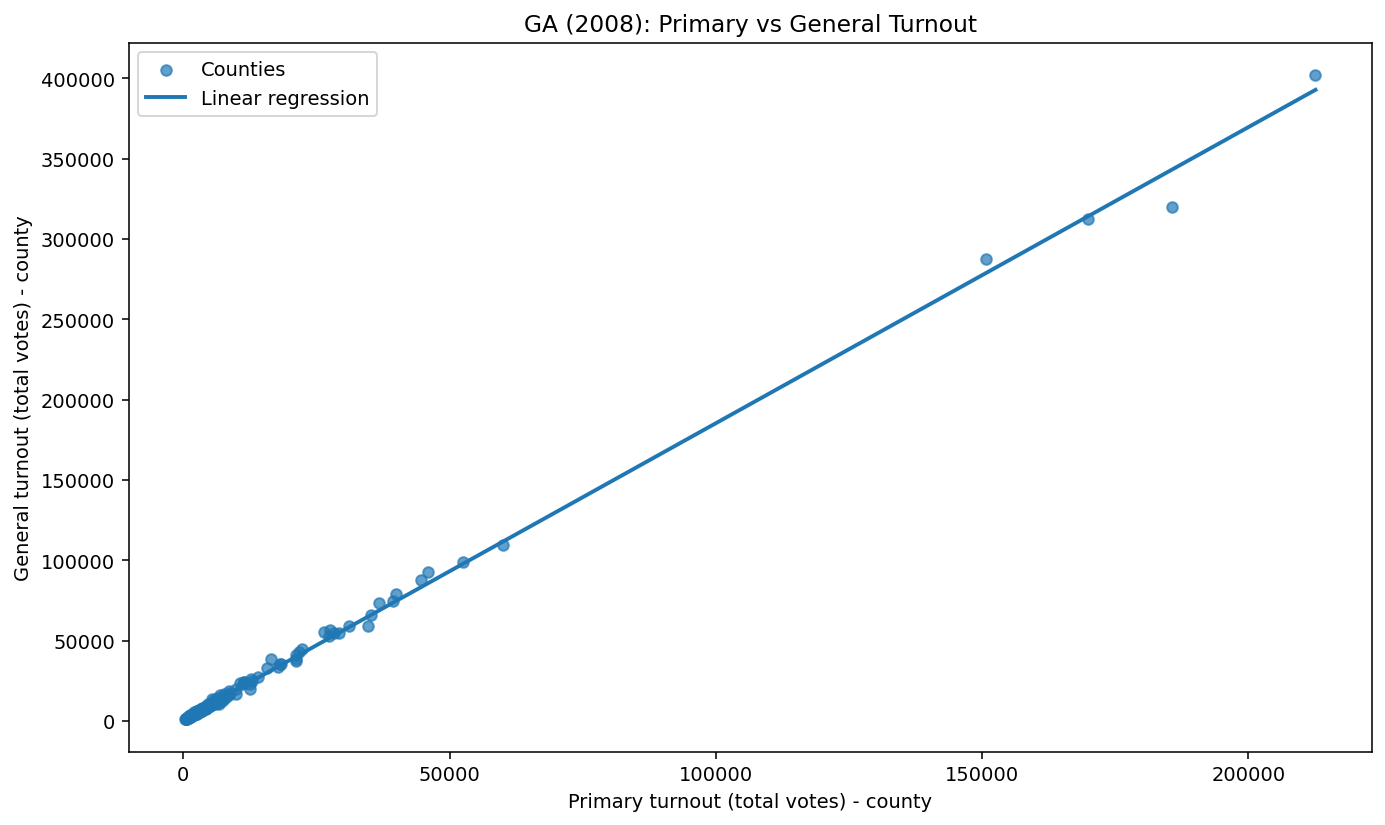

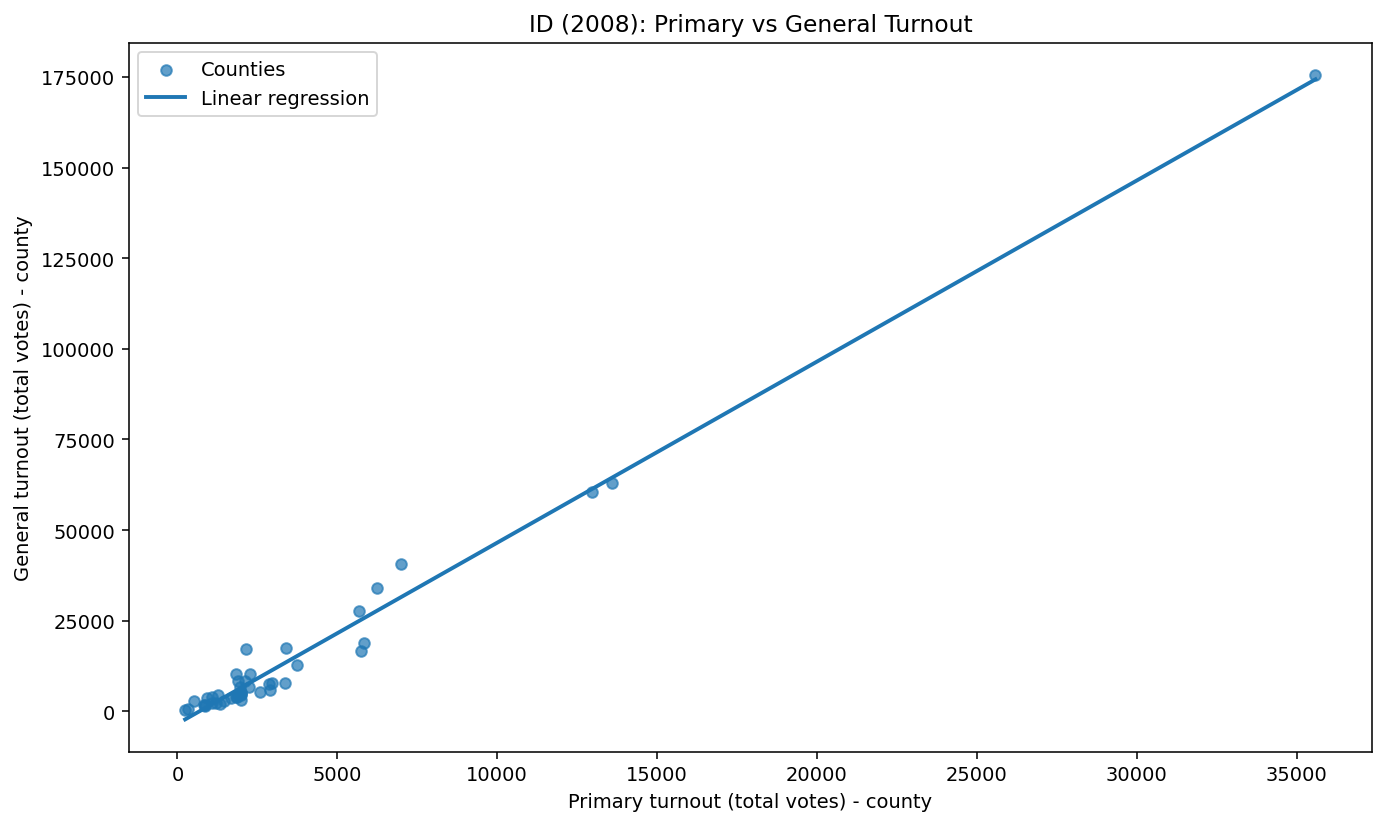

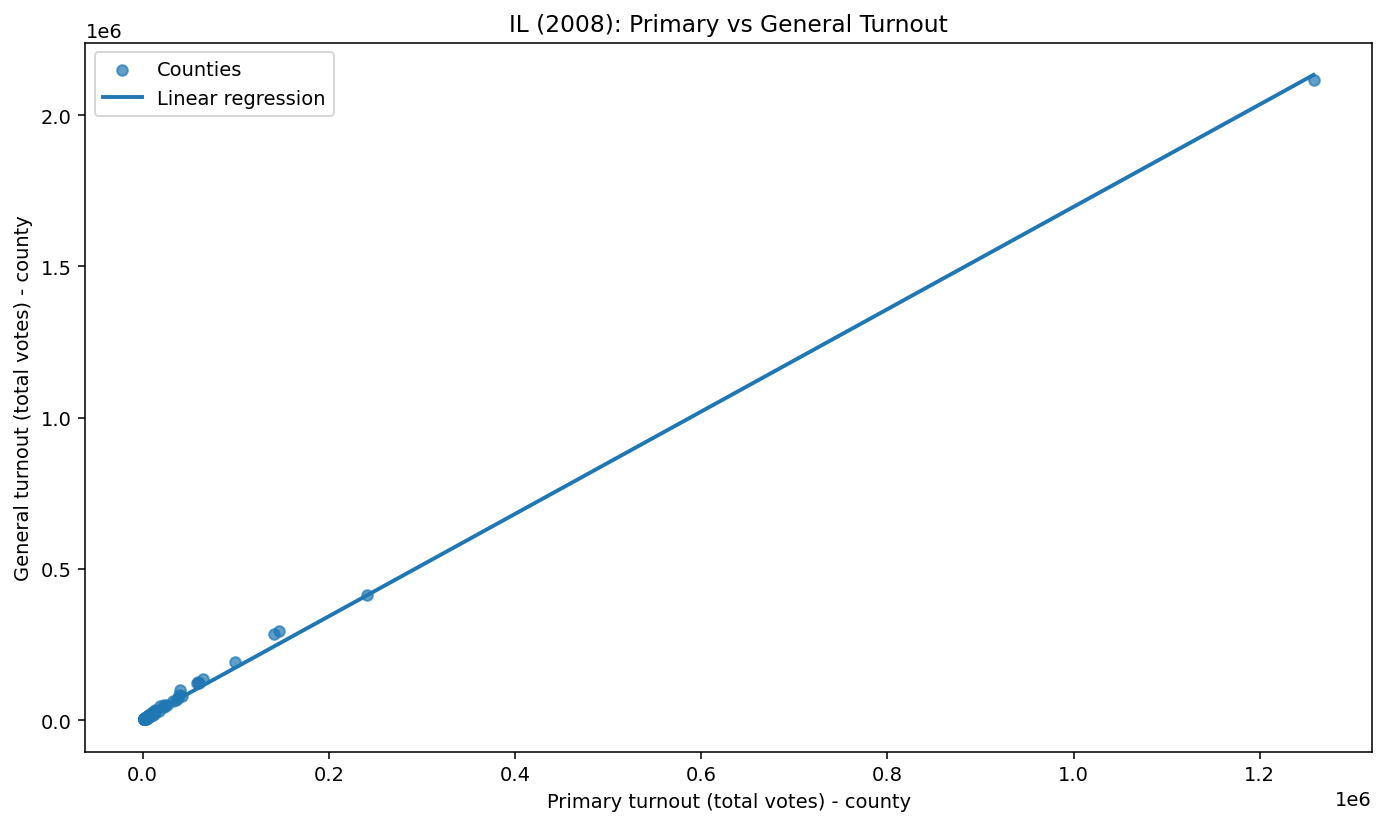

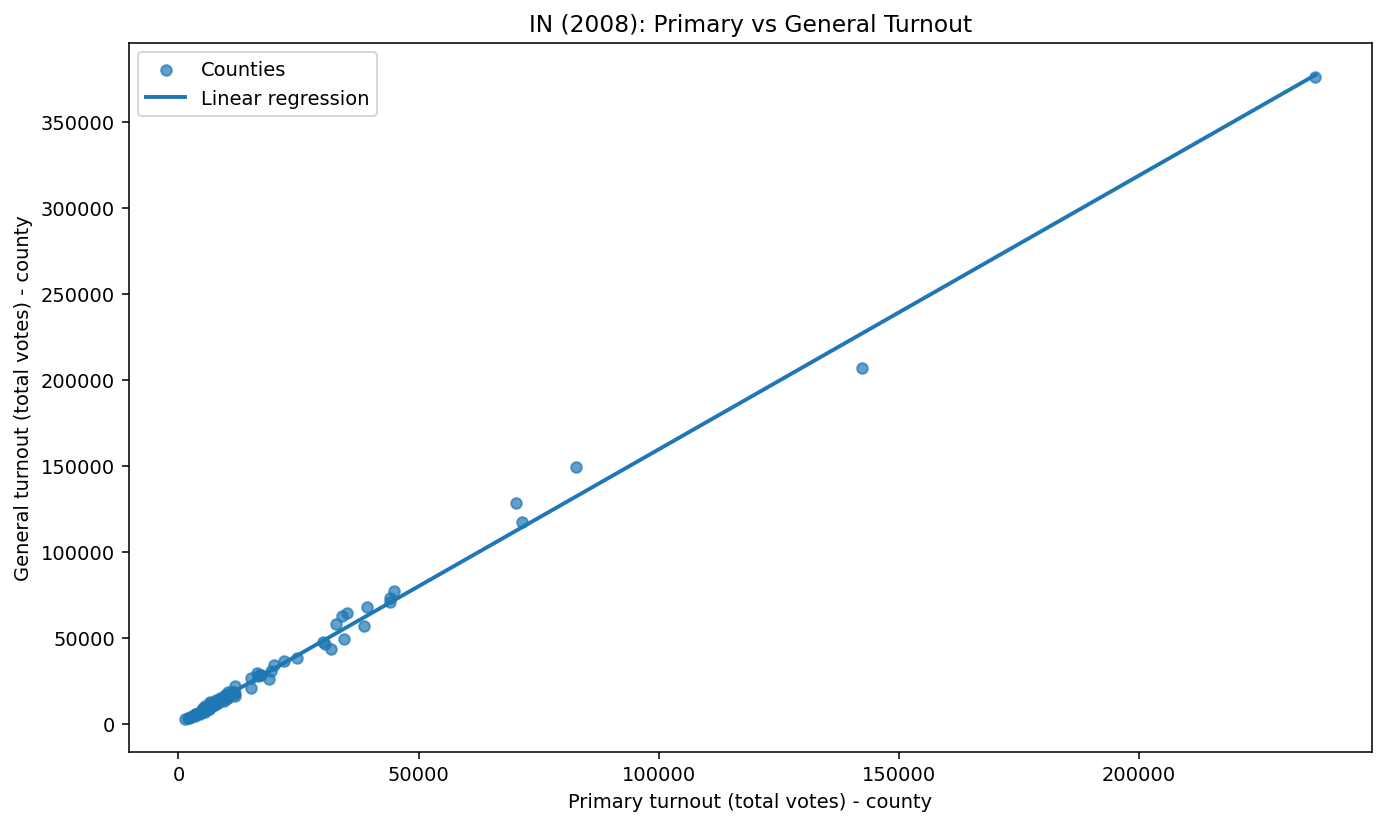

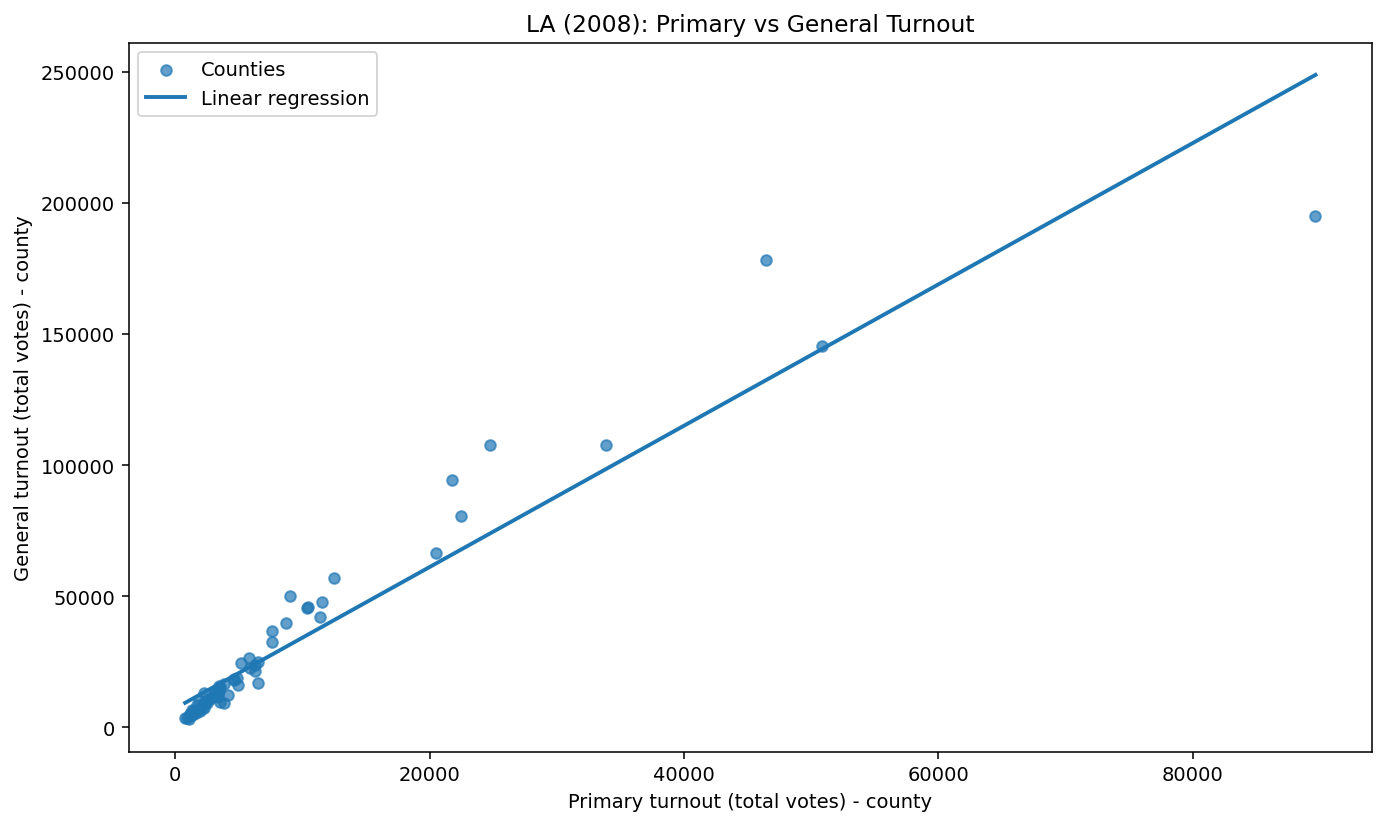

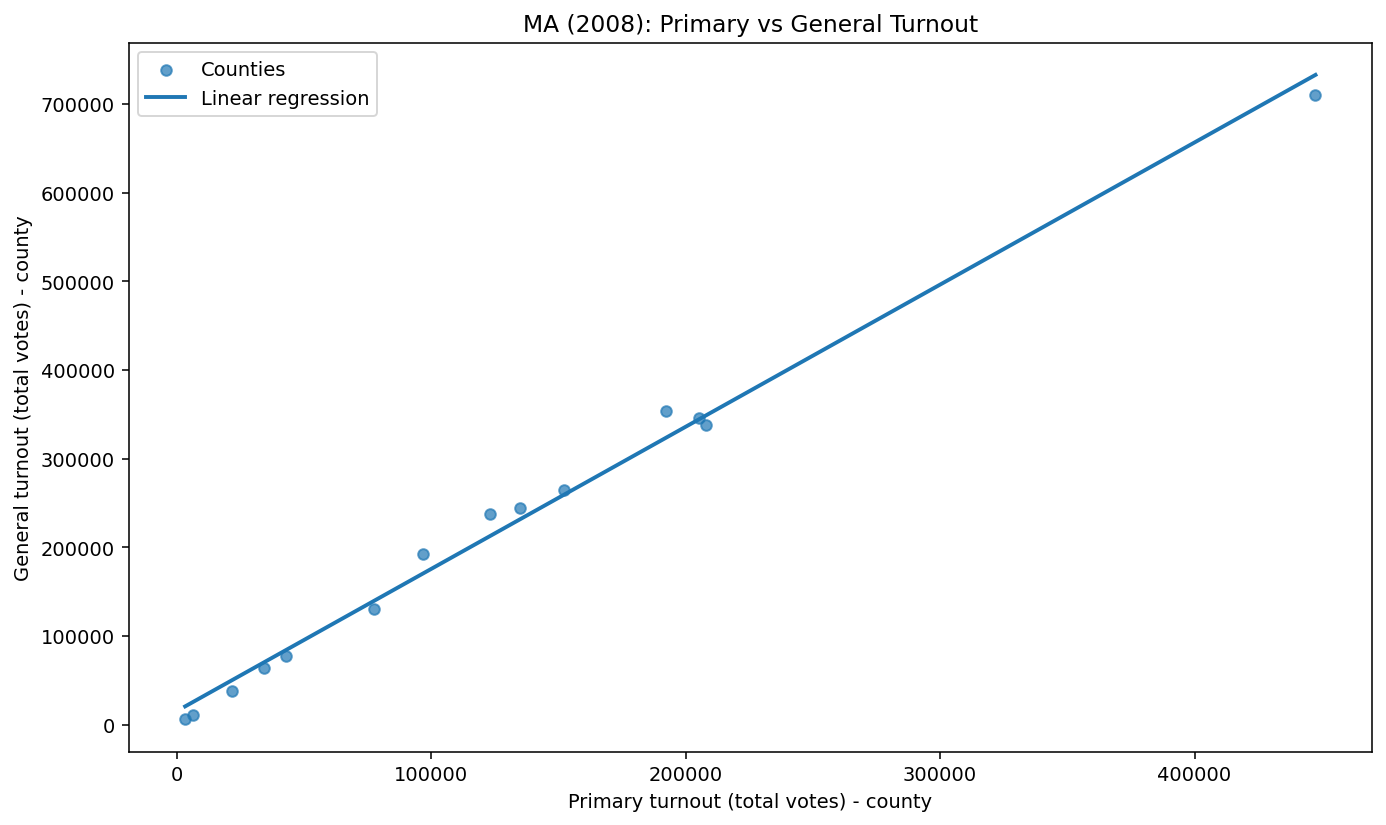

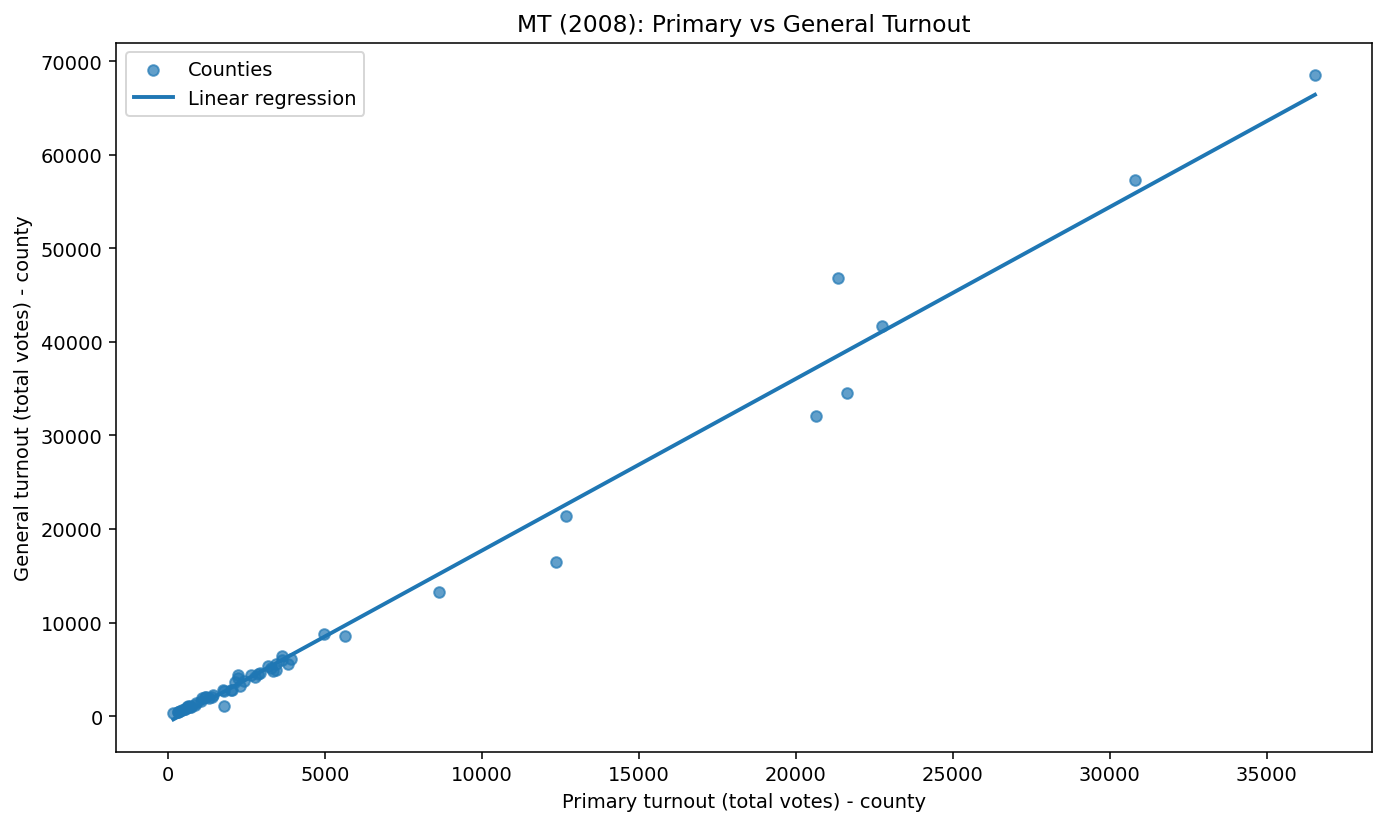

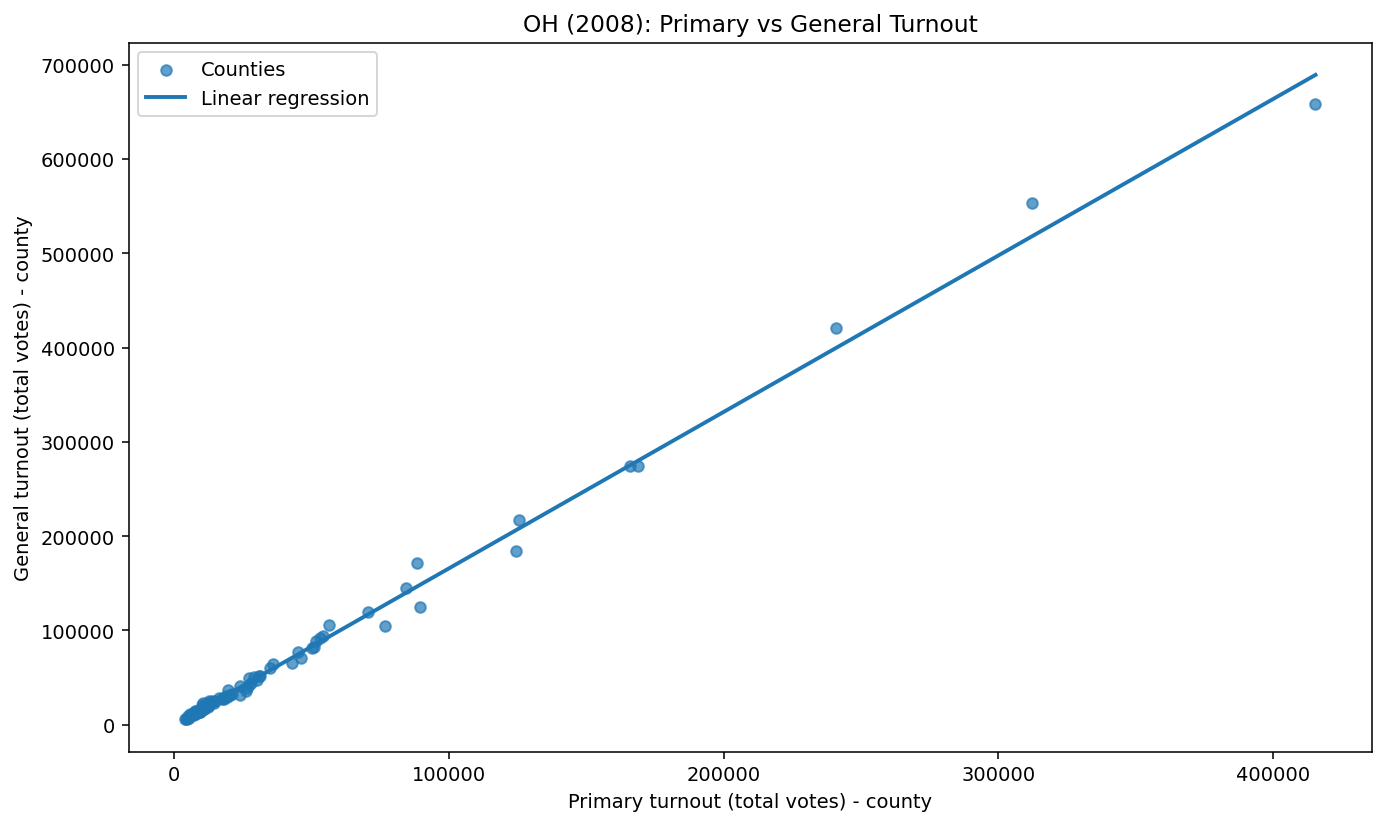

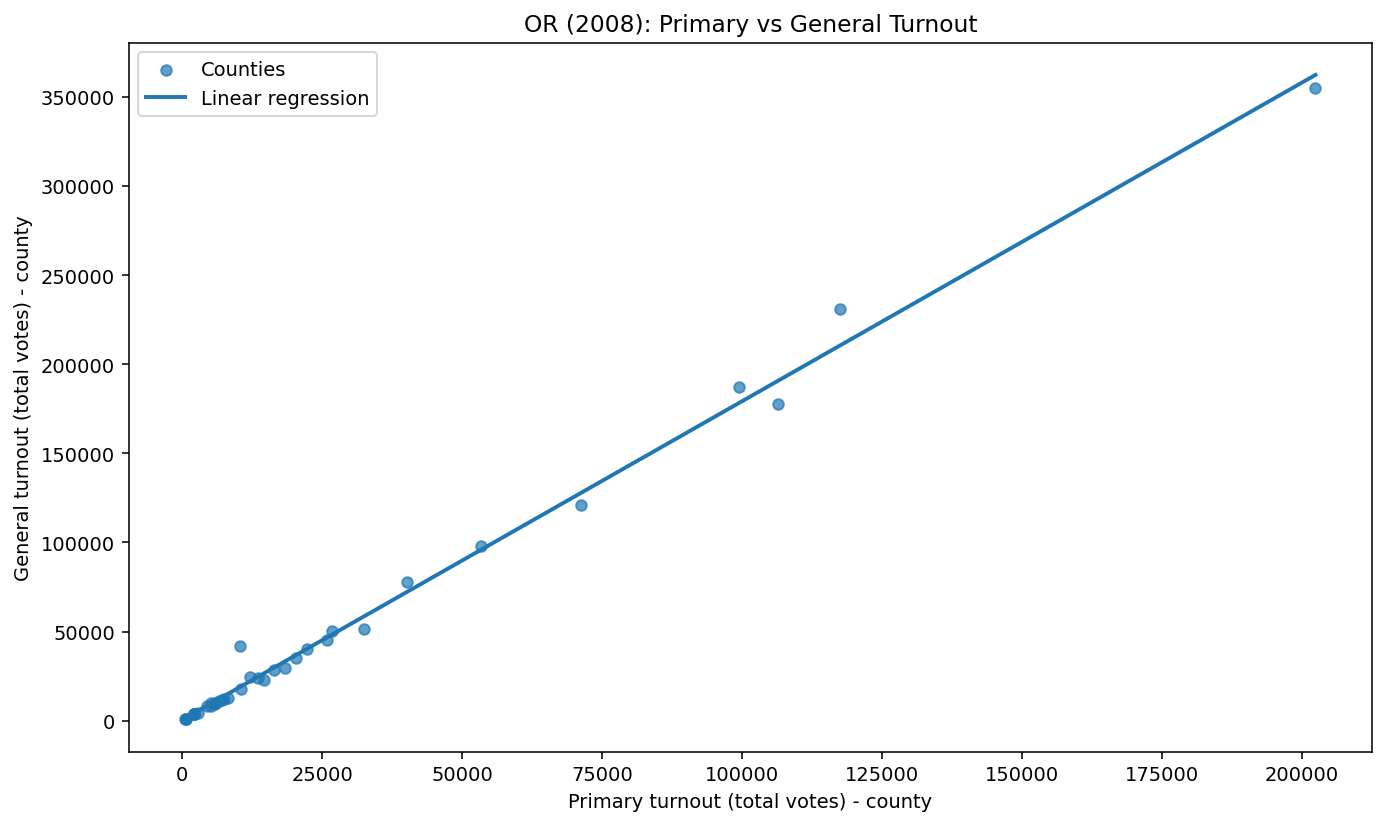

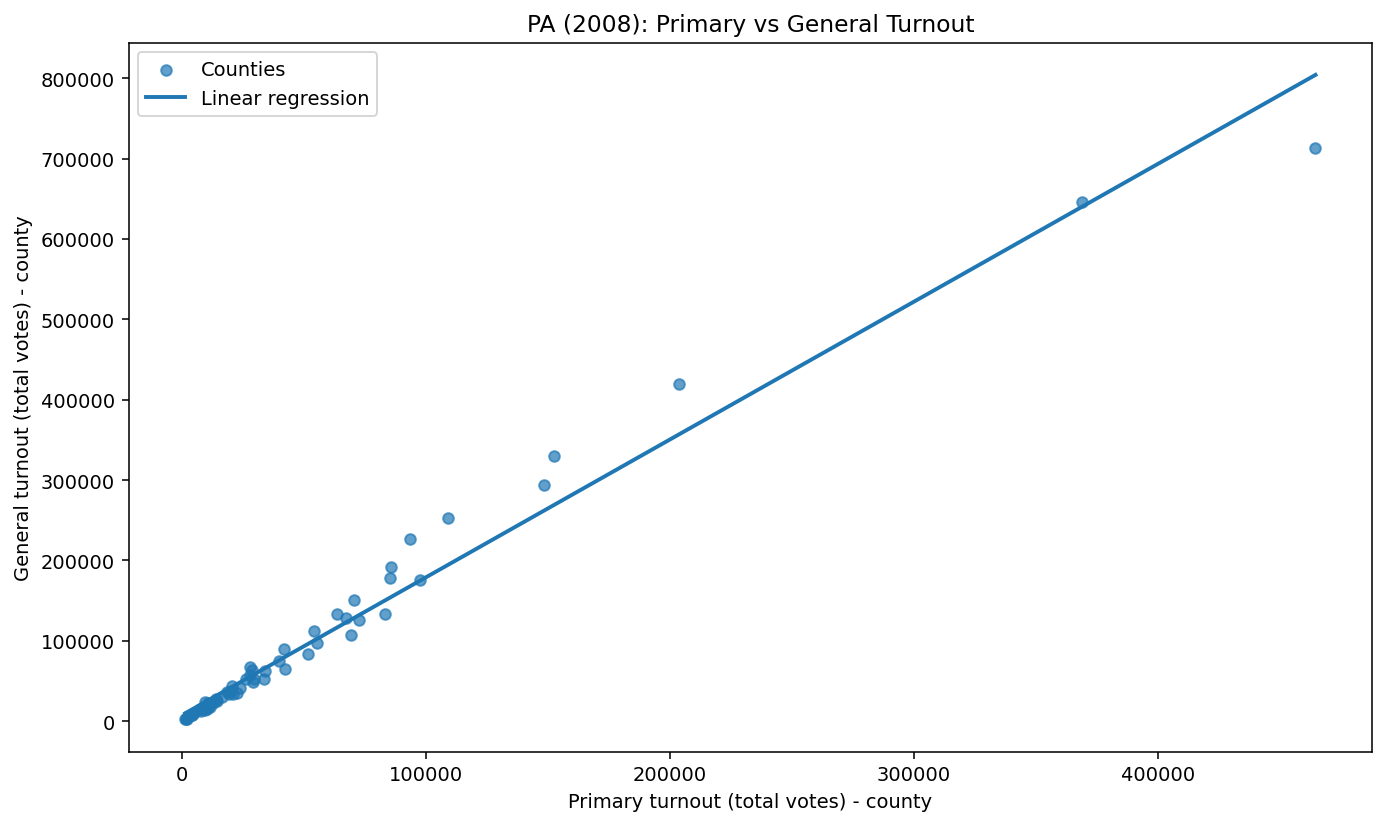

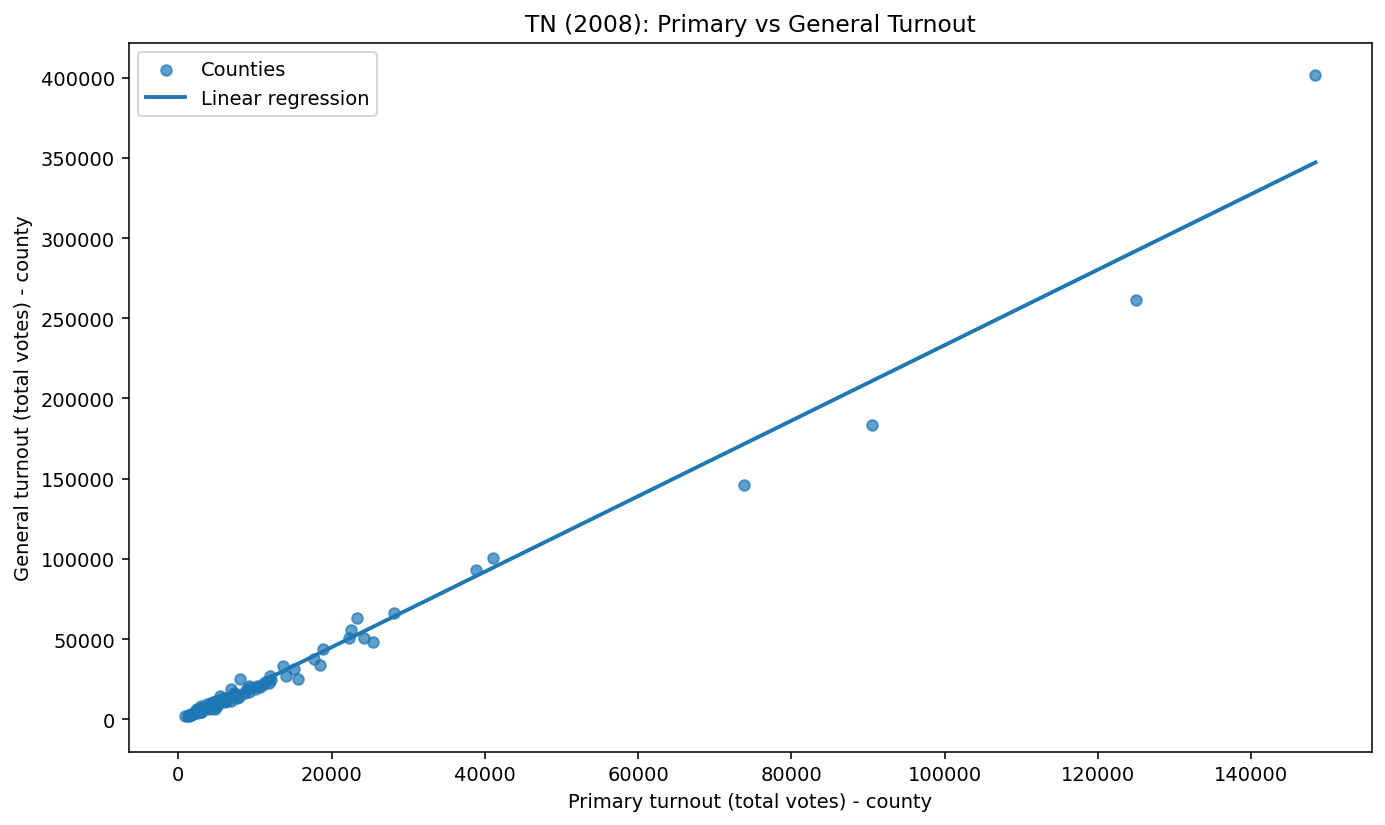

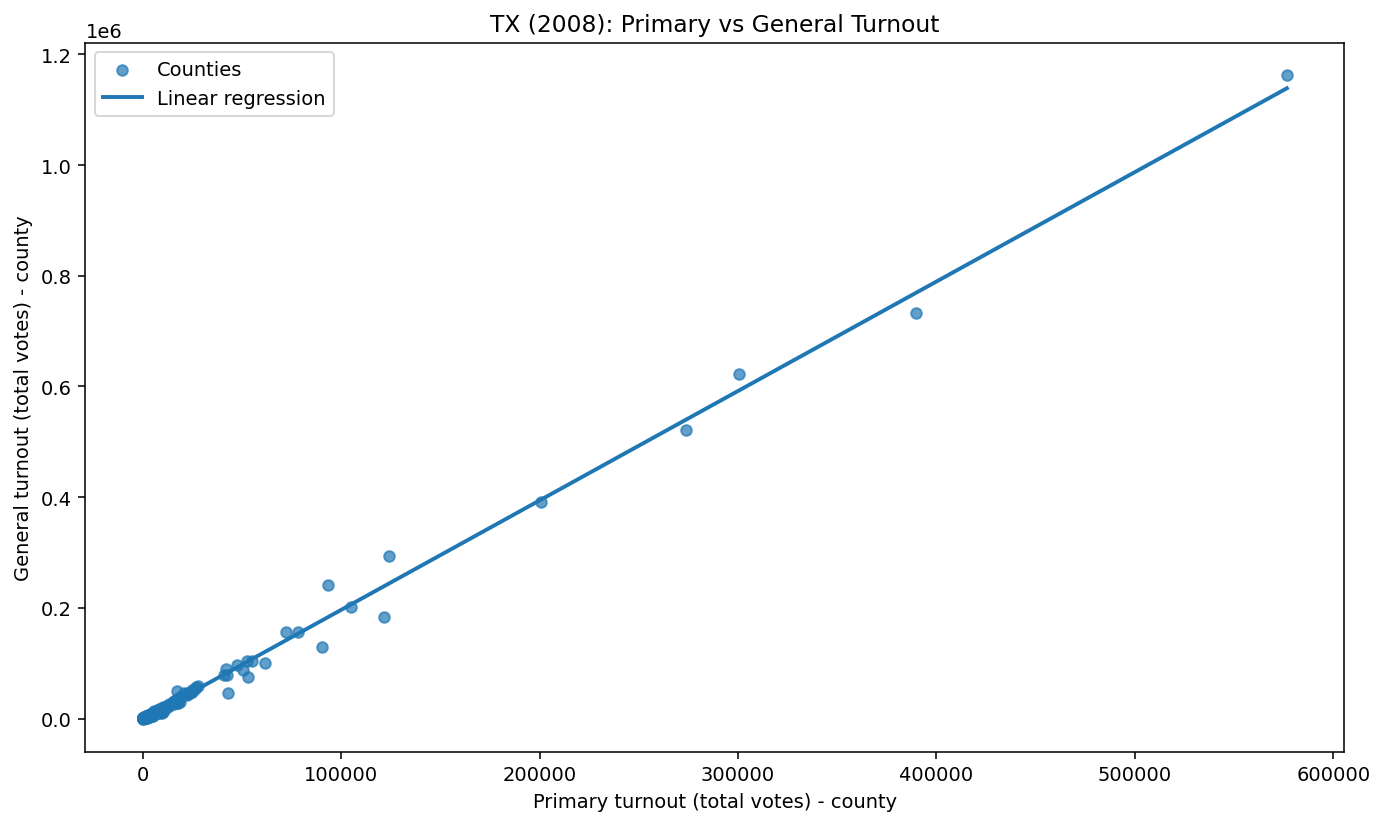

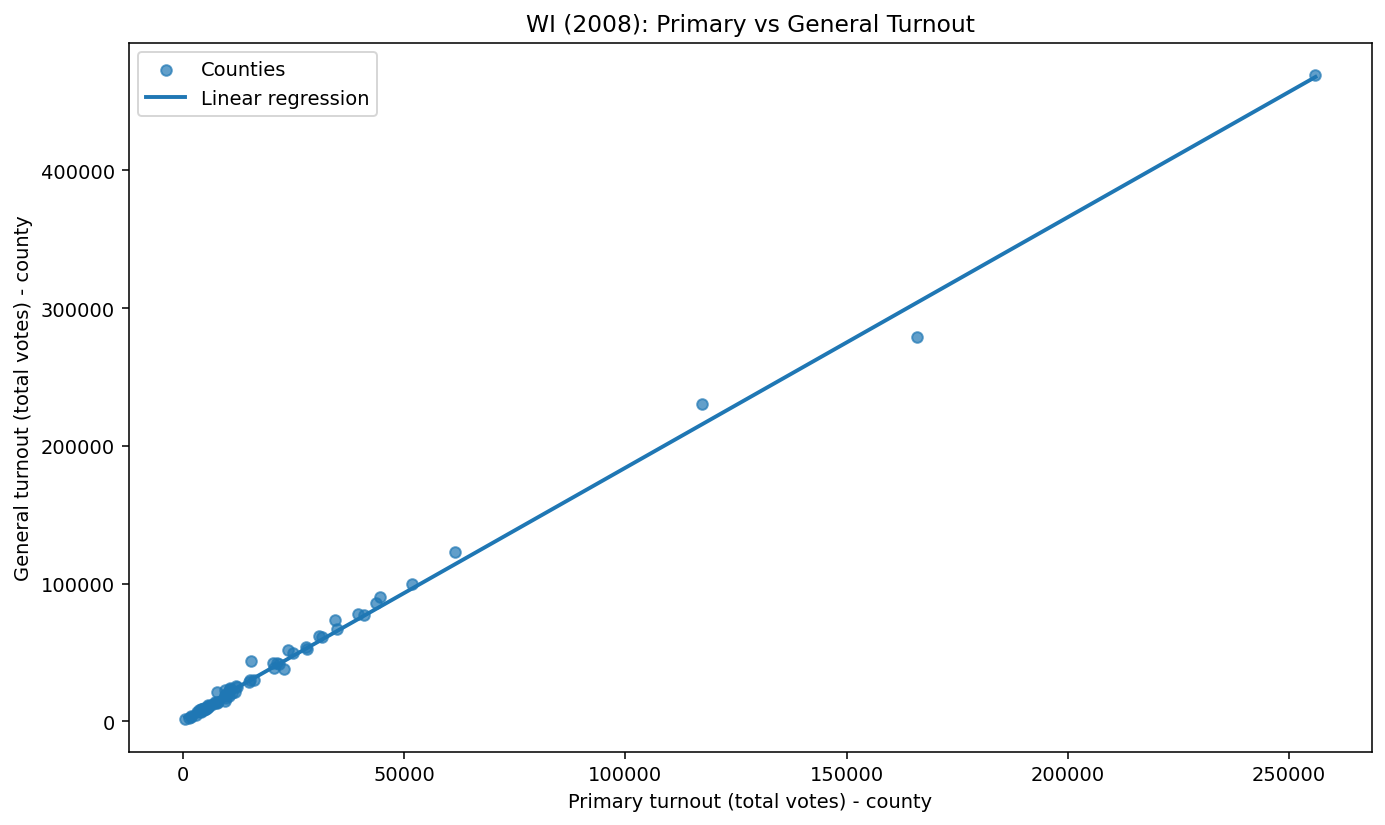

,state,intercept_2008,slope_2008
0,AZ,3060.428585,2.226325
1,DE,1969.151565,2.762210
2,GA,1018.361396,1.843004
3,ID,-3411.158958,4.994547
4,IL,4696.547537,1.692110
5,IN,290.832515,1.592471
6,LA,7215.276290,2.693760
7,MA,15536.038268,1.602285
8,MT,-641.354065,1.834780
9,OH,-301.655742,1.659952


In [23]:
beta_0_2008 = {}
beta_1_2008 = {}

for state in states_2008:
    state_df_2008 = dt_2008[dt_2008['state'] == state].copy()
    X = state_df_2008['primary_total_votes'].values.reshape(-1, 1)
    y = state_df_2008['general_total_votes'].values
    if X.shape[0] < 2:
        continue
    reg = LinearRegression()
    reg.fit(X, y)
    beta_0_2008[state] = reg.intercept_
    beta_1_2008[state] = reg.coef_[0]

    sort_idx = np.argsort(X[:, 0])
    X_sorted = X[sort_idx]
    y_pred = reg.predict(X_sorted)

    plt.figure()
    plt.scatter(
        state_df_2008['primary_total_votes'],
        state_df_2008['general_total_votes'],
        alpha=0.7,
        s=30,
        label='Counties'
    )
    plt.plot(X_sorted, y_pred, linewidth=2, label='Linear regression')
    plt.xlabel('Primary turnout (total votes) - county')
    plt.ylabel('General turnout (total votes) - county')
    plt.title(f'{state} (2008): Primary vs General Turnout')
    plt.legend()
    plt.tight_layout()
    plt.show()

coef_2008 = pd.DataFrame({
    'state': list(beta_0_2008.keys()),
    'intercept_2008': list(beta_0_2008.values()),
    'slope_2008': list(beta_1_2008.values()),
}).sort_values('state')
coef_2008

The regression plots of primary vs general turnout by county show a tight linear
relationship within each state: counties that turn out more in the primary also
tend to turn out more in the general. The fitted slopes in `coef_2008` are all
comfortably above 1, meaning that general election turnout is consistently higher
than primary turnout, but the *ranking* of counties is quite stable.

This supports our modeling choice later on: primary turnout is not a weird,
unrelated process. Instead, it is strongly tied to general turnout, so using primary
results as proxies for the size of each side’s supporter base is defensible.

### 2.2. 2016 Presidential Election

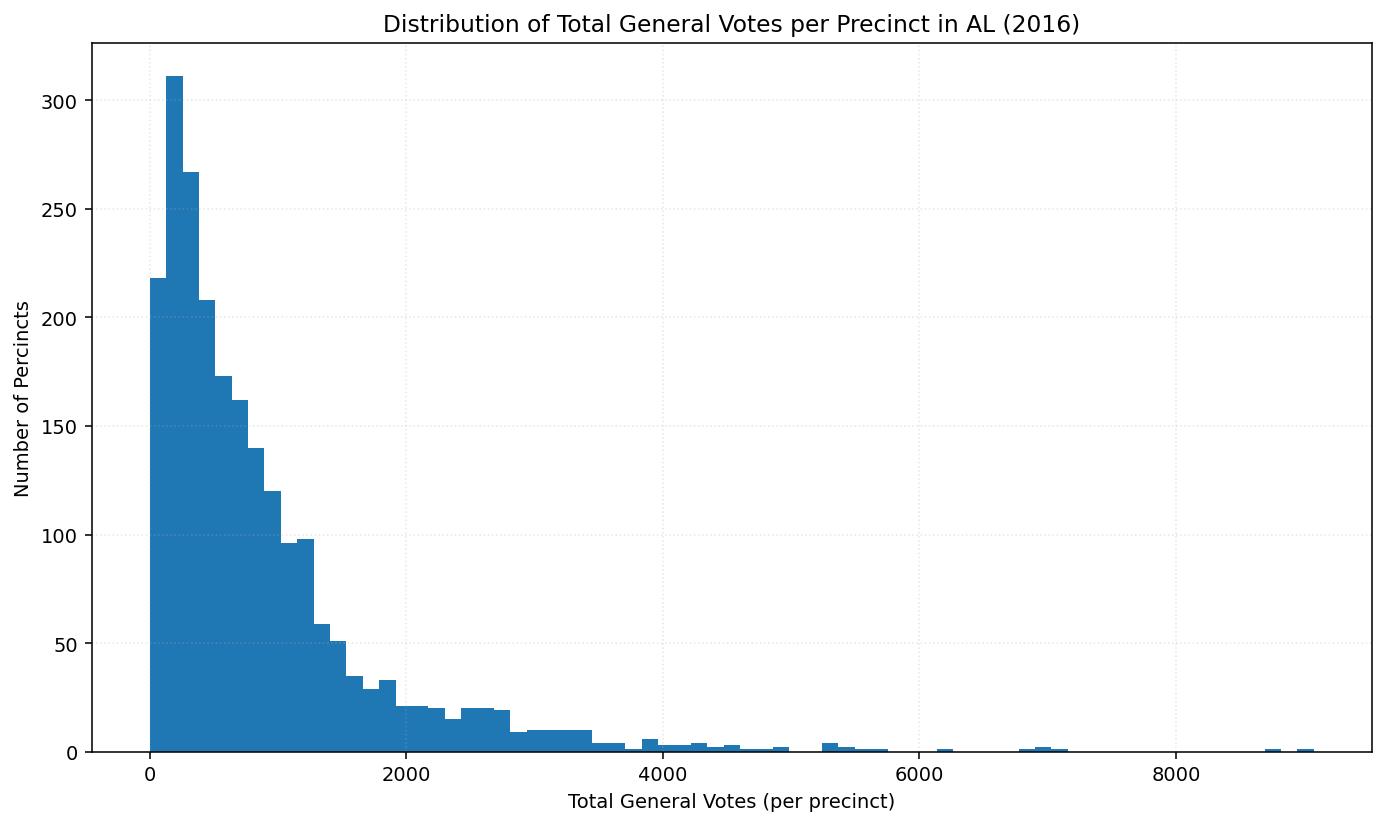

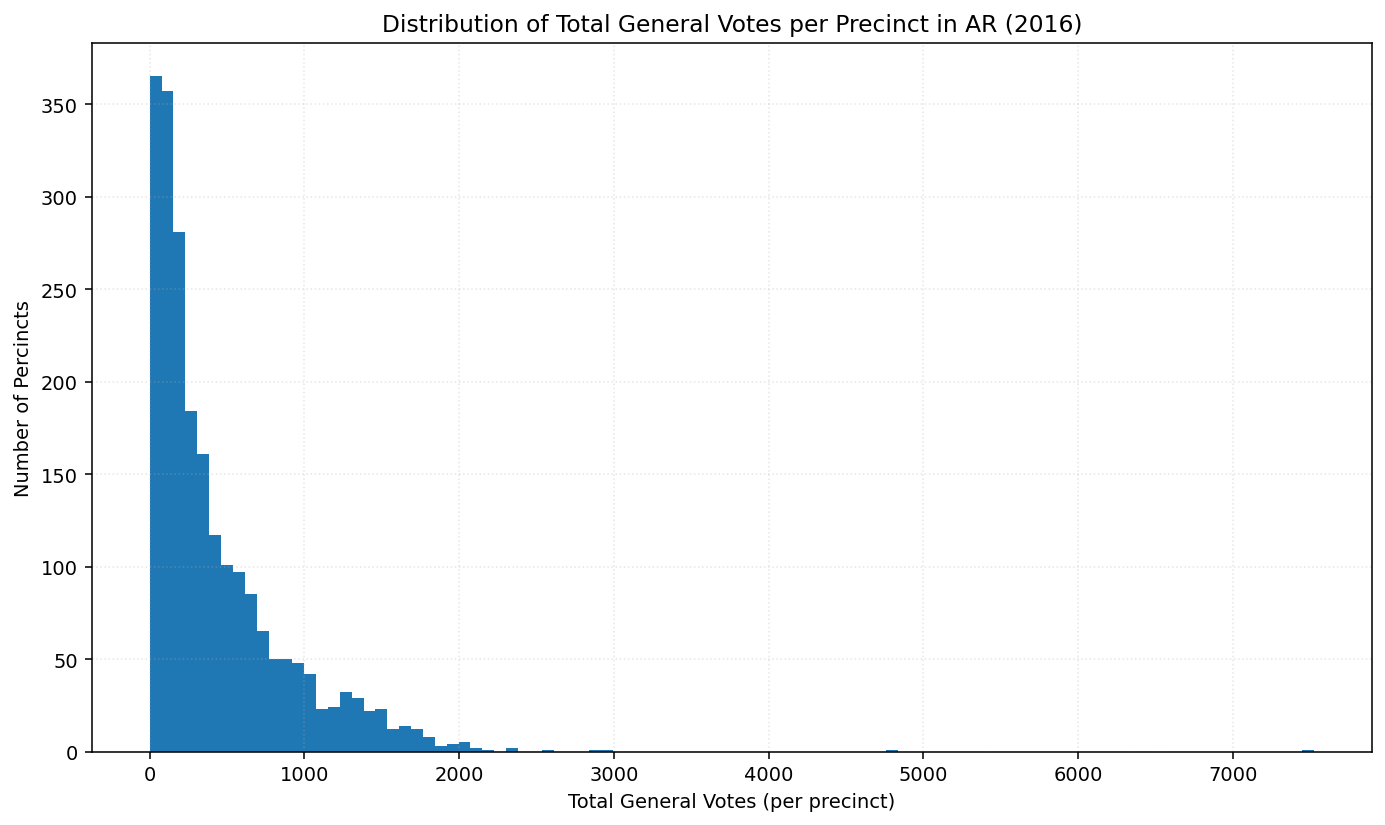

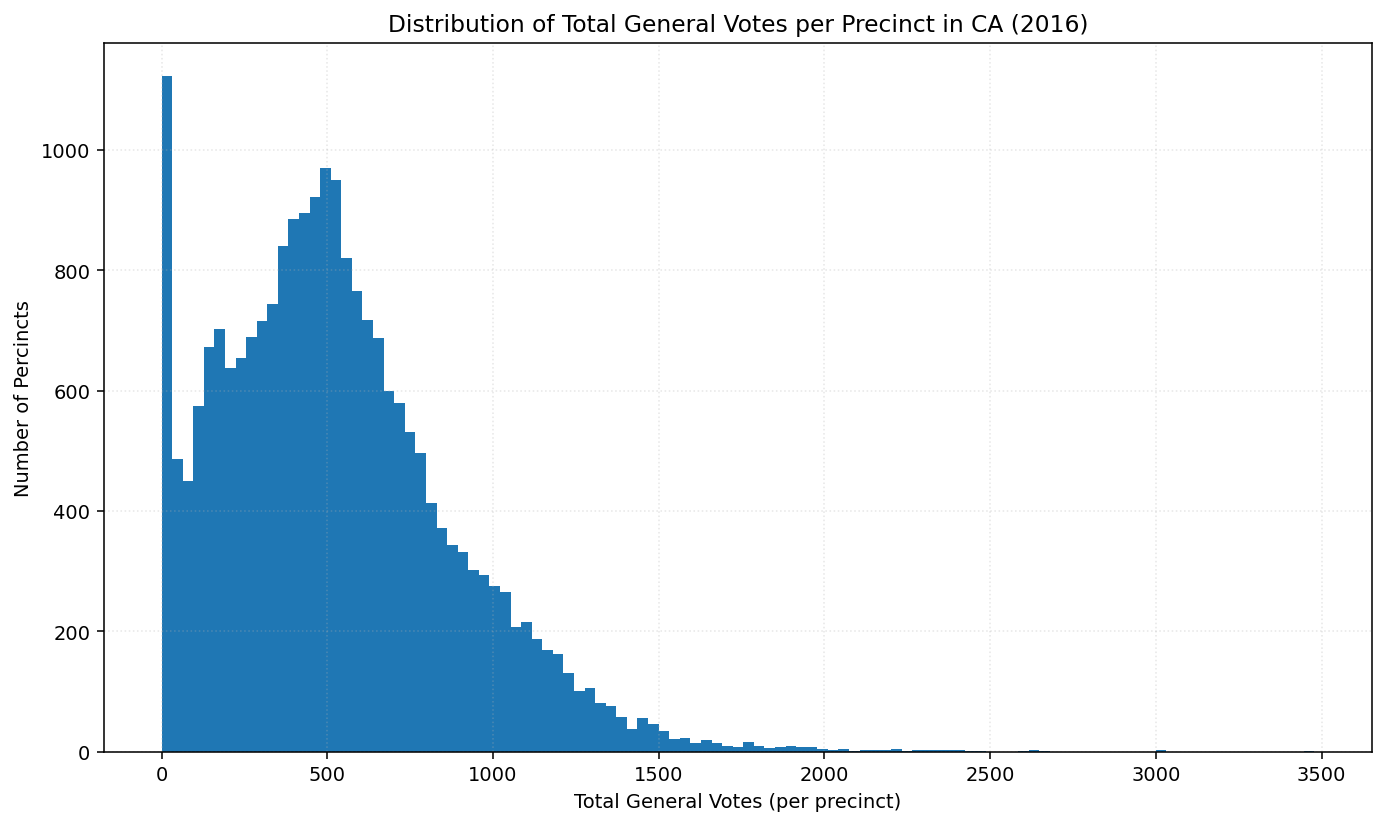

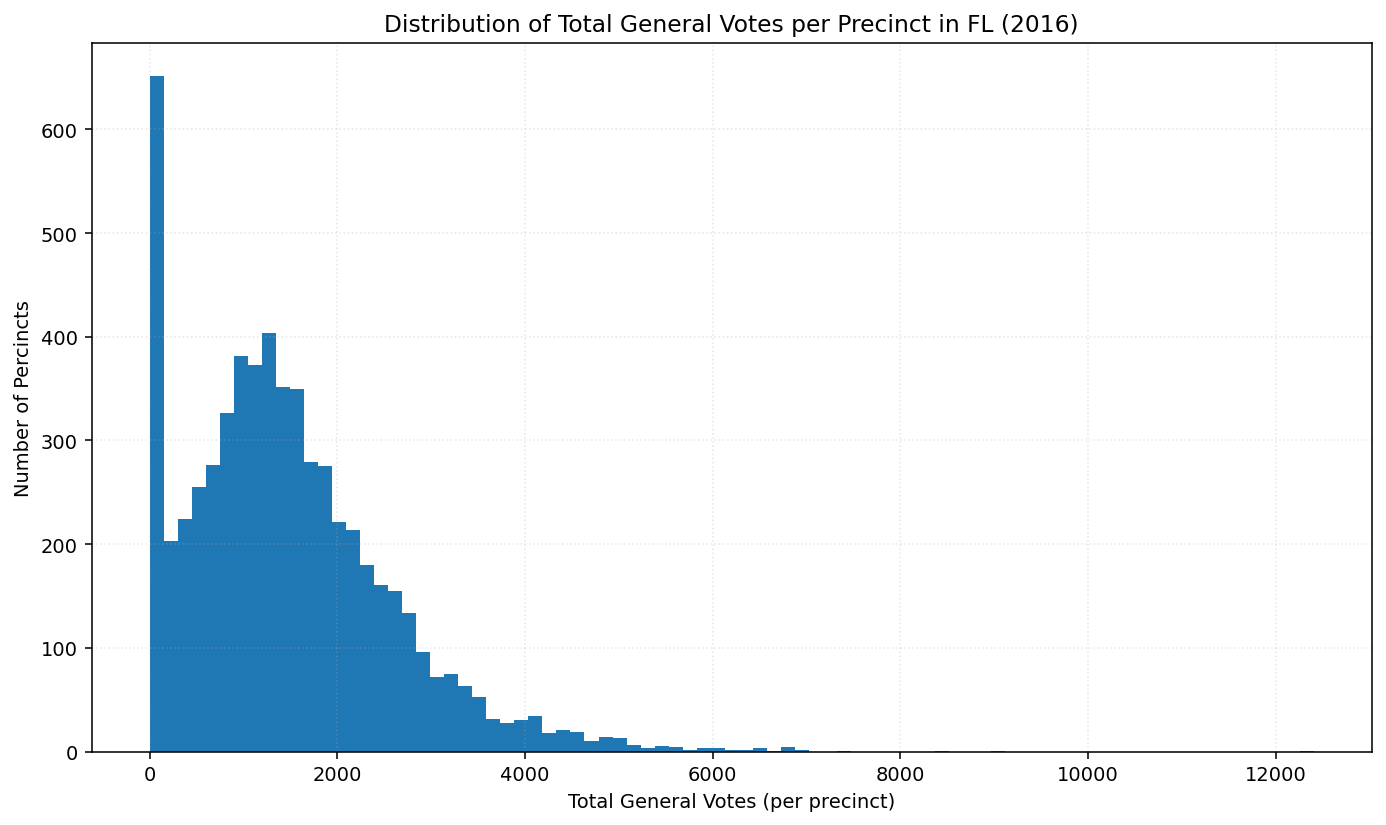

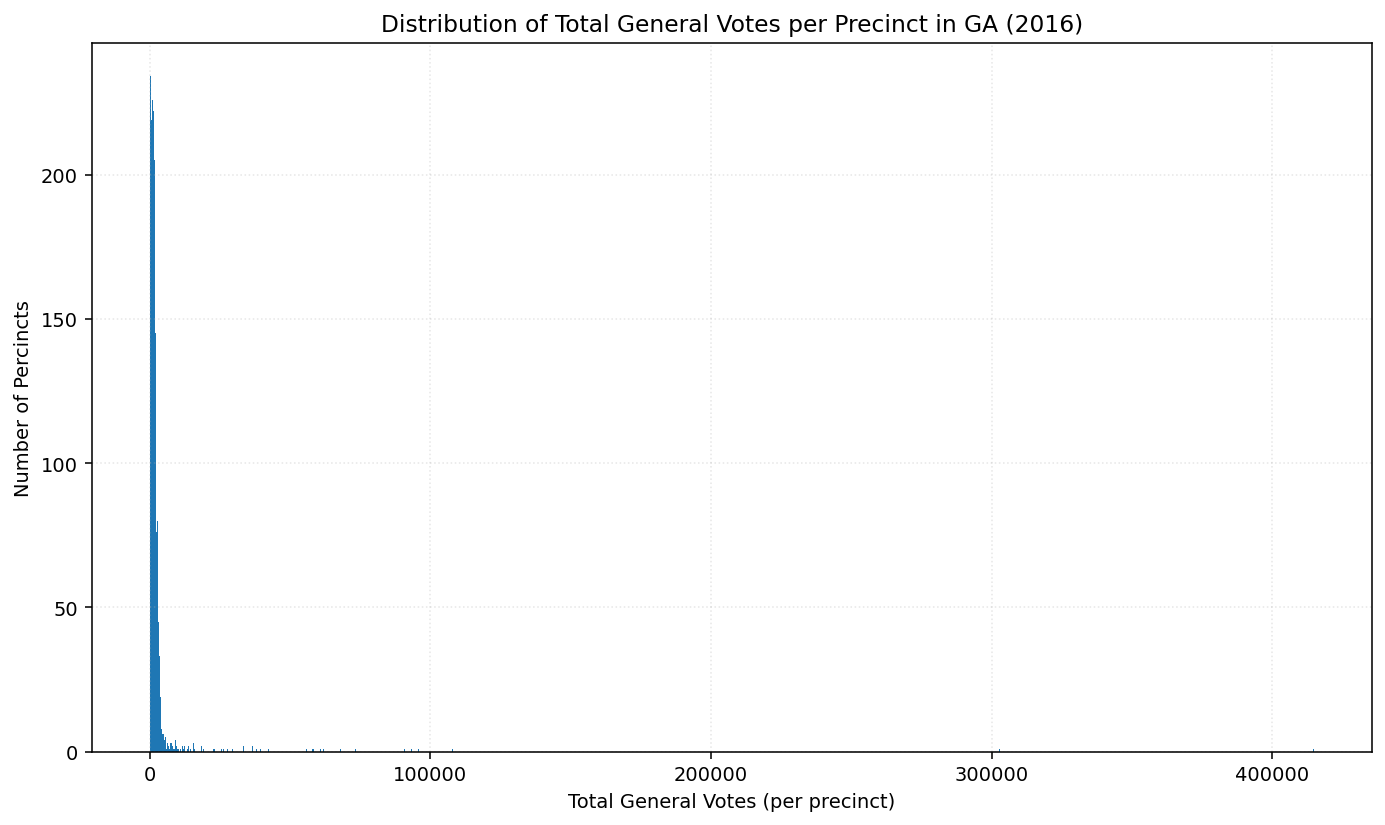

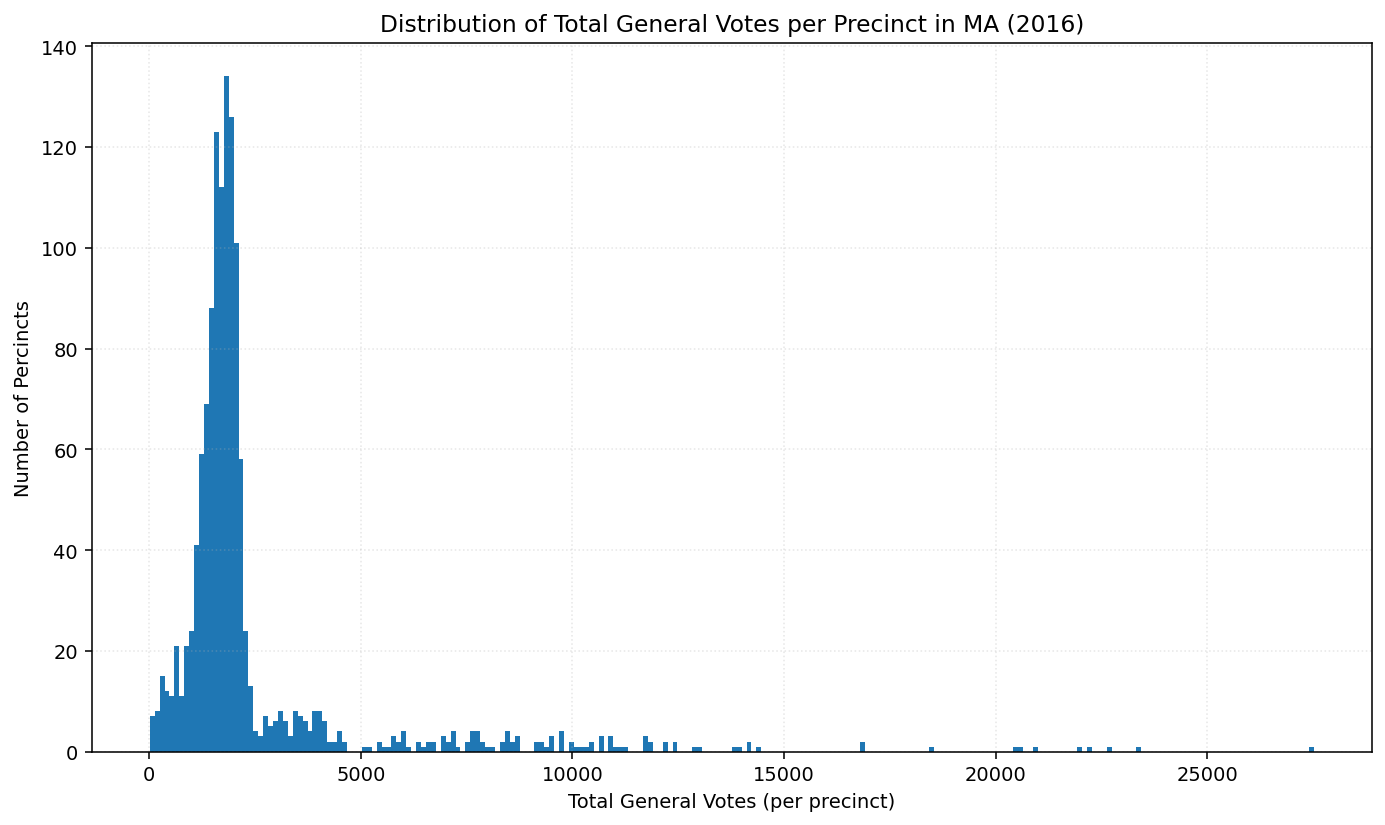

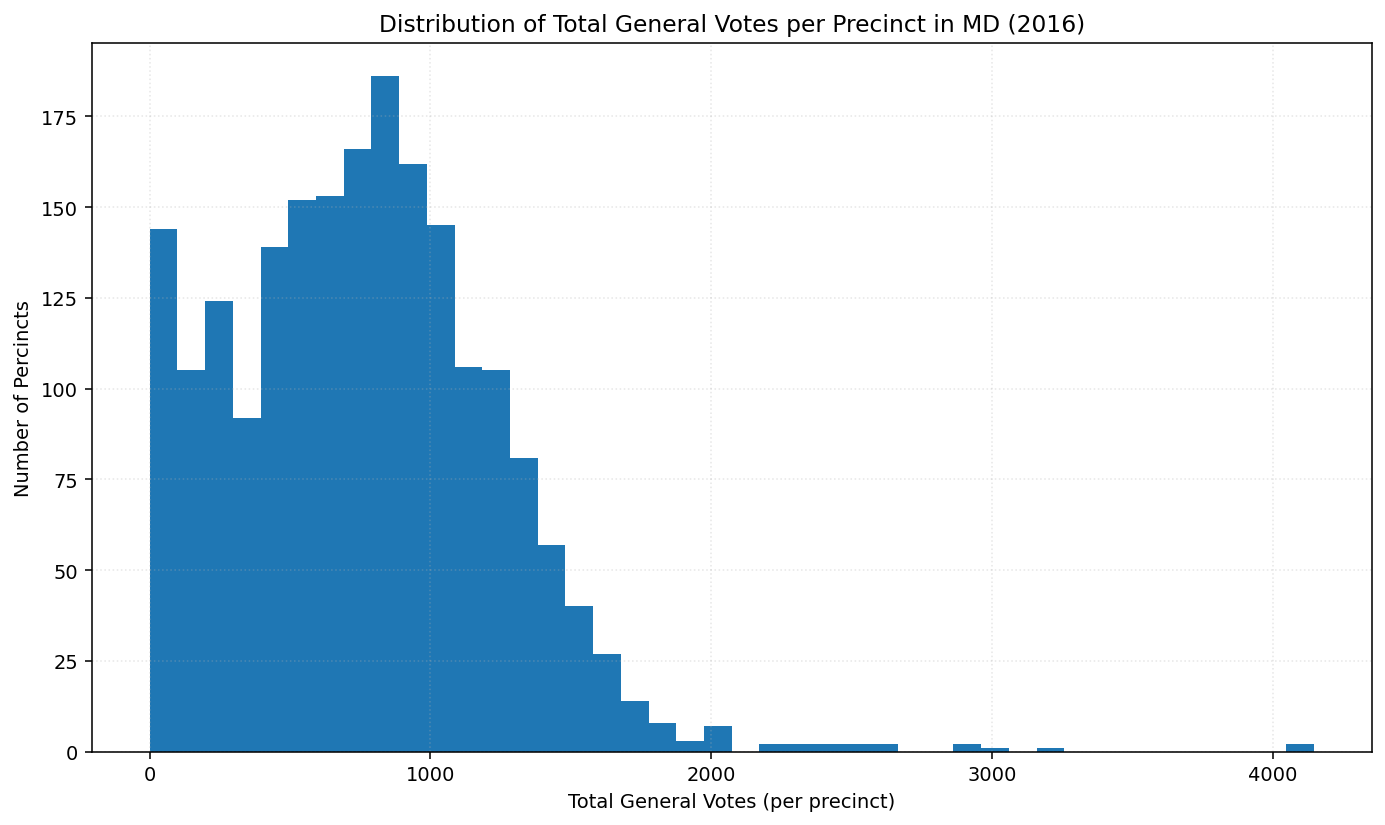

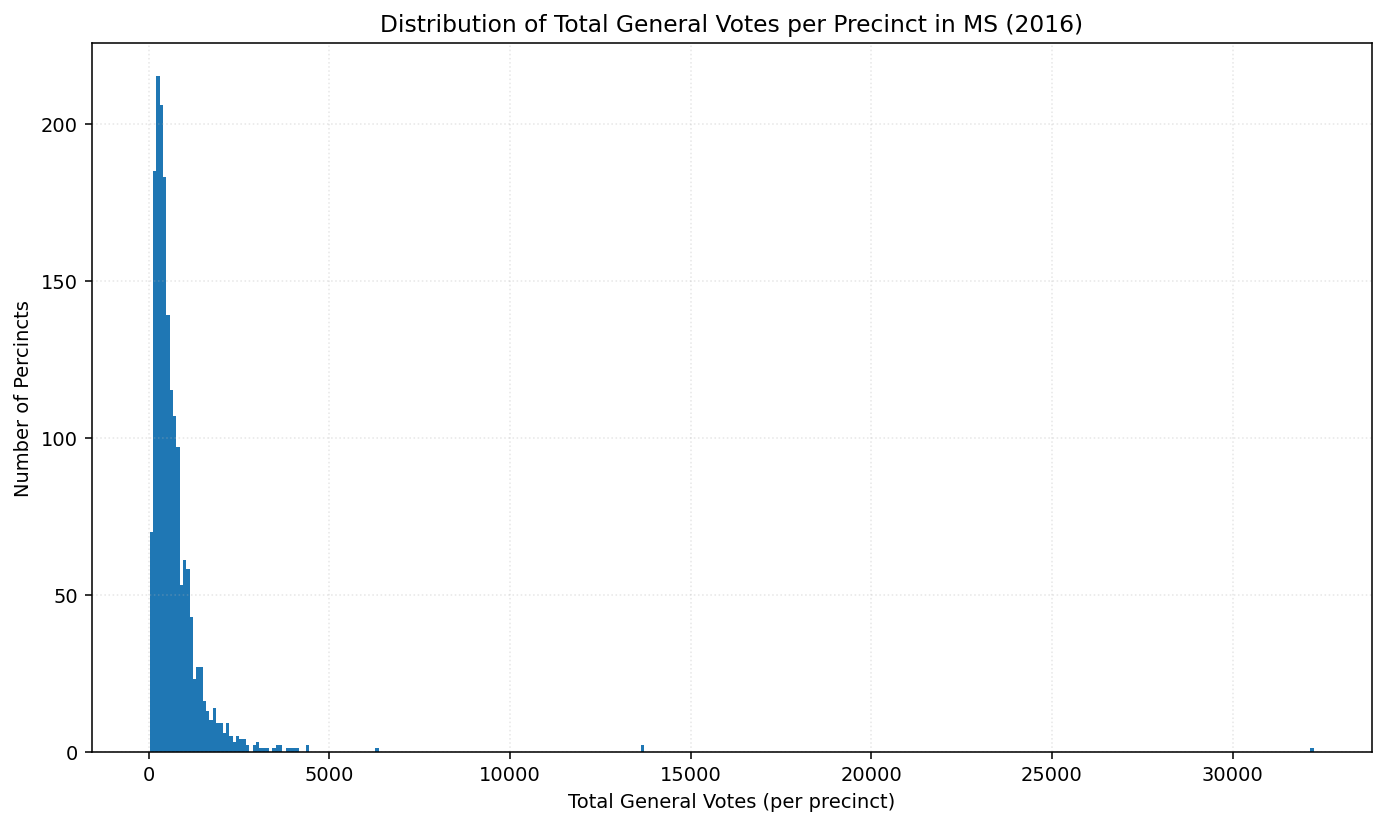

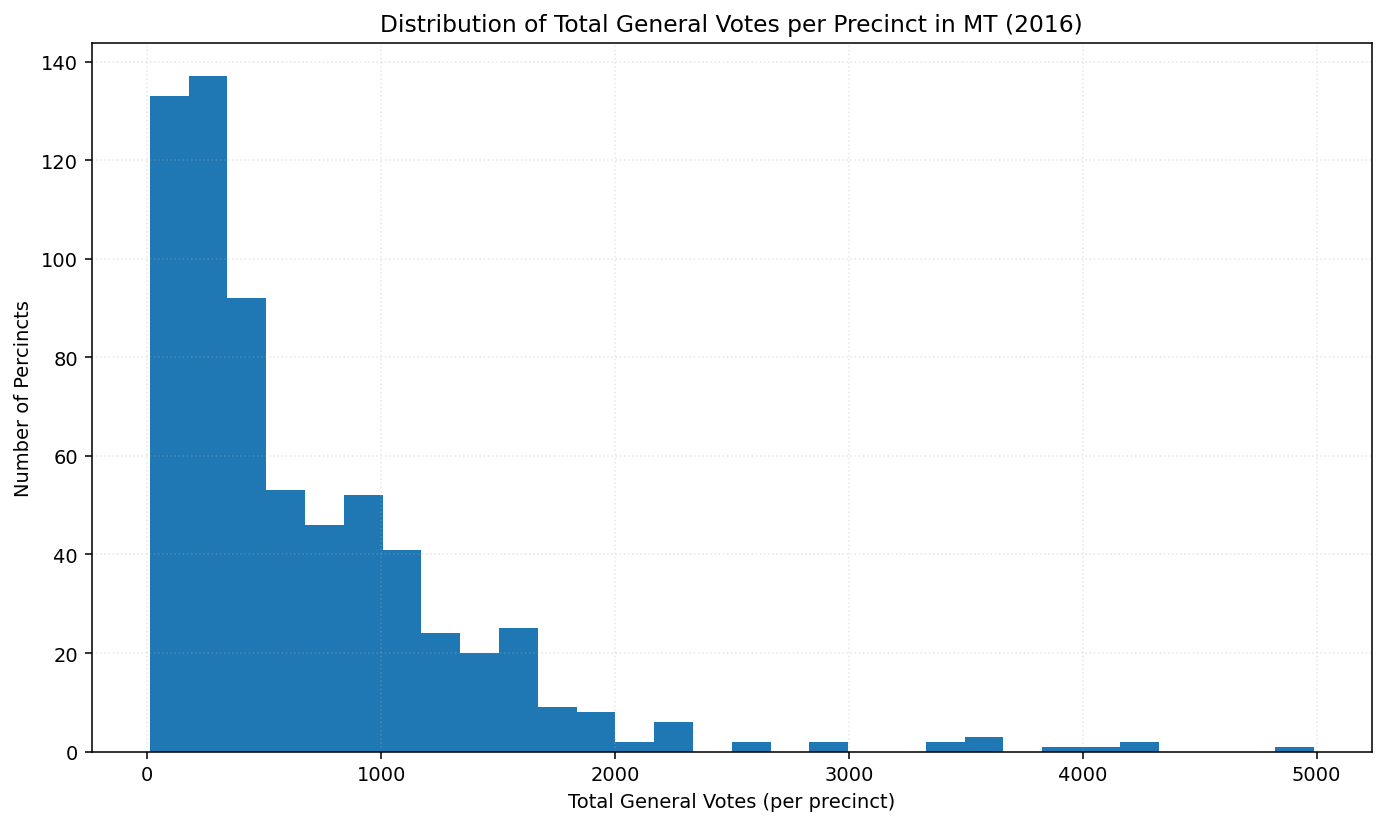

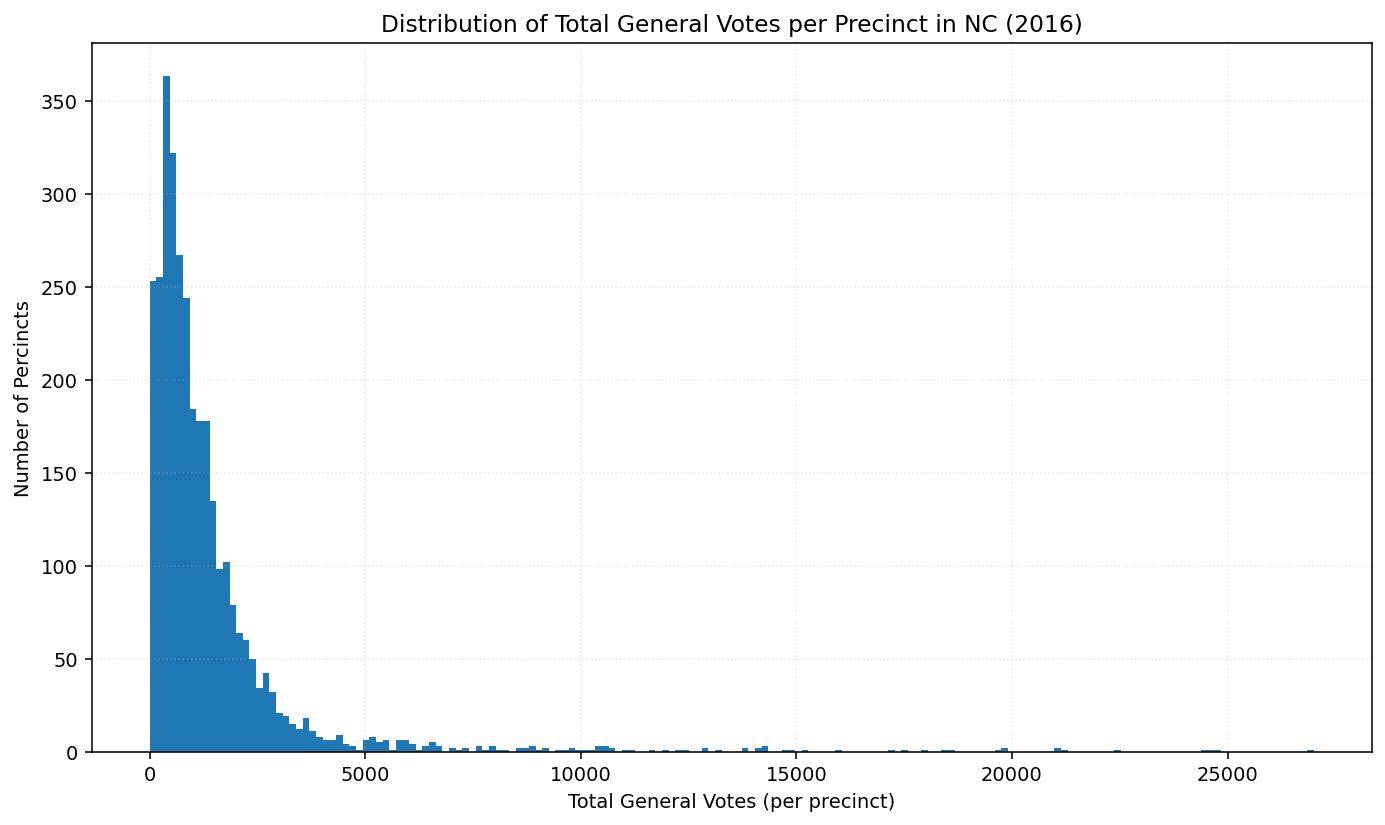

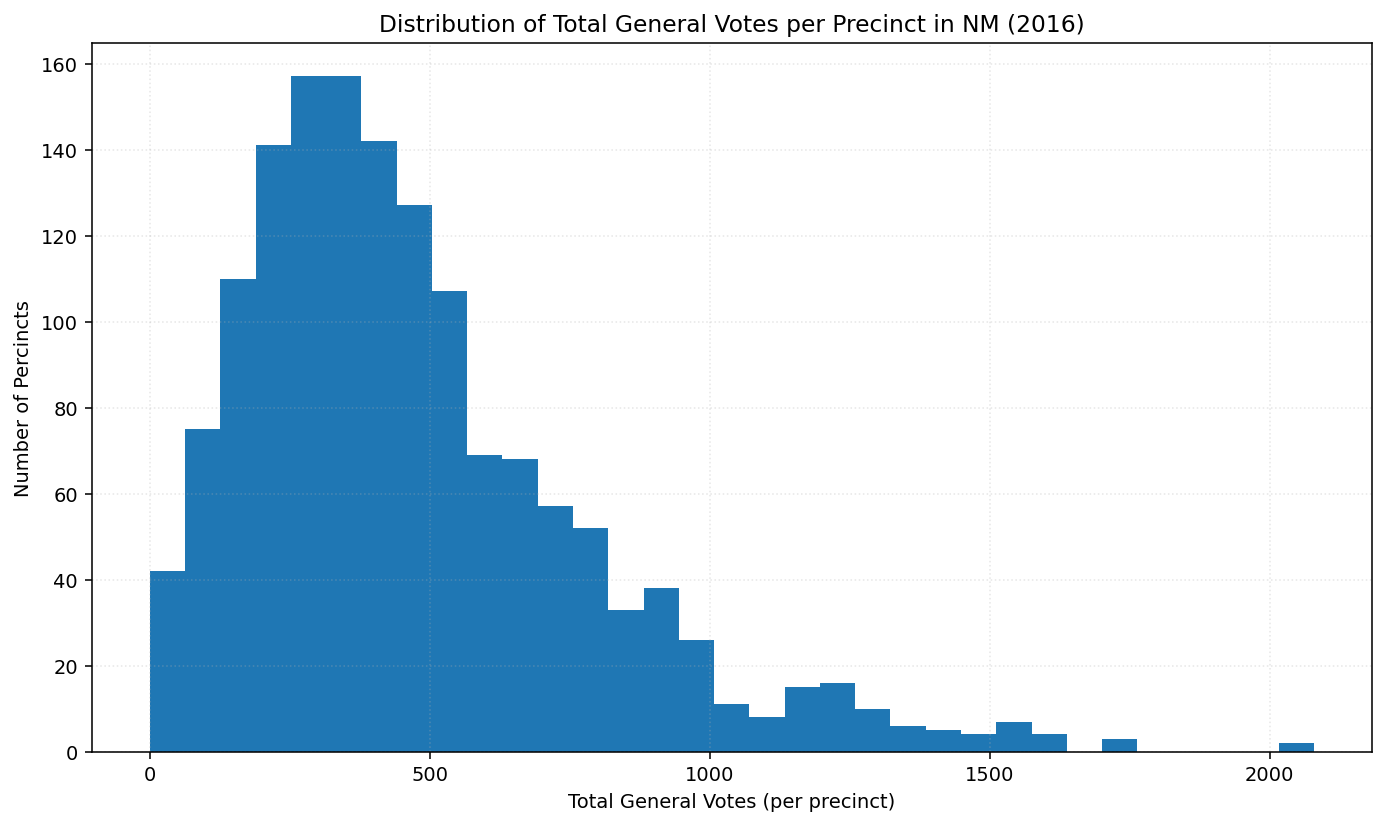

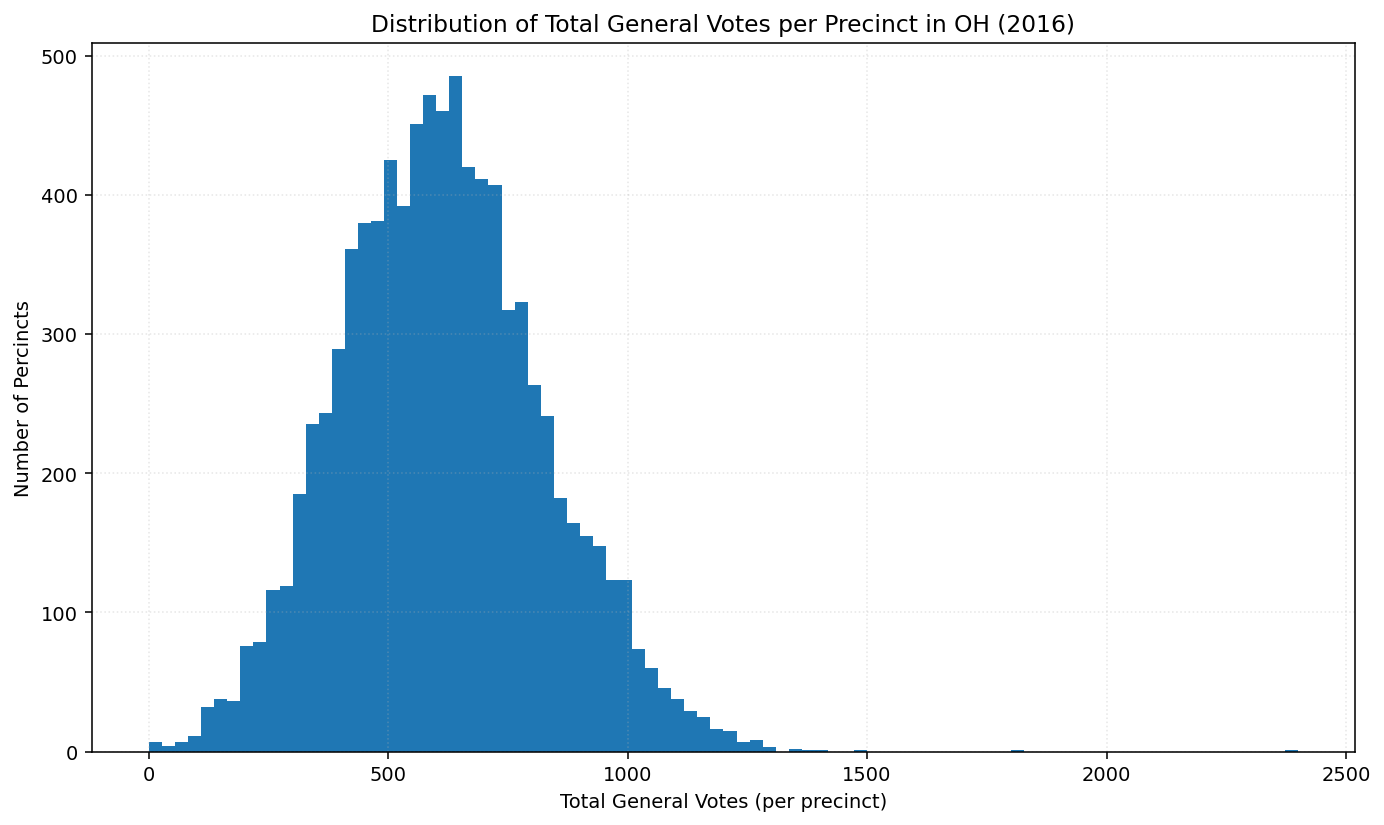

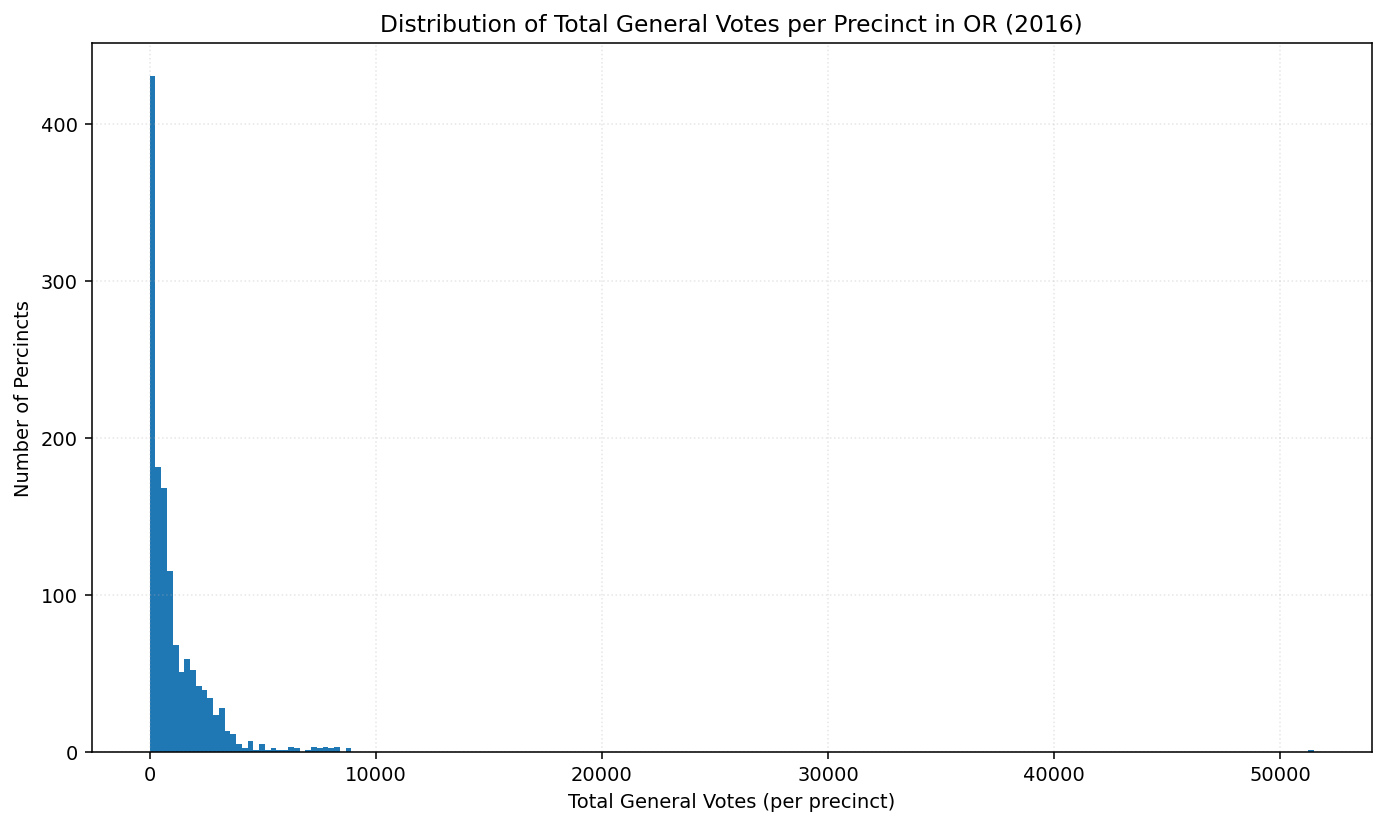

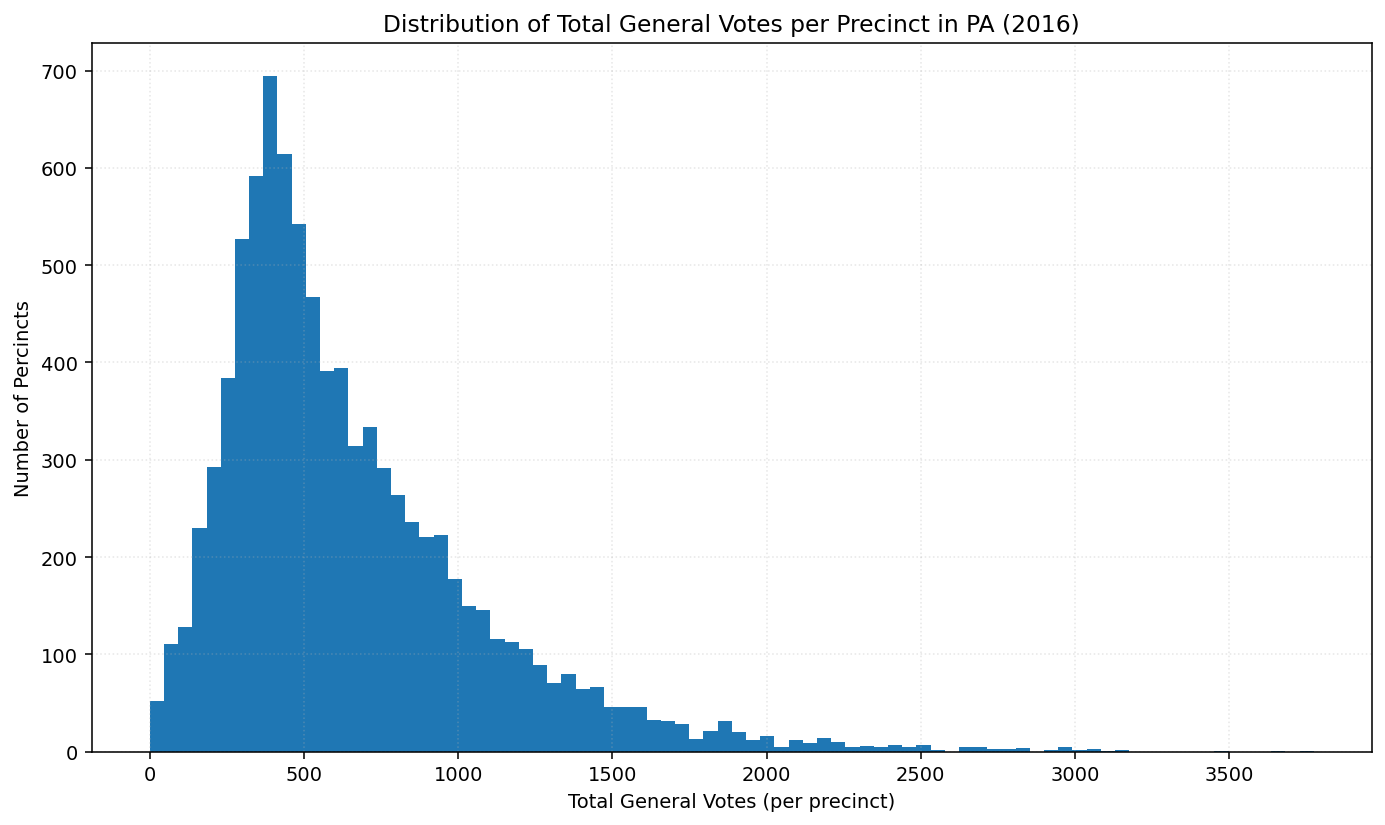

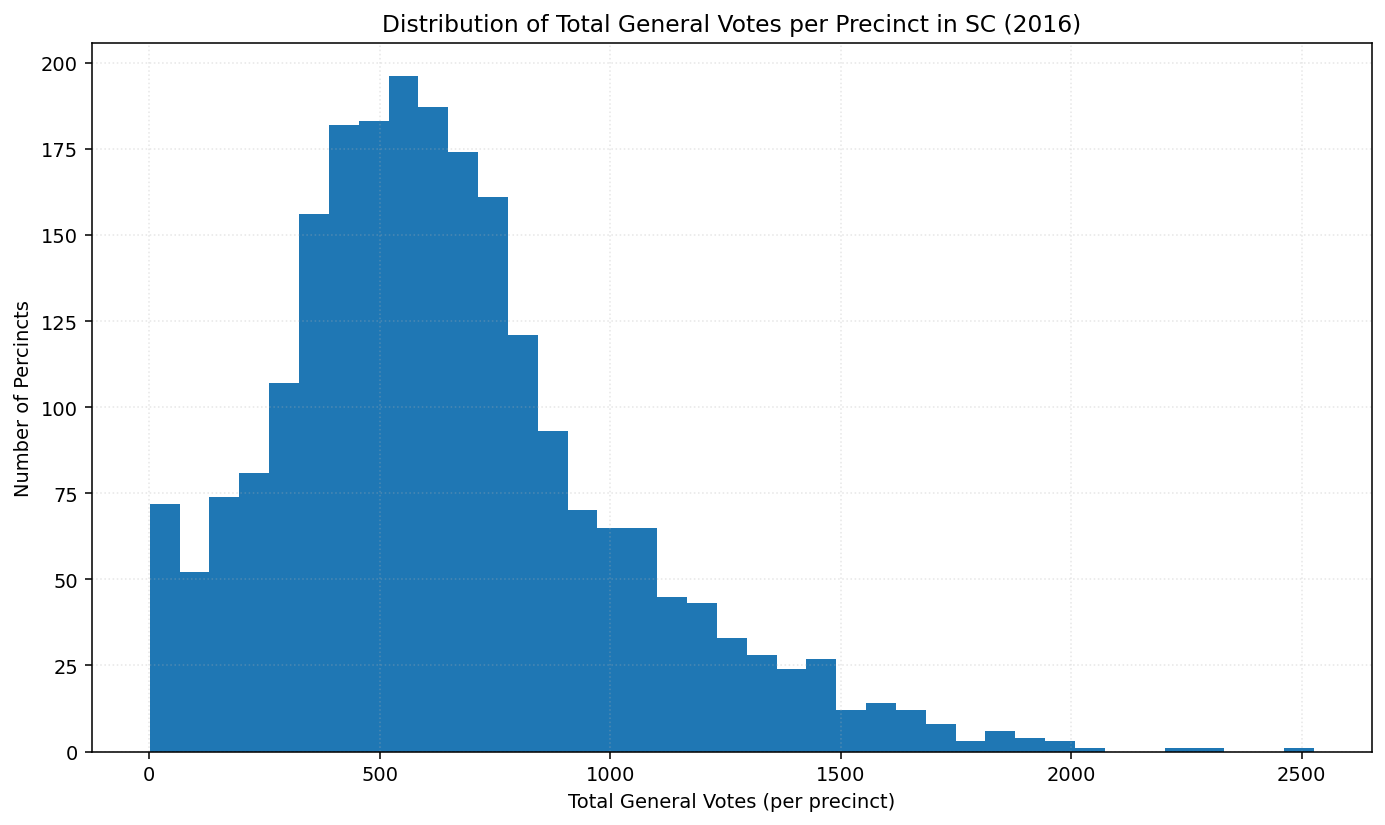

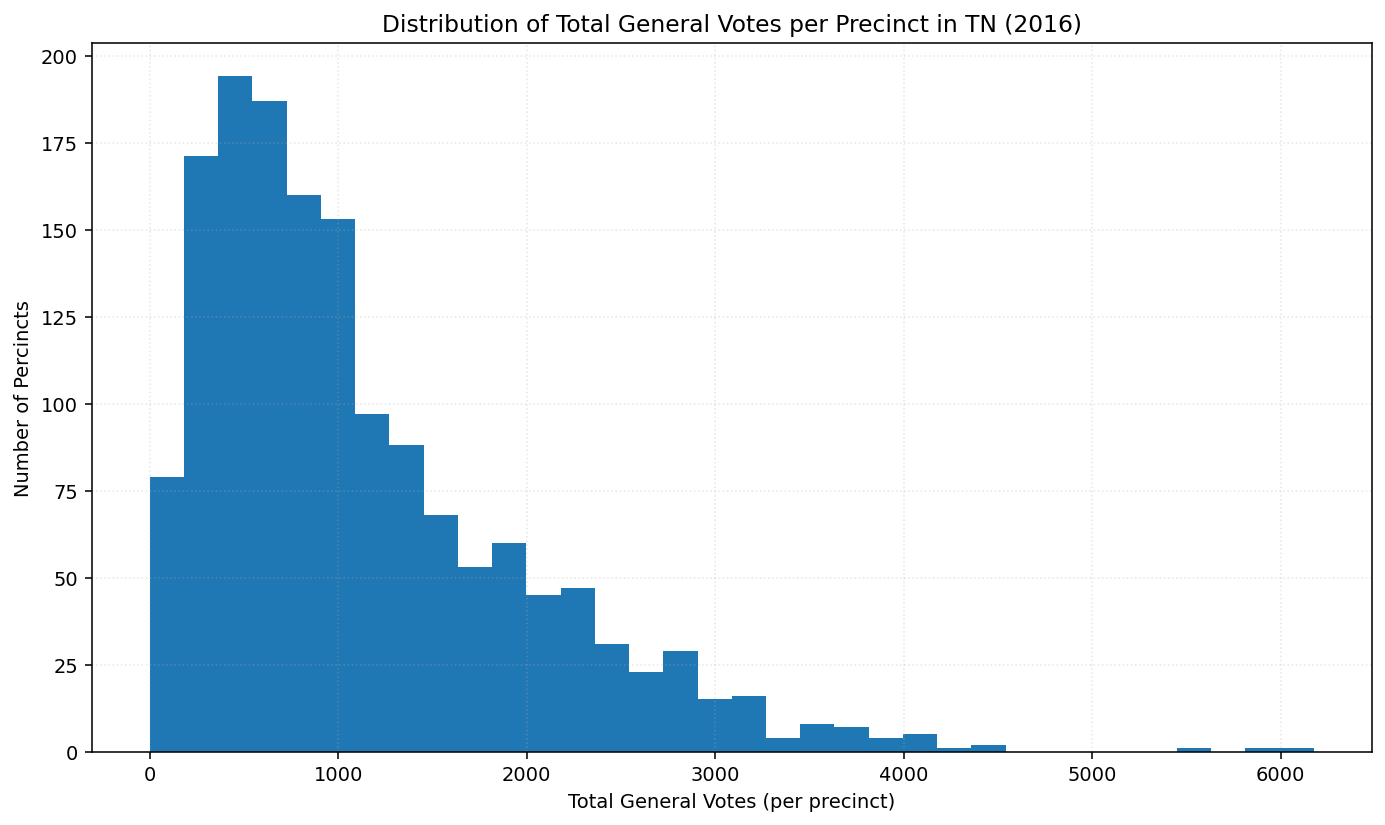

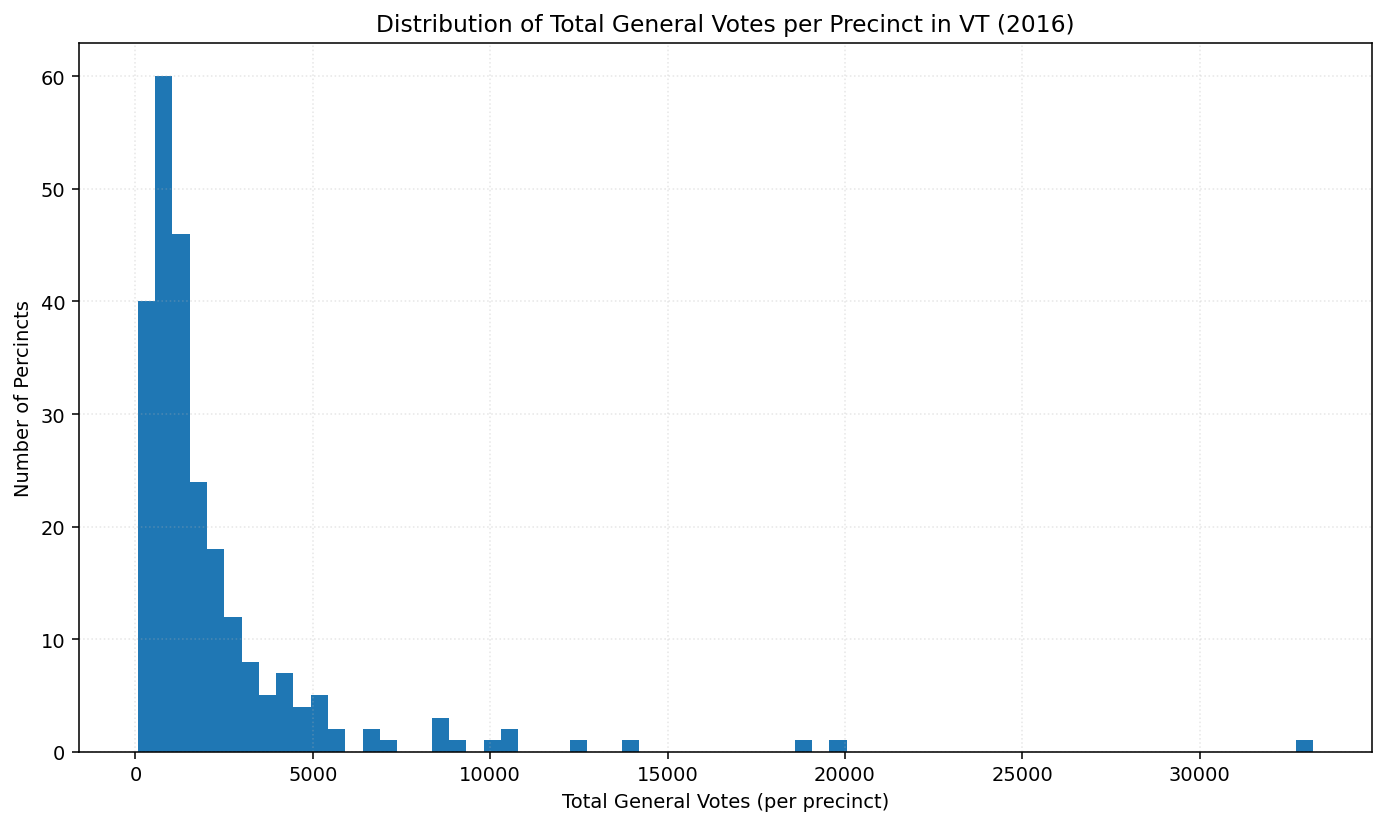

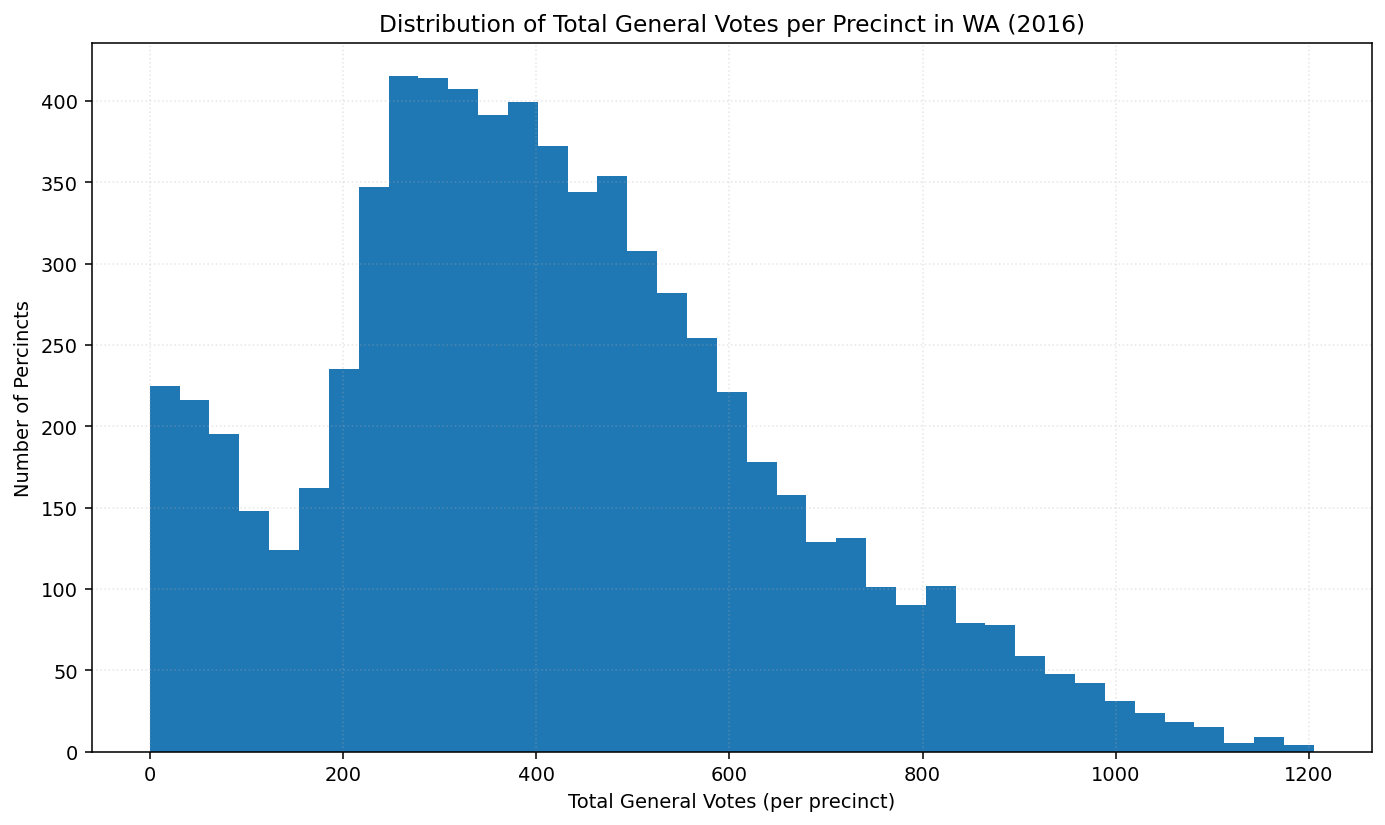

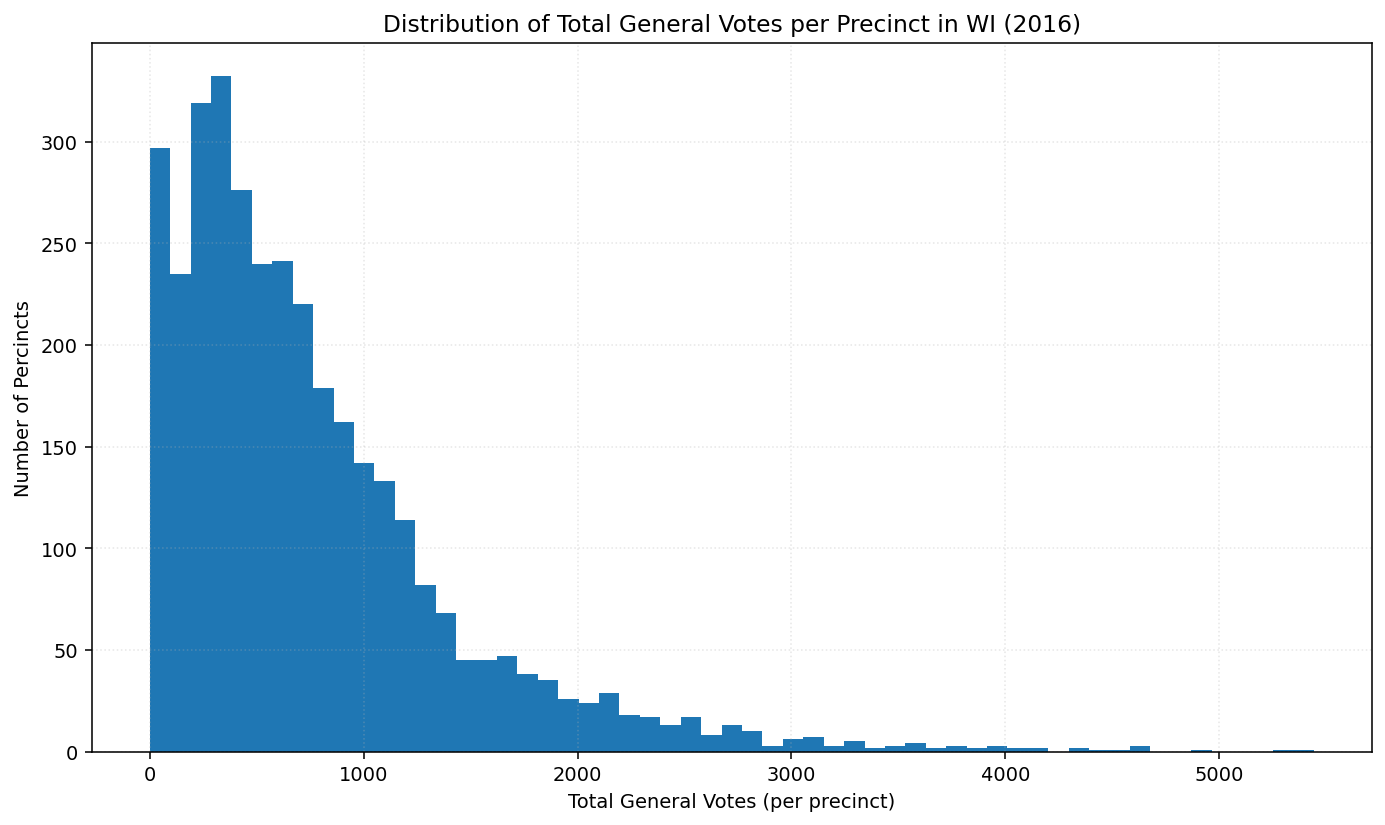

In [24]:
states_2016 = sorted(dt_2016['state'].unique())

for state in states_2016:
    state_df_2016 = dt_2016[dt_2016['state'] == state]
    data = state_df_2016['general_total_votes'].dropna().values
    if data.size == 0:
        continue
    bins = freedman_diaconis_bins(data)
    fig, ax = plt.subplots()
    ax.hist(data, bins=bins)
    ax.set_title(f'Distribution of Total General Votes per Precinct in {state} (2016)')
    ax.set_xlabel('Total General Votes (per precinct)')
    ax.set_ylabel('Number of Percincts')
    ax.grid(True, linestyle=':', alpha=0.3)
    plt.tight_layout()
    plt.show()

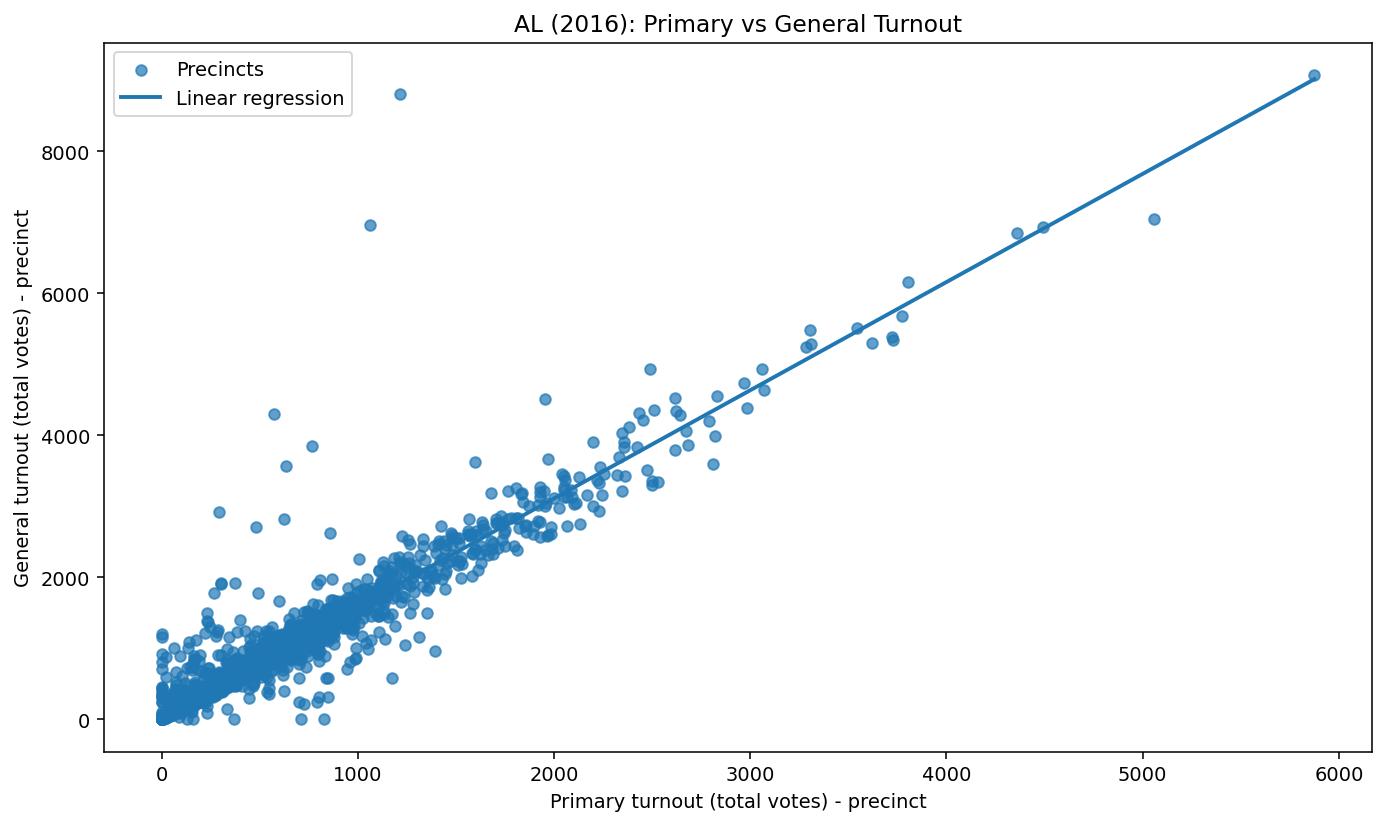

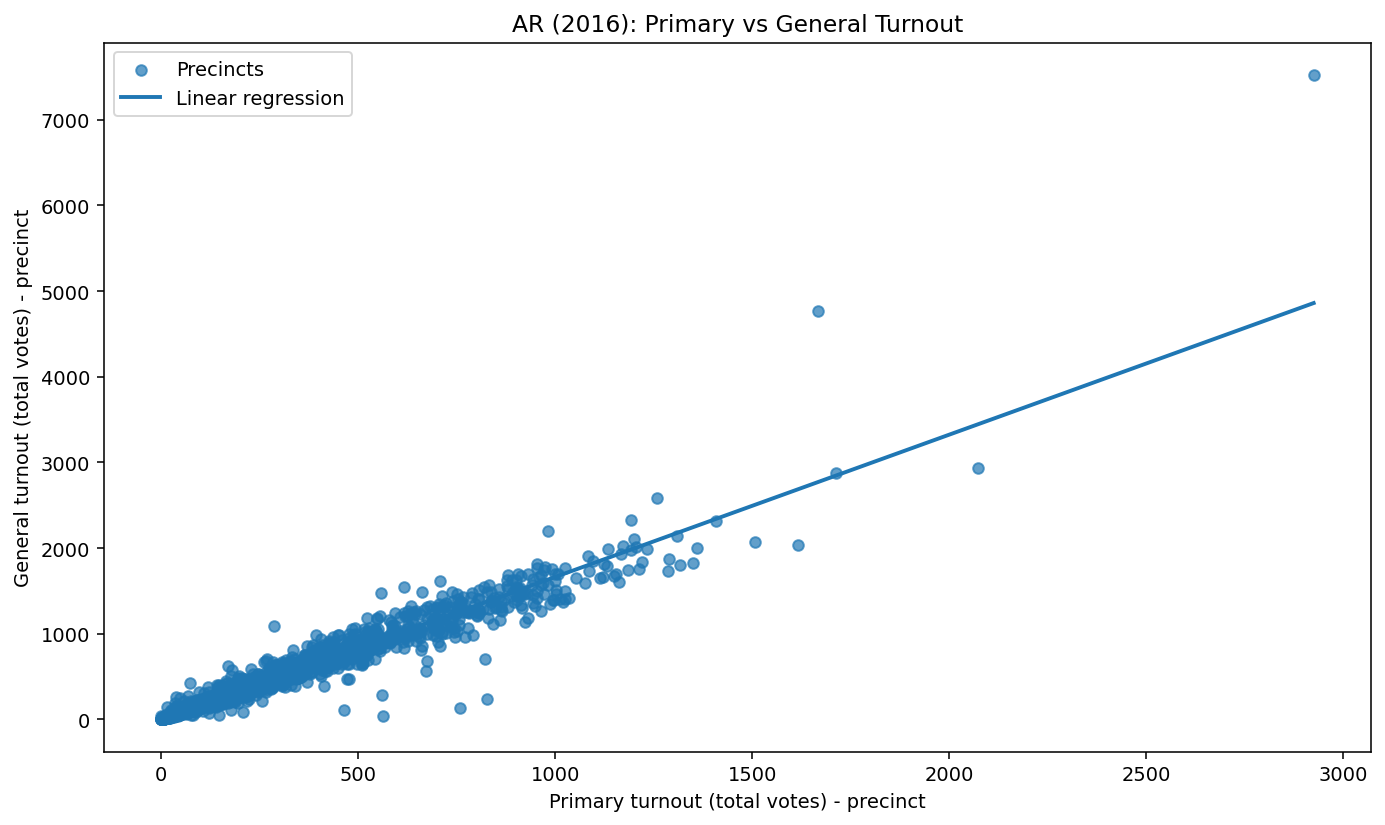

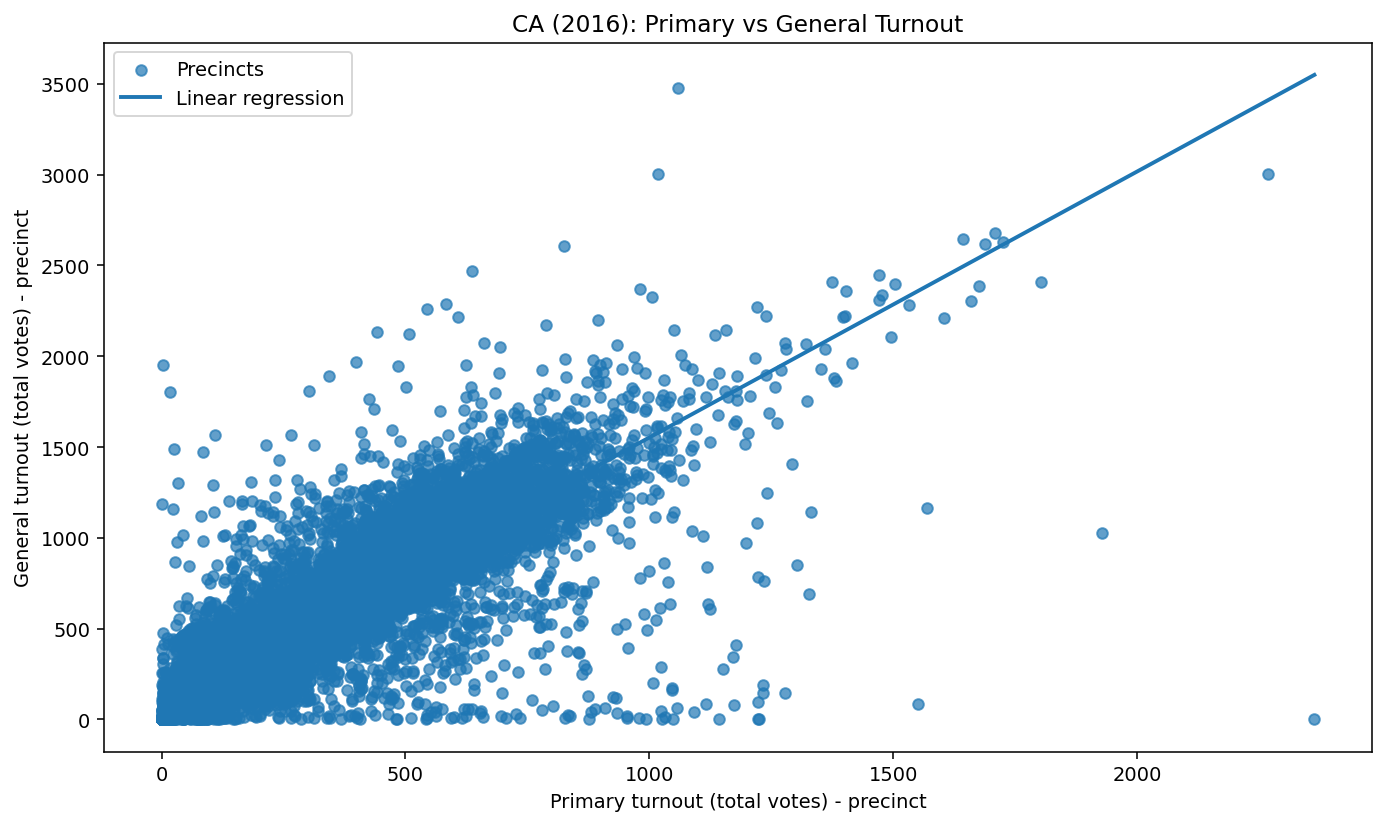

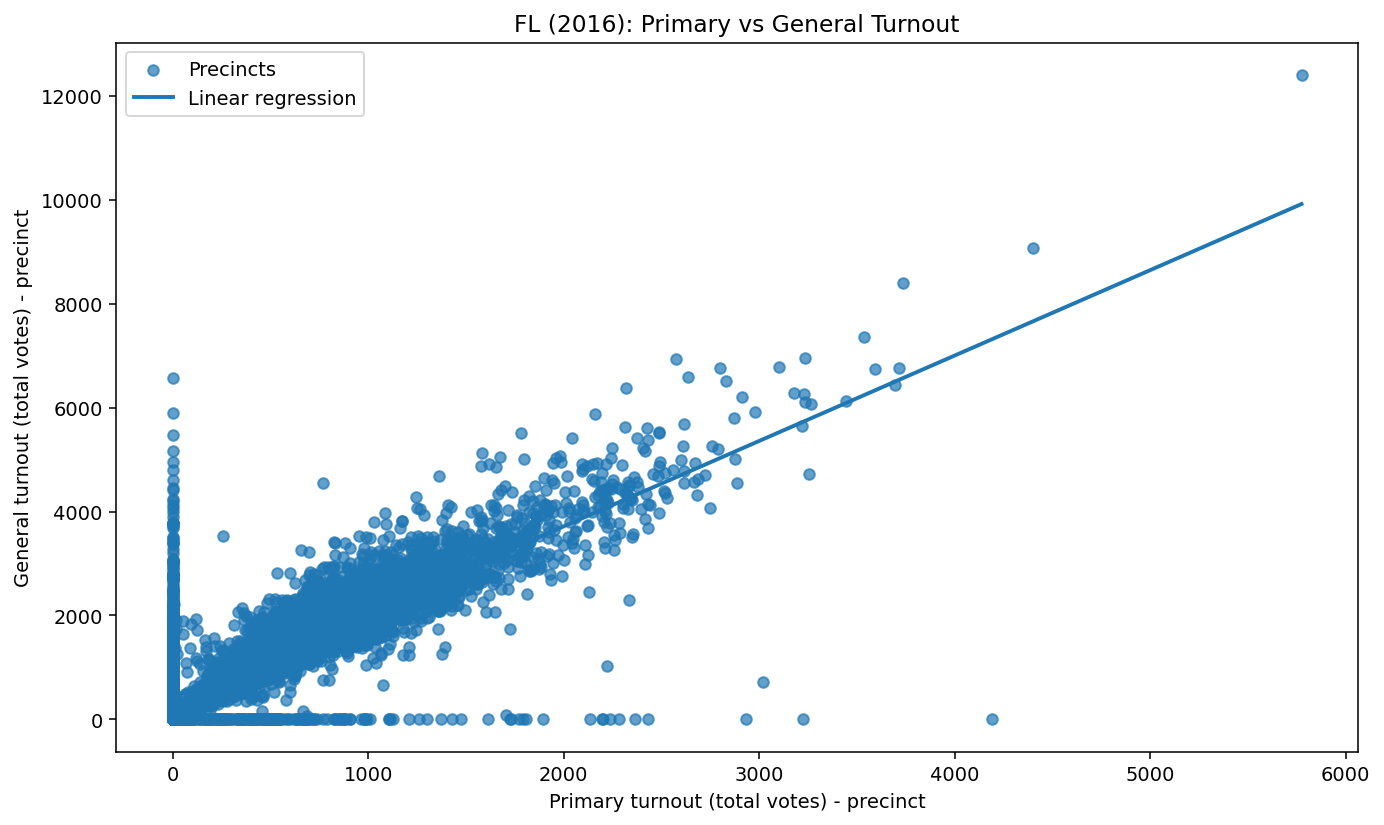

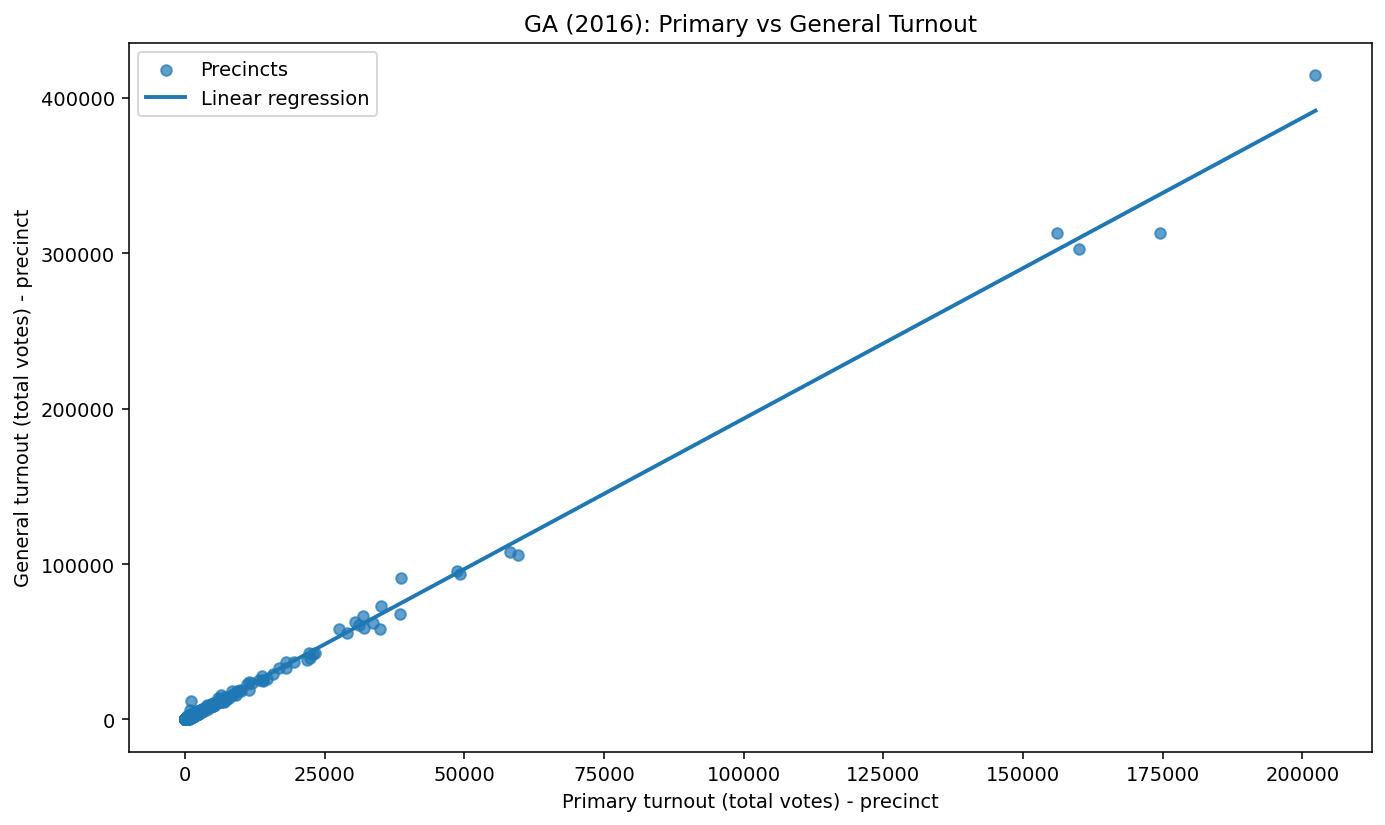

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [25]:
beta_0_2016 = {}
beta_1_2016 = {}

for state in states_2016:
    state_df_2016 = dt_2016[dt_2016['state'] == state].copy()
    X = state_df_2016['primary_total_votes'].values.reshape(-1, 1)
    y = state_df_2016['general_total_votes'].values
    if X.shape[0] < 2:
        continue
    reg = LinearRegression()
    reg.fit(X, y)
    beta_0_2016[state] = reg.intercept_
    beta_1_2016[state] = reg.coef_[0]

    sort_idx = np.argsort(X[:, 0])
    X_sorted = X[sort_idx]
    y_pred = reg.predict(X_sorted)

    plt.figure()
    plt.scatter(
        state_df_2016['primary_total_votes'],
        state_df_2016['general_total_votes'],
        alpha=0.7,
        s=30,
        label='Precincts'
    )
    plt.plot(X_sorted, y_pred, linewidth=2, label='Linear regression')
    plt.xlabel('Primary turnout (total votes) - precinct')
    plt.ylabel('General turnout (total votes) - precinct')
    plt.title(f'{state} (2016): Primary vs General Turnout')
    plt.legend()
    plt.tight_layout()
    plt.show()

coef_2016 = pd.DataFrame({
    'state': list(beta_0_2016.keys()),
    'intercept_2016': list(beta_0_2016.values()),
    'slope_2016': list(beta_1_2016.values()),
}).sort_values('state')
coef_2016

### 2.3. 2020 Presidential Election

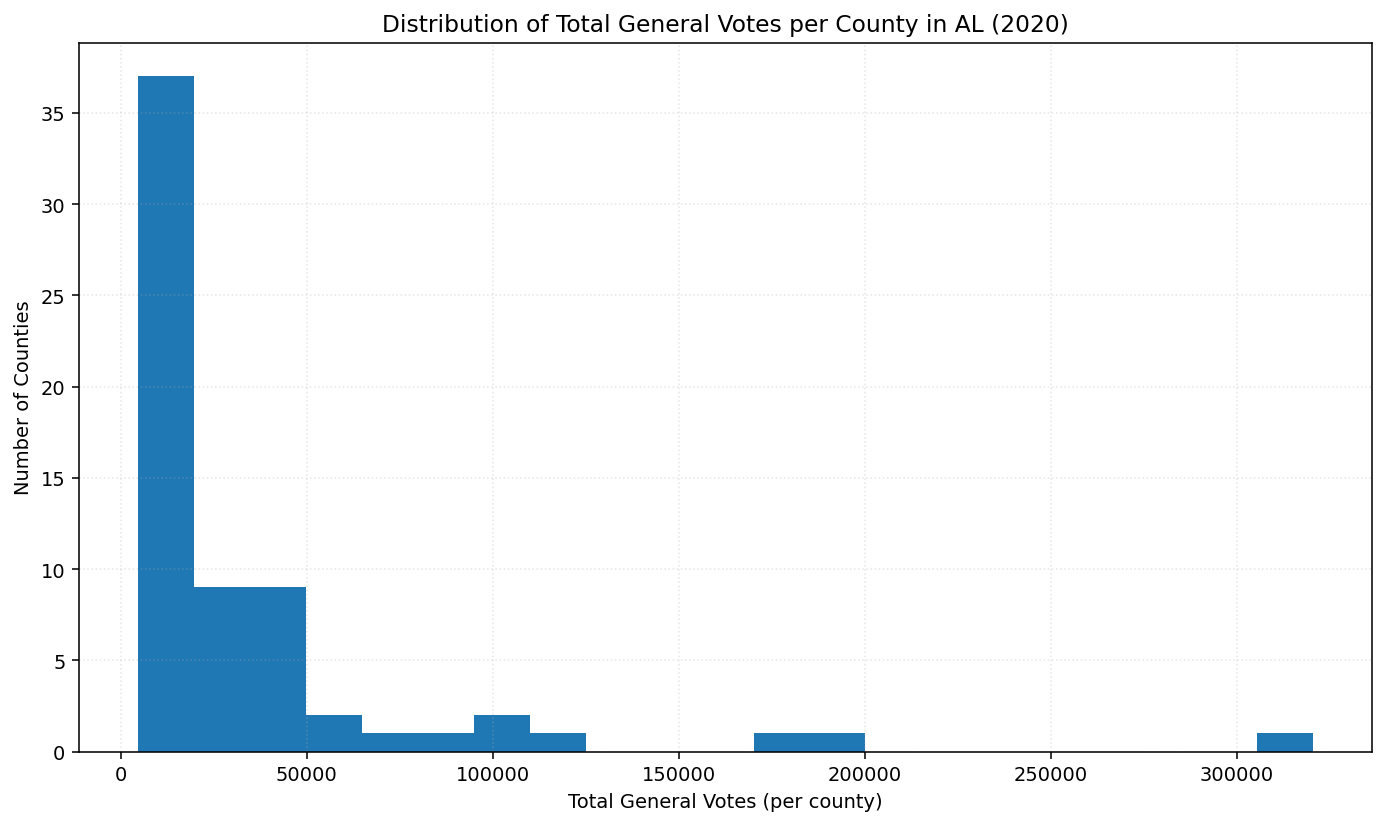

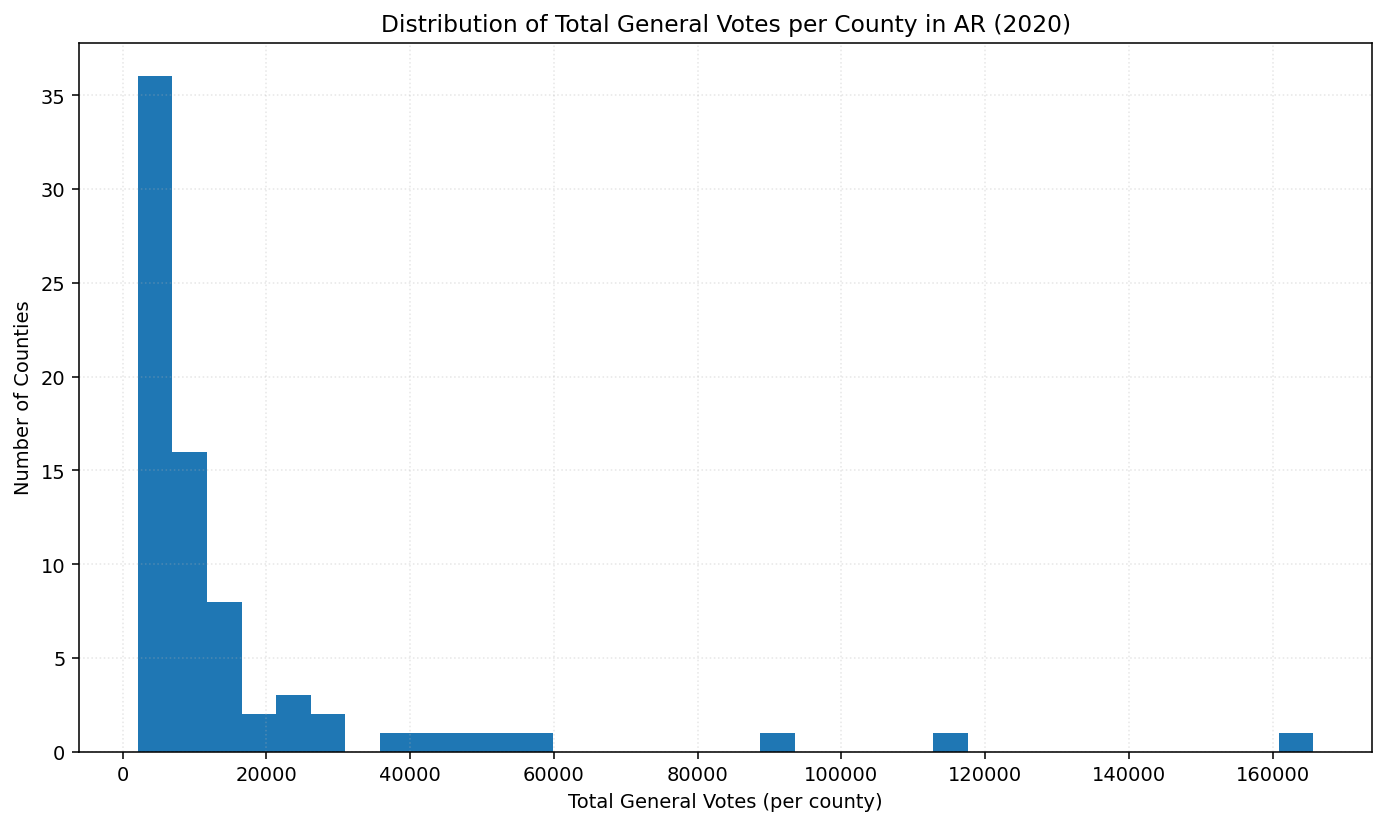

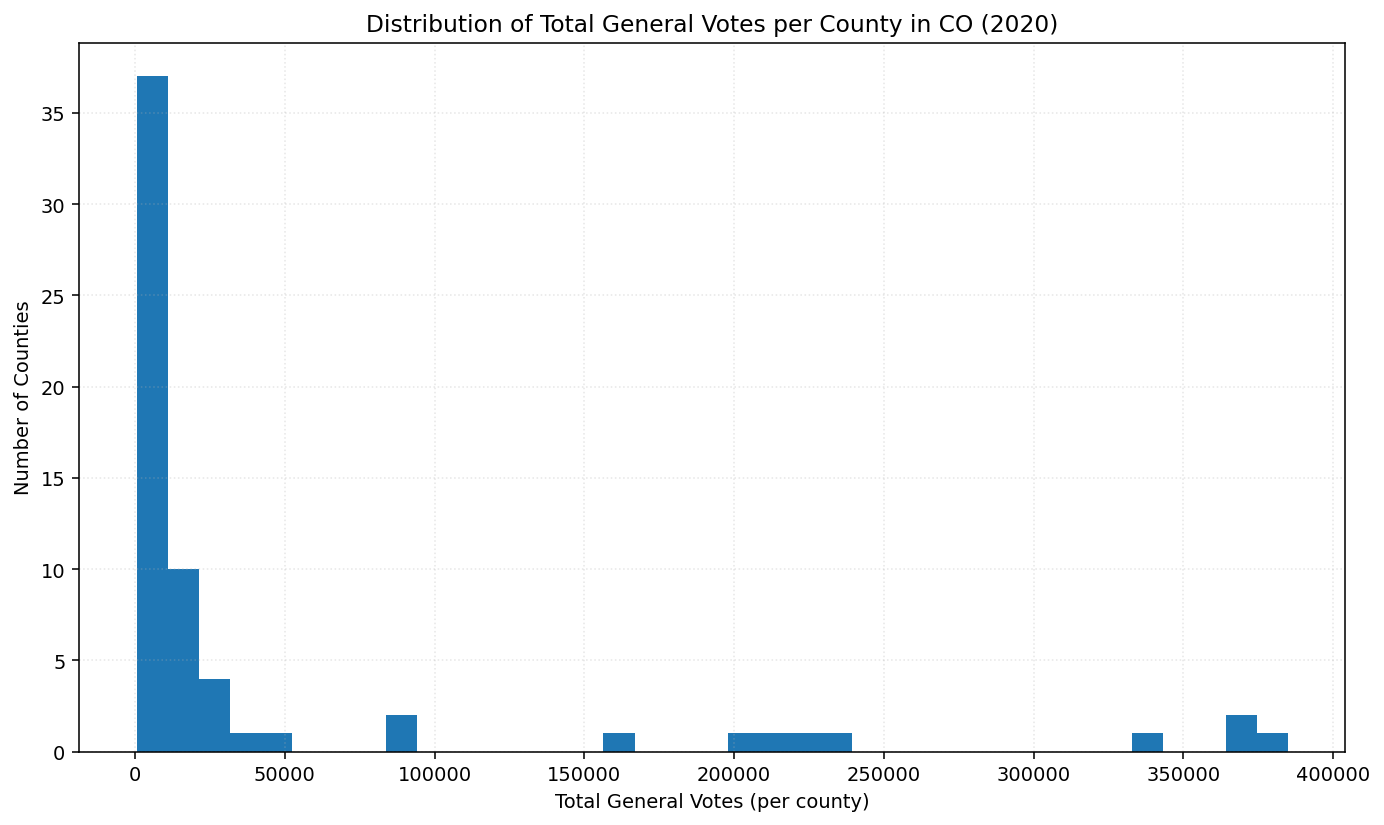

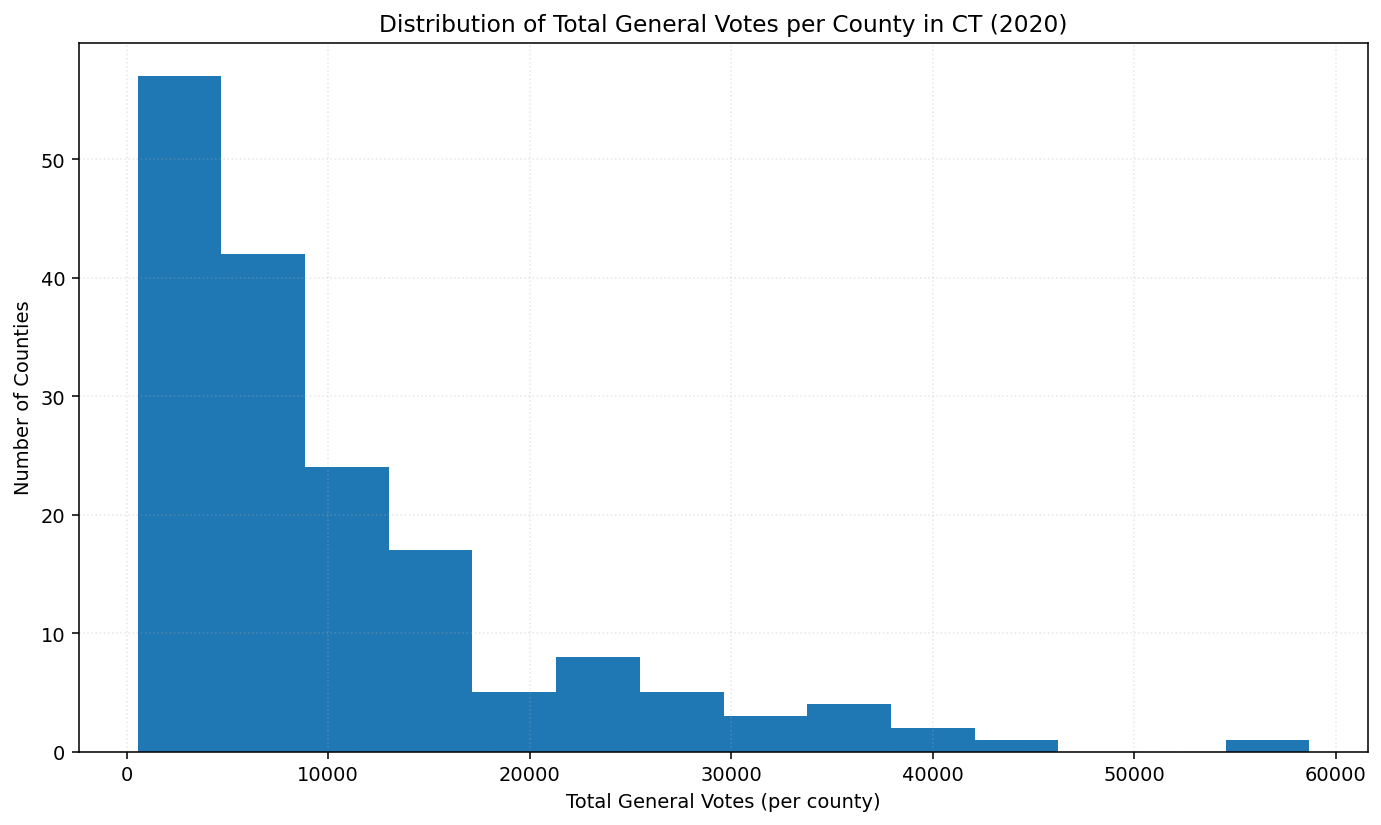

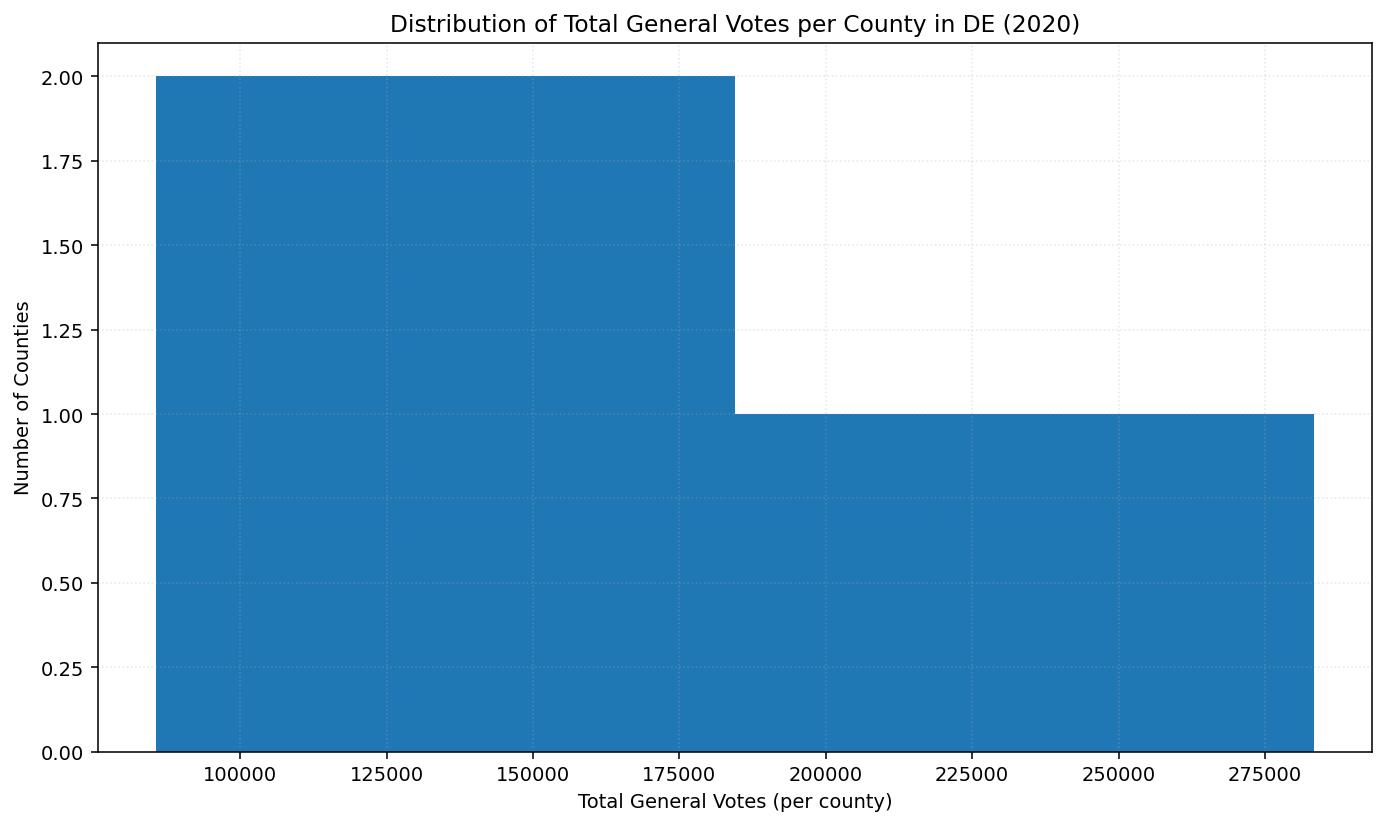

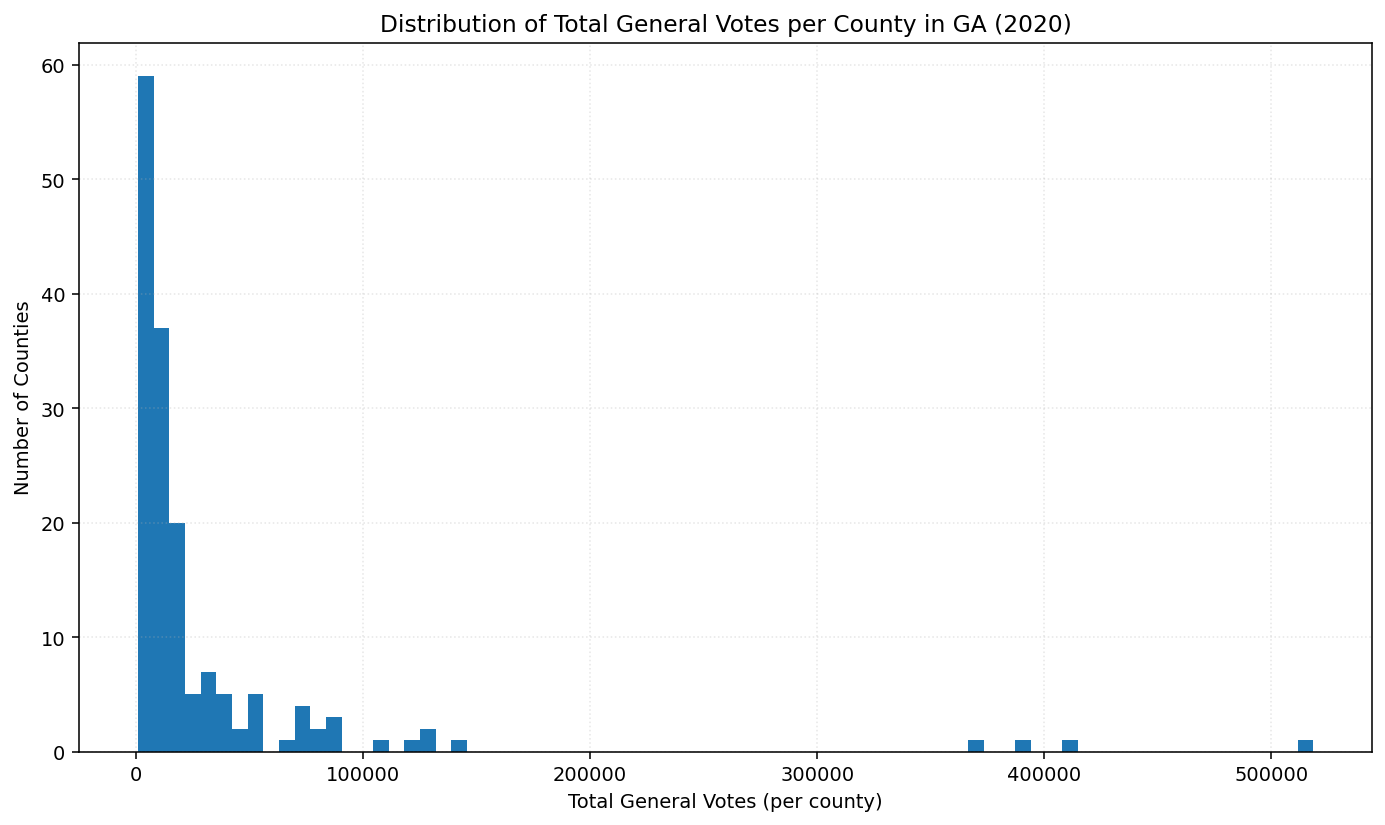

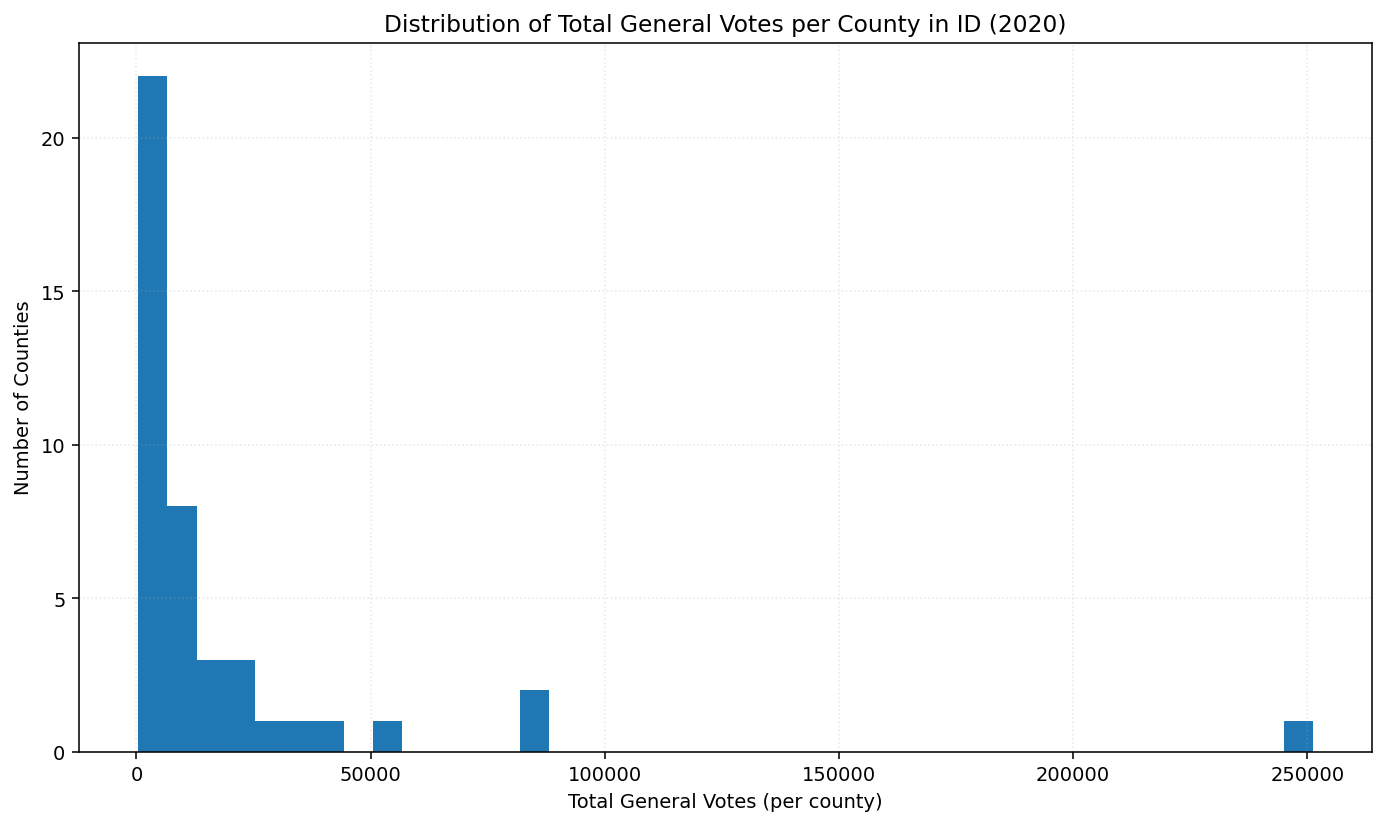

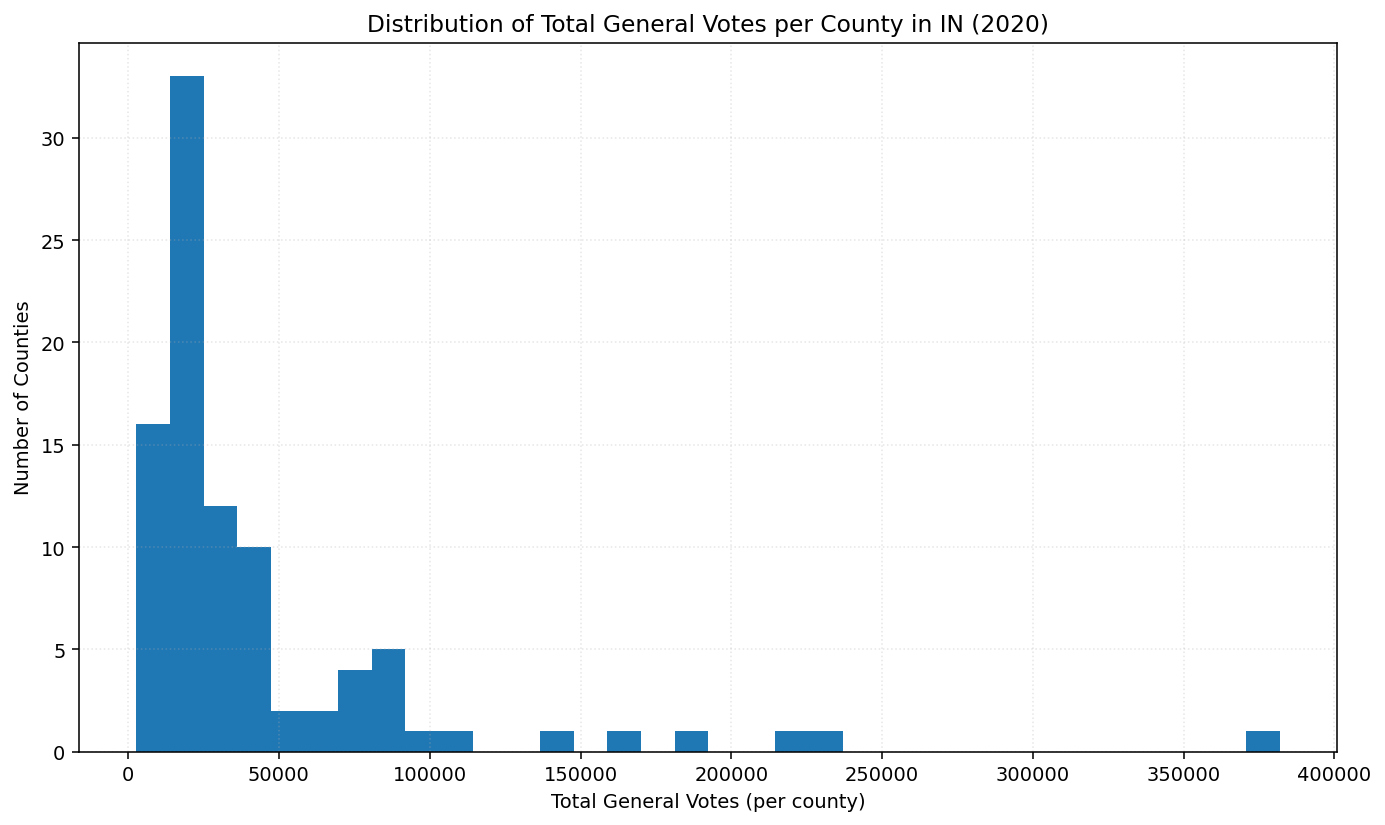

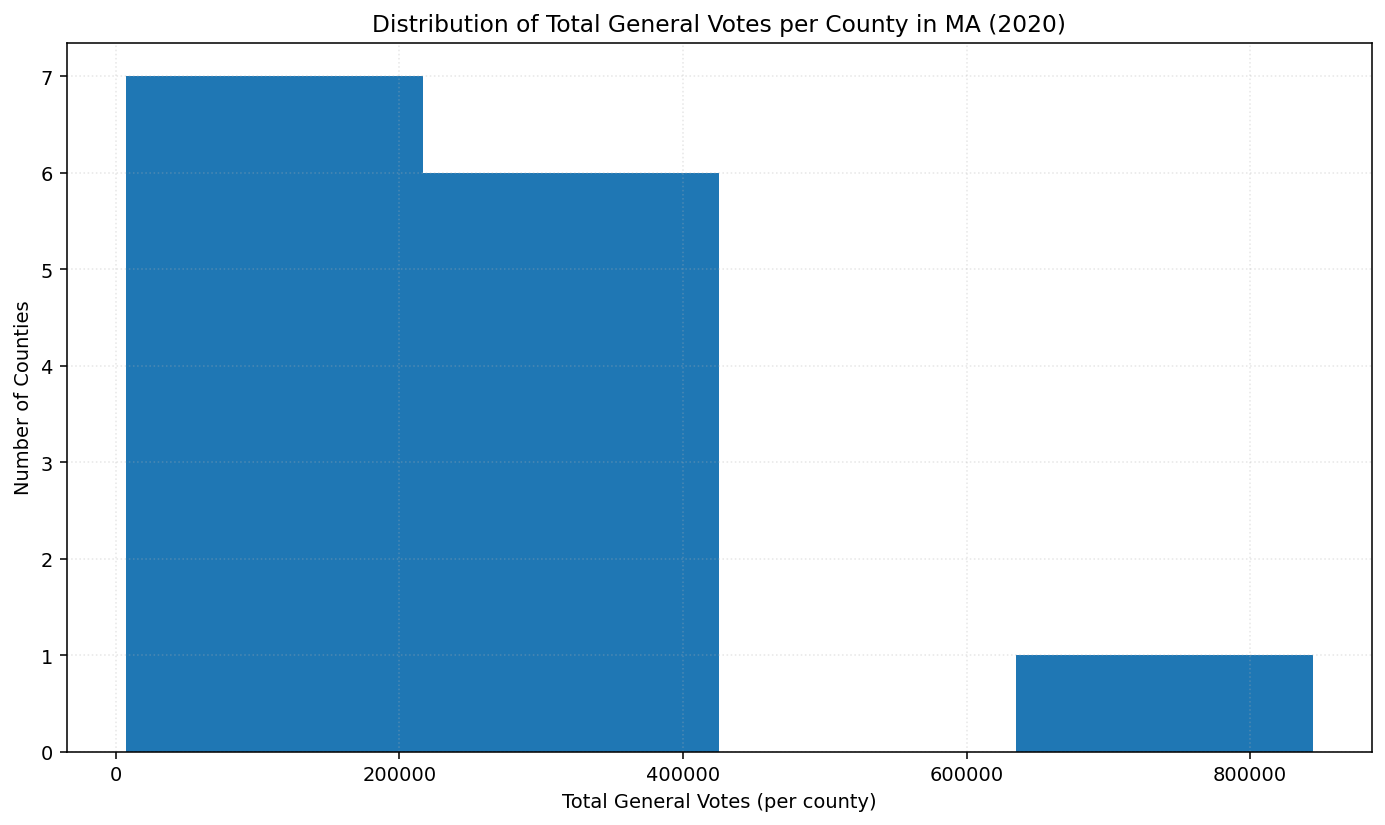

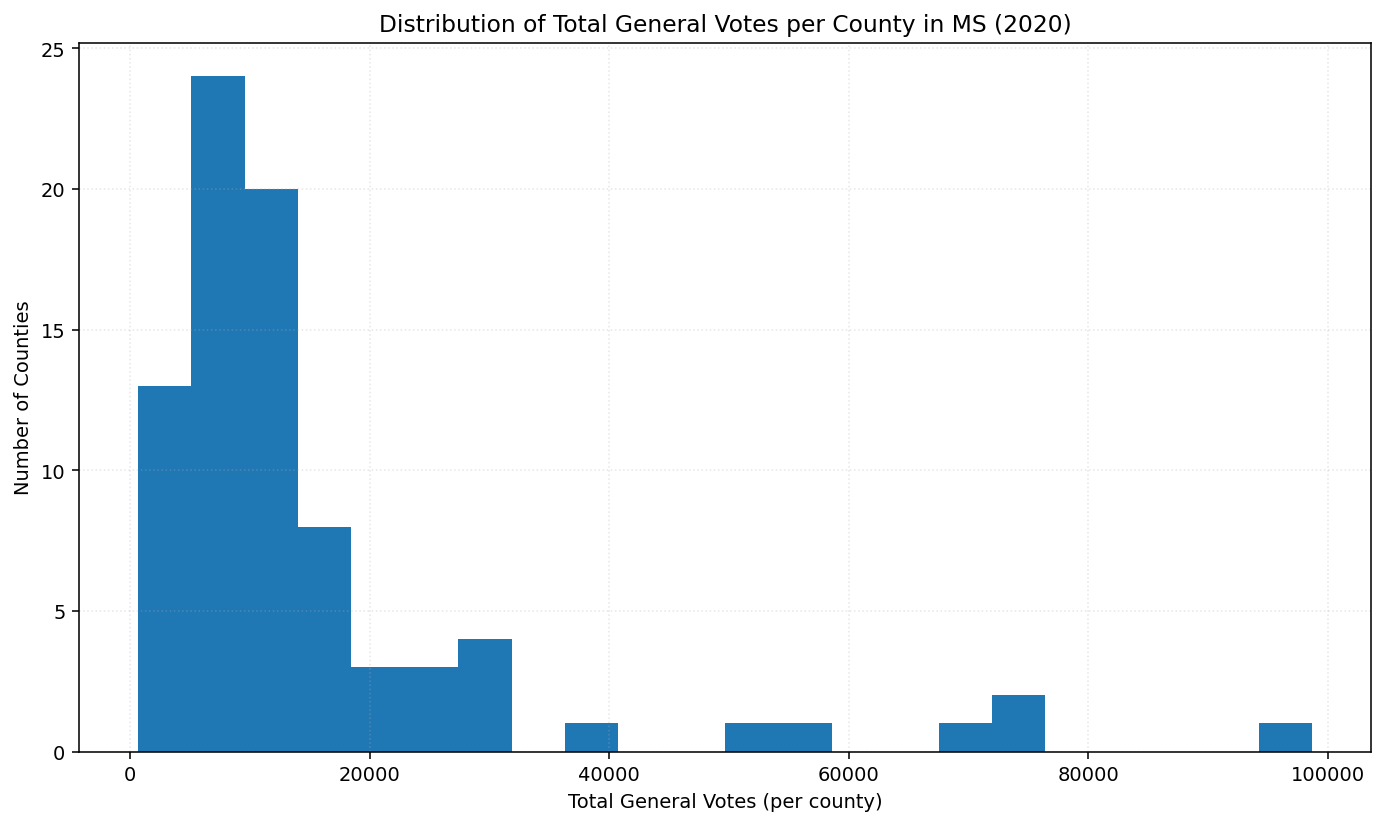

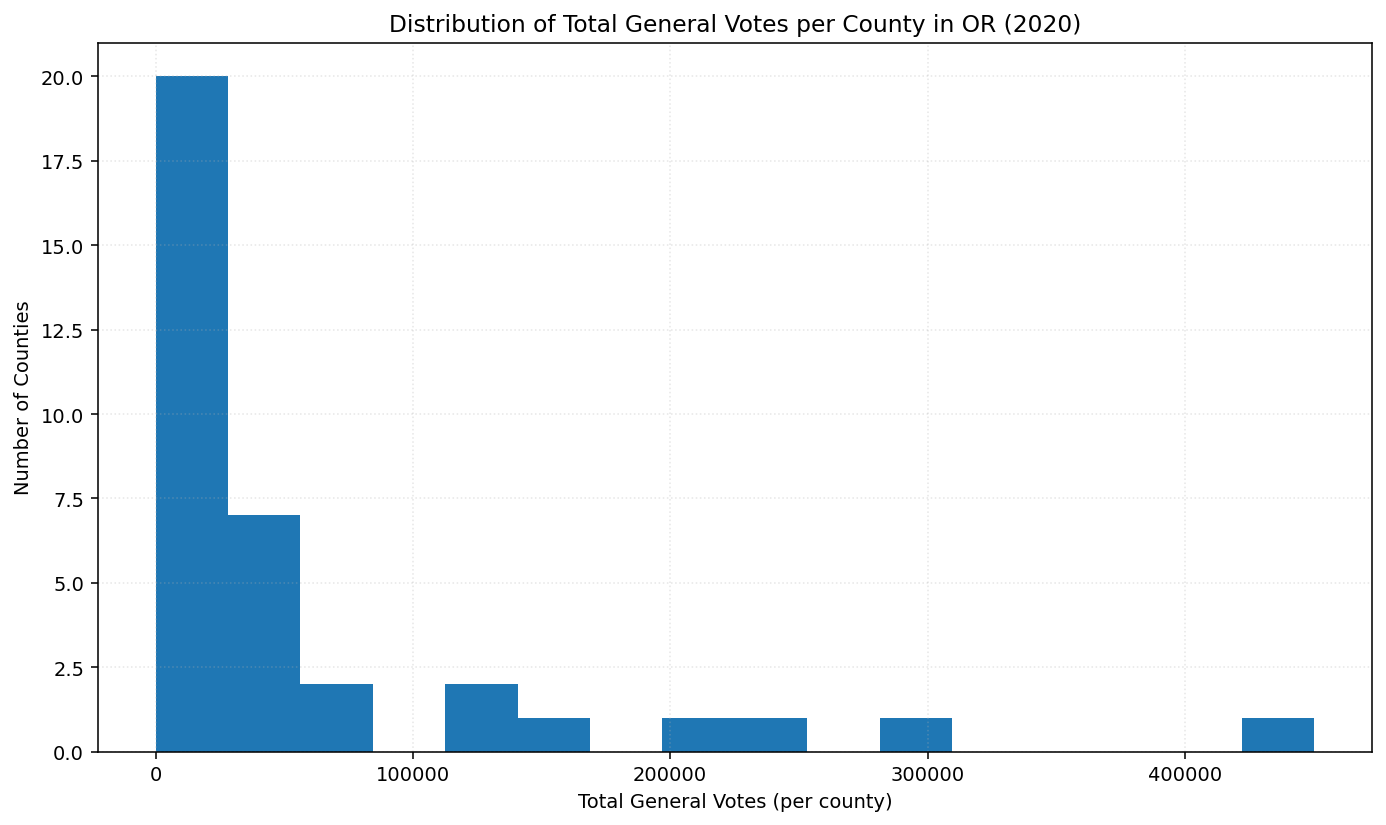

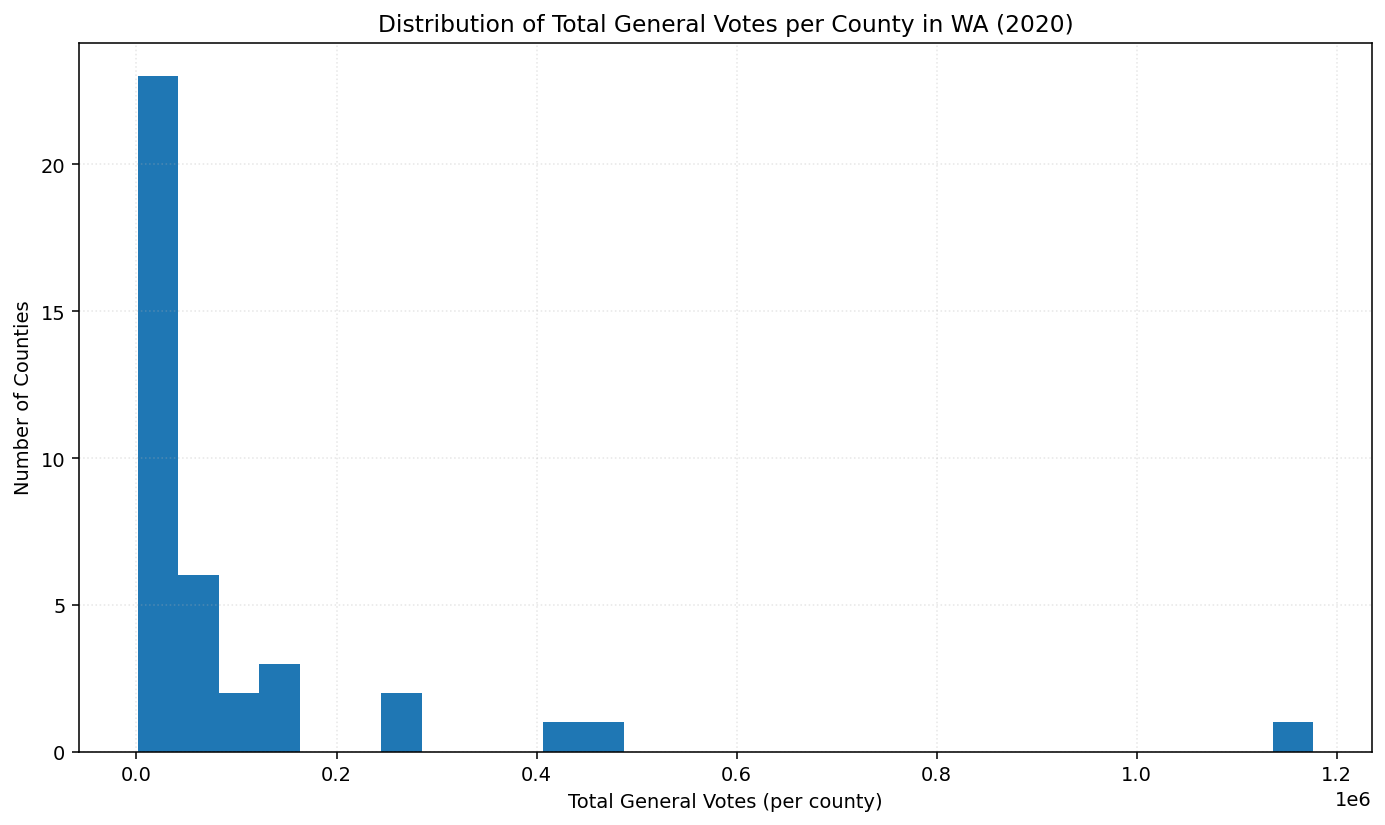

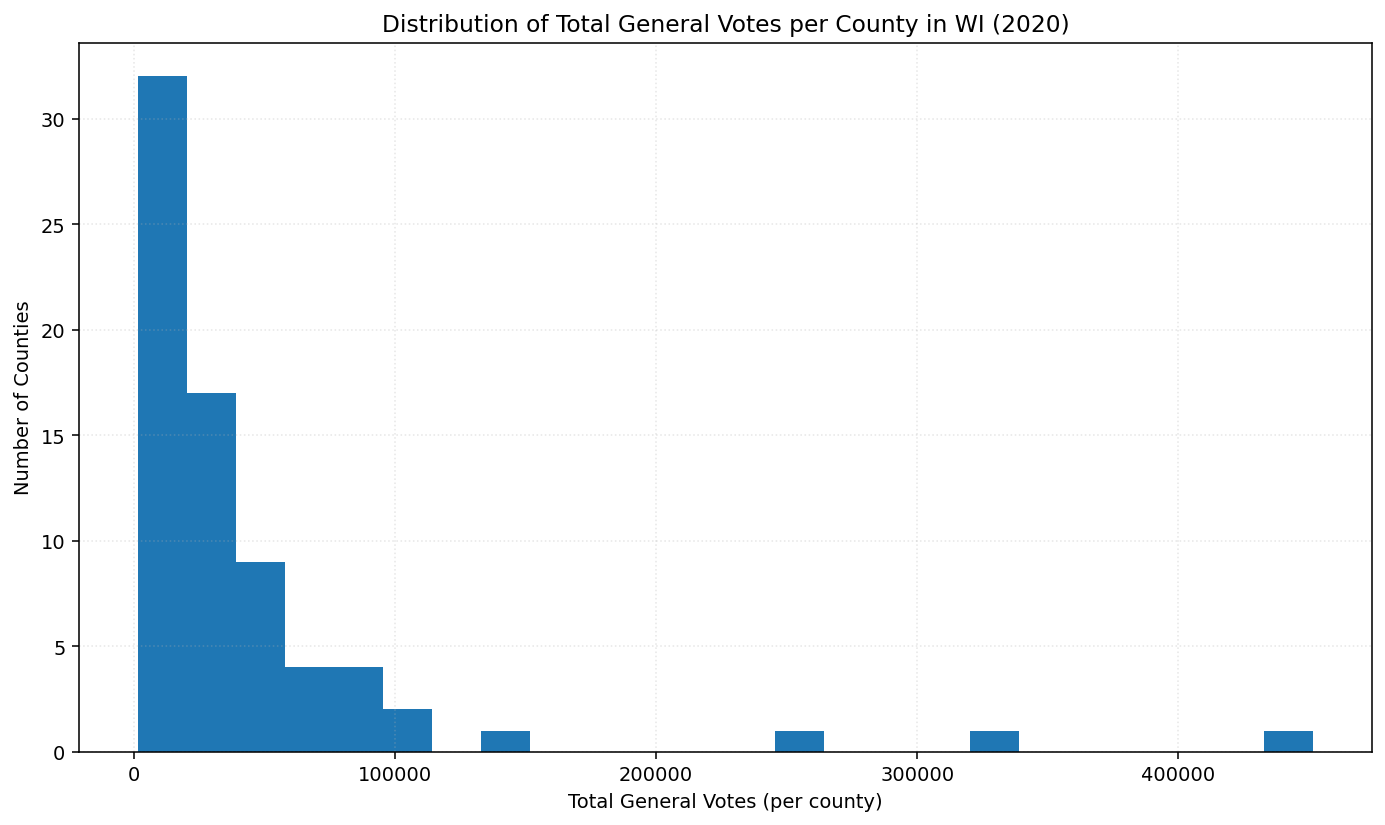

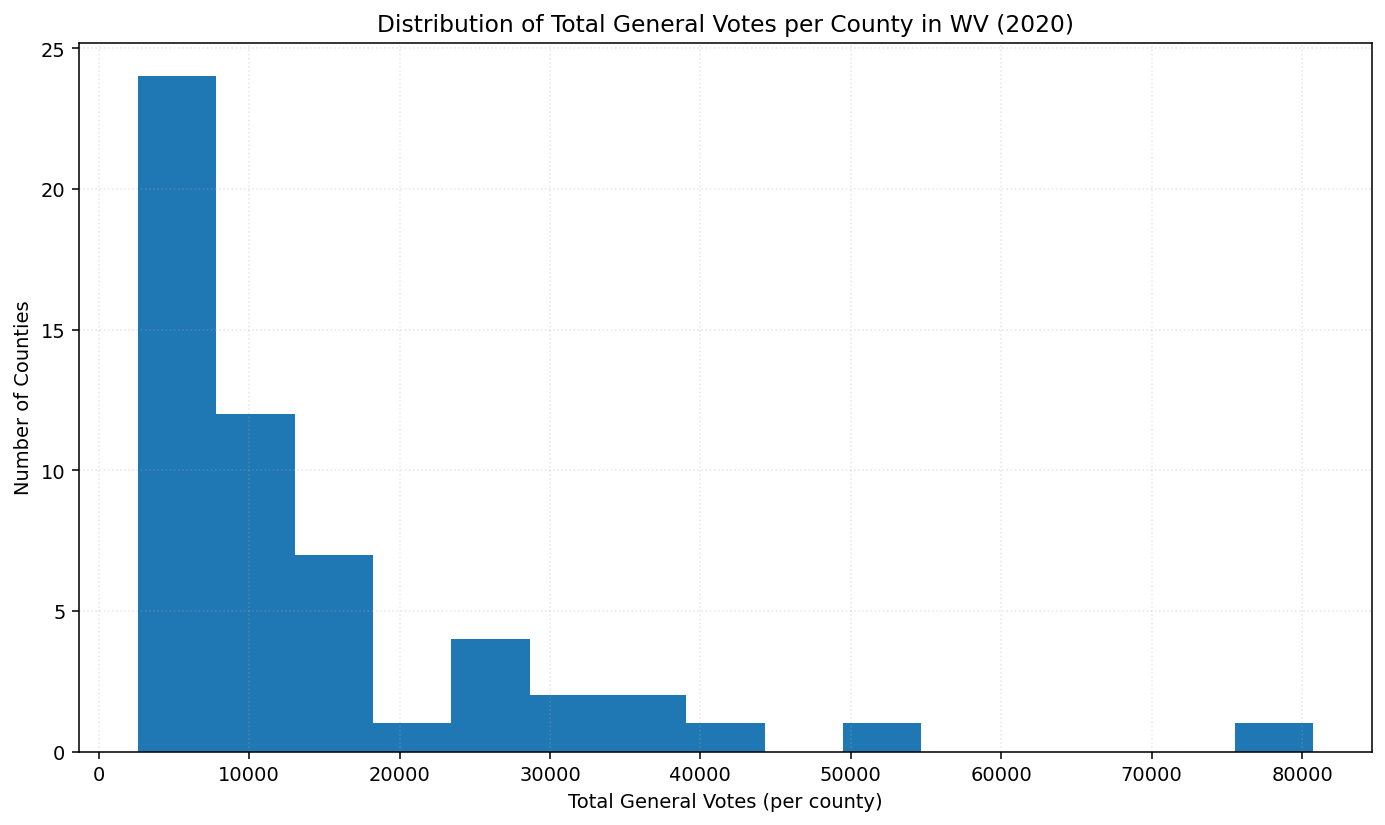

In [26]:
states_2020 = sorted(dt_2020['state'].unique())

for state in states_2020:
    state_df_2020 = dt_2020[dt_2020['state'] == state]
    data = state_df_2020['general_total_votes'].dropna().values
    if data.size == 0:
        continue
    bins = freedman_diaconis_bins(data)
    fig, ax = plt.subplots()
    ax.hist(data, bins=bins)
    ax.set_title(f'Distribution of Total General Votes per County in {state} (2020)')
    ax.set_xlabel('Total General Votes (per county)')
    ax.set_ylabel('Number of Counties')
    ax.grid(True, linestyle=':', alpha=0.3)
    plt.tight_layout()
    plt.show()

## 3. Voter Complacency Model: General-Election Multipliers

The multiplier model is deliberately simple and descriptive.

For each state-year, I take the two-party primary totals and two-party general totals and compute a **multiplier** for each party:

$$
    r_{\text{party}} = \frac{\text{general votes for that party}}{\text{primary votes for that party}}.
$$

Then I re-label each state-year into **primary winner** and **primary loser**:

- “Winner” = the party with higher total primary turnout in that state-year (Republican vs Democratic).
- “Loser” = the other party.

This gives me two ratios per state-year:

$$
    r^W = \frac{G^W}{P^W}, \qquad r^L = \frac{G^L}{P^L},
$$

and both ratios share the same x-axis value, the **primary margin** (absolute difference in two-party primary shares). Intuitively:

- If the winner is complacent when the primary is lopsided, I would expect **winner multipliers to stay flat or decline** as the primary margin grows.
- If the loser is “activated” by being behind (or if their primary is small because it’s uncontested), I would expect **loser multipliers to increase** with primary margin.

A huge caveat is that this ratio is sensitive to small denominators. If a party’s primary is essentially uncontested and turnout is tiny, the multiplier can become very large even if the general turnout is normal. I treat those as important observations, but I also interpret them carefully.


In [ ]:
def build_winner_loser_totals_2008(df_state_2008: pd.DataFrame):
    """Convert party-labeled state data into winner/loser totals for 2008.

    Returns:
      p_win_tot_2008, p_lose_tot_2008, g_win_tot_2008, g_lose_tot_2008,
      m_2008, state_names_2008
    """
    win_primary_tot_2008 = []
    lose_primary_tot_2008 = []
    win_general_tot_2008 = []
    lose_general_tot_2008 = []
    margins_2008 = []
    state_names_2008 = []

    for _, r in df_state_2008.iterrows():
        rep_p = r['rep_primary_total']
        dem_p = r['dem_primary_total']
        rep_g = r['rep_general_total']
        dem_g = r['dem_general_total']
        margin = r['primary_margin']

        if rep_p > dem_p:
            win_primary_tot_2008.append(rep_p)
            lose_primary_tot_2008.append(dem_p)
            win_general_tot_2008.append(rep_g)
            lose_general_tot_2008.append(dem_g)
        else:
            win_primary_tot_2008.append(dem_p)
            lose_primary_tot_2008.append(rep_p)
            win_general_tot_2008.append(dem_g)
            lose_general_tot_2008.append(rep_g)

        margins_2008.append(margin)
        state_names_2008.append(r['state'])

    return (
        np.array(win_primary_tot_2008),
        np.array(lose_primary_tot_2008),
        np.array(win_general_tot_2008),
        np.array(lose_general_tot_2008),
        np.array(margins_2008),
        np.array(state_names_2008),
    )

The multiplier model needs a consistent way to define “winner” and “loser.” This helper function does that for 2008 by comparing the two-party *primary* totals: whichever party has the larger primary total becomes the “winner,” and I carry that label forward so that `P^W` pairs with `G^W` for the same party. The function returns NumPy arrays so the next steps (ratios, regressions, plotting) are vectorized.


In [1]:
def build_winner_loser_totals_2016(df_state_2016: pd.DataFrame):
    """Convert party-labeled state data into winner/loser totals for 2016.

    Returns:
      p_win_tot_2016, p_lose_tot_2016, g_win_tot_2016, g_lose_tot_2016,
      m_2016, state_names_2016
    """
    win_primary_tot_2016 = []
    lose_primary_tot_2016 = []
    win_general_tot_2016 = []
    lose_general_tot_2016 = []
    margins_2016 = []
    state_names_2016 = []

    for _, r in df_state_2016.iterrows():
        rep_p = r['rep_primary_total']
        dem_p = r['dem_primary_total']
        rep_g = r['rep_general_total']
        dem_g = r['dem_general_total']
        margin = r['primary_margin']

        if rep_p > dem_p:
            win_primary_tot_2016.append(rep_p)
            lose_primary_tot_2016.append(dem_p)
            win_general_tot_2016.append(rep_g)
            lose_general_tot_2016.append(dem_g)
        else:
            win_primary_tot_2016.append(dem_p)
            lose_primary_tot_2016.append(rep_p)
            win_general_tot_2016.append(dem_g)
            lose_general_tot_2016.append(rep_g)

        margins_2016.append(margin)
        state_names_2016.append(r['state'])

    return (
        np.array(win_primary_tot_2016),
        np.array(lose_primary_tot_2016),
        np.array(win_general_tot_2016),
        np.array(lose_general_tot_2016),
        np.array(margins_2016),
        np.array(state_names_2016),
    )

NameError: name 'pd' is not defined

This is the 2016 version of the same winner/loser relabeling logic. The structure is identical; the only reason it is separate is naming clarity in the notebook. (In practice, the function works year-agnostically as long as the input has the same columns.)


In [29]:
# Build winner/loser totals and multipliers for 2008, 2016, and 2020
p_win_tot_2008, p_lose_tot_2008, g_win_tot_2008, g_lose_tot_2008, m_mult_2008, state_names_2008 = (
    build_winner_loser_totals_2008(state_2008)
)
p_win_tot_2016, p_lose_tot_2016, g_win_tot_2016, g_lose_tot_2016, m_mult_2016, state_names_2016 = (
    build_winner_loser_totals_2016(state_2016)
)
p_win_tot_2020, p_lose_tot_2020, g_win_tot_2020, g_lose_tot_2020, m_mult_2020, state_names_2020 = (
    build_winner_loser_totals_2016(state_2020)
)

After relabeling, I now have (for each year) three aligned arrays across states: `P^W` and `P^L` (primary totals), `G^W` and `G^L` (general totals), and the primary margin `x`. The state name array lets me label points later so I can identify outliers instead of treating them as anonymous dots.


In [30]:
# Calculate turnout ratios
r_win_2008 = g_win_tot_2008 / p_win_tot_2008
r_lose_2008 = g_lose_tot_2008 / p_lose_tot_2008
r_win_2016 = g_win_tot_2016 / p_win_tot_2016
r_lose_2016 = g_lose_tot_2016 / p_lose_tot_2016
r_win_2020 = g_win_tot_2020 / p_win_tot_2020
r_lose_2020 = g_lose_tot_2020 / p_lose_tot_2020

# Calculate absolute margins
x_2008 = np.abs(m_mult_2008)
x_2016 = np.abs(m_mult_2016)
x_2020 = np.abs(m_mult_2020)

The multipliers are computed as simple ratios: general votes divided by primary votes, separately for the primary winner and primary loser. The x-axis value is the absolute primary margin. Importantly, each state contributes **two** multiplier points (winner and loser) at the same margin value.


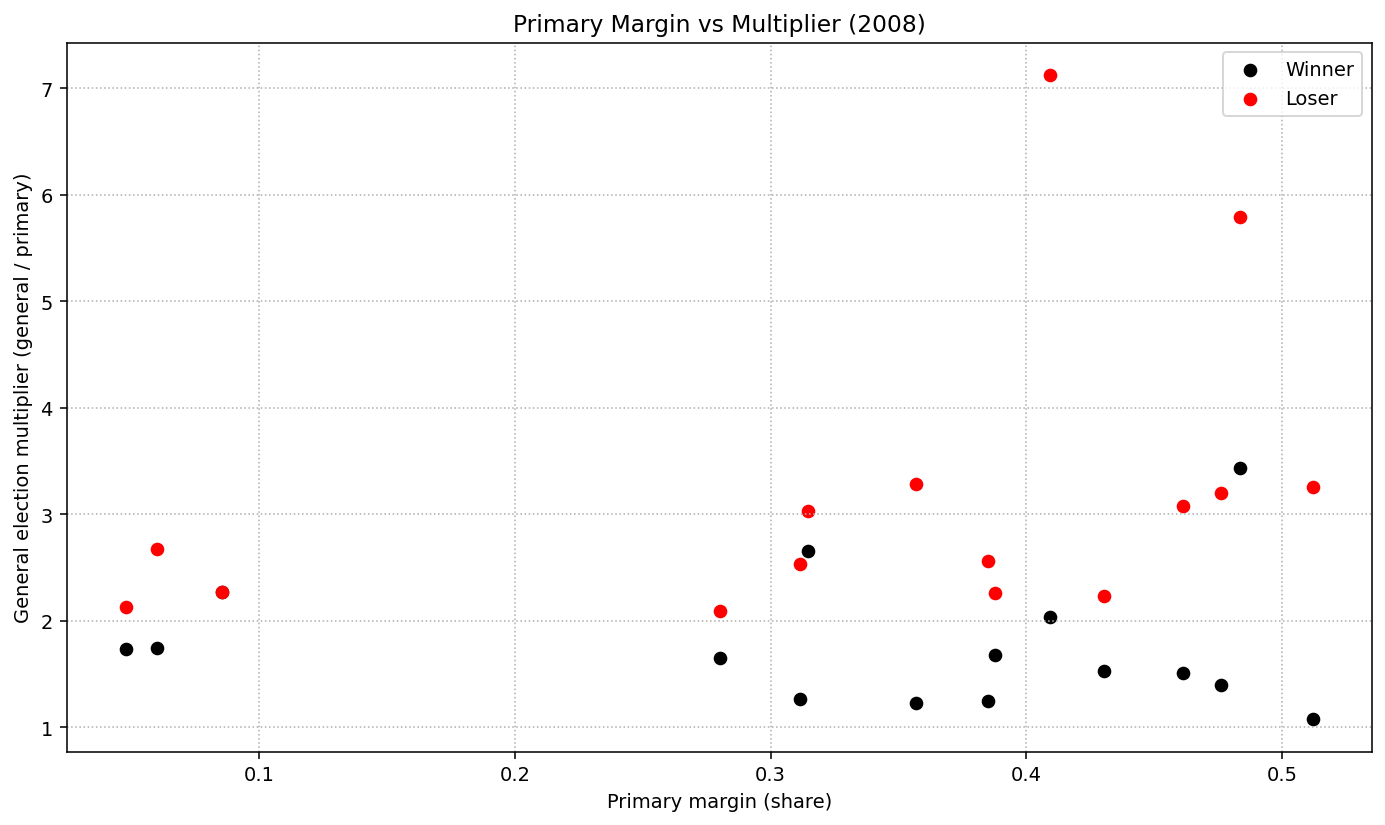

In [31]:
# Plot multipliers vs margin for 2008
plt.figure()
plt.scatter(x_2008, r_win_2008, label='Winner', color = "black")
plt.scatter(x_2008, r_lose_2008, label='Loser', color = "red")
plt.xlabel('Primary margin (share)')
plt.ylabel('General election multiplier (general / primary)')
plt.title('Primary Margin vs Multiplier (2008)')
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

Winner multipliers (black) mostly sit in a relatively narrow band (roughly around 1–2.5) and look close to flat as margin increases. Loser multipliers (red) are typically higher and rise with margin, and a couple of states are extreme outliers (notably **LA** and **ID** on the loser side, with multipliers well above 5). Those extreme red points are almost always the “tiny primary denominator” story: one party’s primary turnout is extremely small, but their general-election vote is still meaningful.

Directionally, this matches the narrative: in lopsided-primary states, the side that dominated the primary does not expand dramatically into the general, while the weaker primary side often expands more. I treat the outliers as substantively interesting (they represent real political structure like uncontested primaries), but I also remember that they can disproportionately influence the fitted slope.

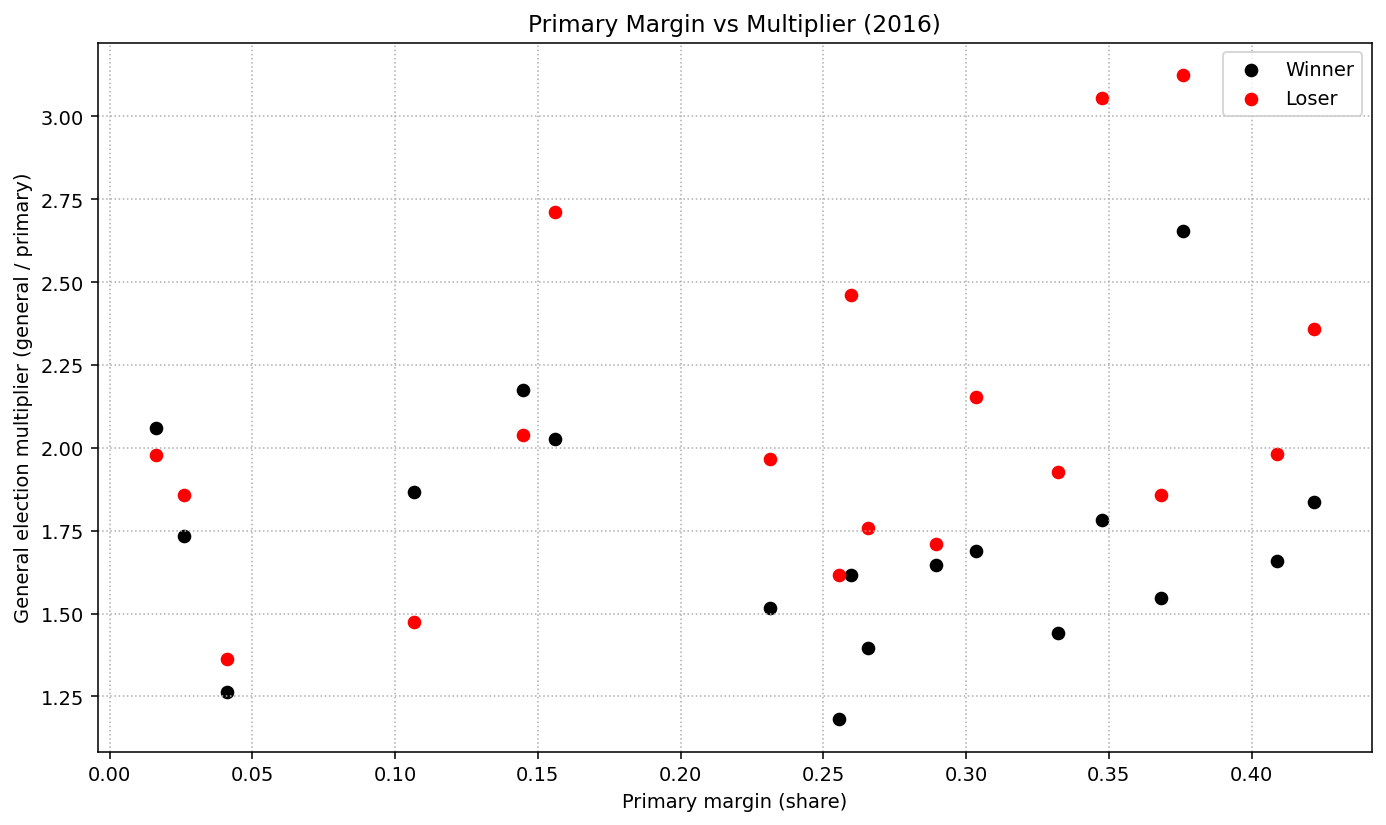

In [32]:
# Plot multipliers vs margin for 2016
plt.figure()
plt.scatter(x_2016, r_win_2016, label='Winner', color = "black")
plt.scatter(x_2016, r_lose_2016, label='Loser', color = "red")
plt.xlabel('Primary margin (share)')
plt.ylabel('General election multiplier (general / primary)')
plt.title('Primary Margin vs Multiplier (2016)')
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

The overall spread in 2016 is tighter than 2008: both winner and loser multipliers cluster more narrowly. The loser series still shows a tendency to rise with primary margin, but the pattern is less dramatic, and there are fewer extreme outliers.

A tighter spread means the general-to-primary scaling is more stable across states. If I still see loser multipliers increasing with primary margin, that suggests the effect (or the mechanism driving it, like uncontested primaries) persists, but it’s weaker or more constrained in 2016 than in 2008.


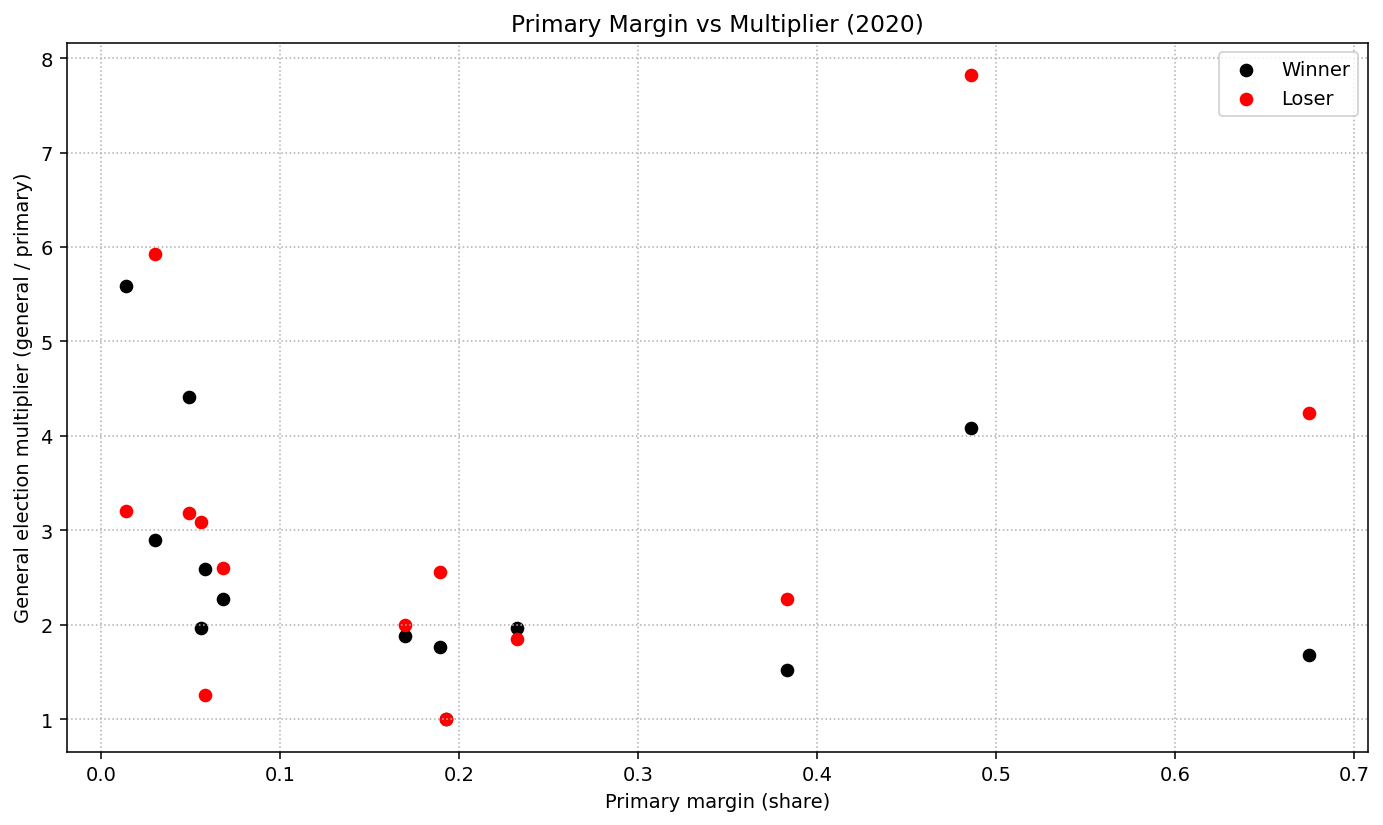

In [33]:
# Plot multipliers vs margin for 2020
plt.figure()
plt.scatter(x_2020, r_win_2020, label='Winner', color = "black")
plt.scatter(x_2020, r_lose_2020, label='Loser', color = "red")
plt.xlabel('Primary margin (share)')
plt.ylabel('General election multiplier (general / primary)')
plt.title('Primary Margin vs Multiplier (2020)')
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

The 2020 scatter shows noticeably larger dispersion, including very large loser multipliers and some large winner multipliers as well. This is exactly the year where uncontested primaries (especially on the incumbent side) and unusual general-election turnout can combine to make \(G/P\) ratios explode.

A strong upward pattern for loser multipliers with margin can still be consistent with the story “the losing side scales up more,” but in 2020 I’m especially careful: a huge multiplier can be driven by administrative/competitive structure (a tiny primary) rather than any behavioral complacency. This is where the labeled/fitted plots below become useful because I can identify which specific states are driving the slope.

In [34]:
# Linear shared-intercept model for multipliers (linear scale)
# For each state-year, we create two rows:
#   Winner: r^W = a + b x + error  -> features [1, x, 0]
#   Loser:  r^L = a + (b + d) x + error -> features [1, x, x]
def fit_linear_multiplier_model(x, r_win, r_lose):
    X_win = np.column_stack([np.ones_like(x), x, np.zeros_like(x)])
    X_lose = np.column_stack([np.ones_like(x), x, x])
    X = np.vstack([X_win, X_lose])
    y = np.concatenate([r_win, r_lose])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    a, b, d = beta
    slope_win = b
    slope_lose = b + d
    return a, slope_win, slope_lose

To summarize the scatter plots quantitatively, I fit a simple linear model with a shared intercept:

$$
r^W = a + b_W x, \qquad r^L = a + b_L x.
$$

I implement this as one least-squares system by stacking winner and loser observations with different feature columns. The shared intercept \(a\) represents the “baseline” multiplier when the primary margin is near 0 (a balanced primary), while the two slopes capture how winner and loser multipliers change as primaries become more lopsided.


In [35]:
# Fit linear multiplier model for 2008 
a_2008, slope_win_2008, slope_lose_2008 = fit_linear_multiplier_model(x_2008, r_win_2008, r_lose_2008)
print('Model 2 (linear, 2008):')
print(f'  Intercept = {a_2008:.3f}')
print(f'  Slope (winner) = {slope_win_2008:.3f}')
print(f'  Slope (loser)  = {slope_lose_2008:.3f}')

Model 2 (linear, 2008):
  Intercept = 1.893
  Slope (winner) = -0.380
  Slope (loser)  = 3.816


For 2008, the fitted coefficients are:

- Intercept $a\approx 1.893$.  
- Winner slope $b_W\approx -0.380$: increasing margin by 0.10 is associated with about a $-0.038$ change in the winner multiplier.  
- Loser slope $b_L\approx 3.816$: increasing margin by 0.10 is associated with about a $$+0.382$ change in the loser multiplier.

So the winner line is slightly downward, while the loser line rises strongly. That matches what the raw scatter already suggested: as primaries become more one-sided, the losing side tends to have a much larger general/primary “scale-up” than the winning side.


In [36]:
# Fit linear multiplier model for 2016
a_2016, slope_win_2016, slope_lose_2016 = fit_linear_multiplier_model(x_2016, r_win_2016, r_lose_2016)
print('Model 2 (linear, 2016):')
print(f'  Intercept = {a_2016:.3f}')
print(f'  Slope (winner) = {slope_win_2016:.3f}')
print(f'  Slope (loser)  = {slope_lose_2016:.3f}')

Model 2 (linear, 2016):
  Intercept = 1.713
  Slope (winner) = 0.045
  Slope (loser)  = 1.523


For 2016, the fitted coefficients are:

- Intercept $a\approx 1.713$.  
- Winner slope $b_W\approx 0.045$: essentially flat (a +0.0045 change per 0.10 margin).  
- Loser slope $b_L\approx 1.523$: positive (+0.152 change per 0.10 margin).

This is a weaker version of the 2008 pattern. The loser multiplier still increases with margin, but the winner multiplier is basically constant with respect to the primary margin.

In [37]:
# Fit linear multiplier model for 2020
a_2020, slope_win_2020, slope_lose_2020 = fit_linear_multiplier_model(x_2020, r_win_2020, r_lose_2020)
print('Model 2 (linear, 2020):')
print(f'  Intercept = {a_2020:.3f}')
print(f'  Slope (winner) = {slope_win_2020:.3f}')
print(f'  Slope (loser)  = {slope_lose_2020:.3f}')

Model 2 (linear, 2020):
  Intercept = 2.739
  Slope (winner) = -1.313
  Slope (loser)  = 2.637


For 2020, the fitted coefficients are:

- Intercept $a\approx 2.739$.  
- Winner slope $b_W\approx -1.313$: a fairly strong downward relationship (about −0.131 per 0.10 margin).  
- Loser slope $b_L\approx 2.637$: upward (+0.264 per 0.10 margin).

This is the clearest “split” across winner vs loser slopes in the notebook: the winner line slopes down, and the loser line slopes up. Given how sensitive 2020 multipliers can be to uncontested primaries, the next step is to look at the labeled fitted plot and see which states are contributing most to those slopes.


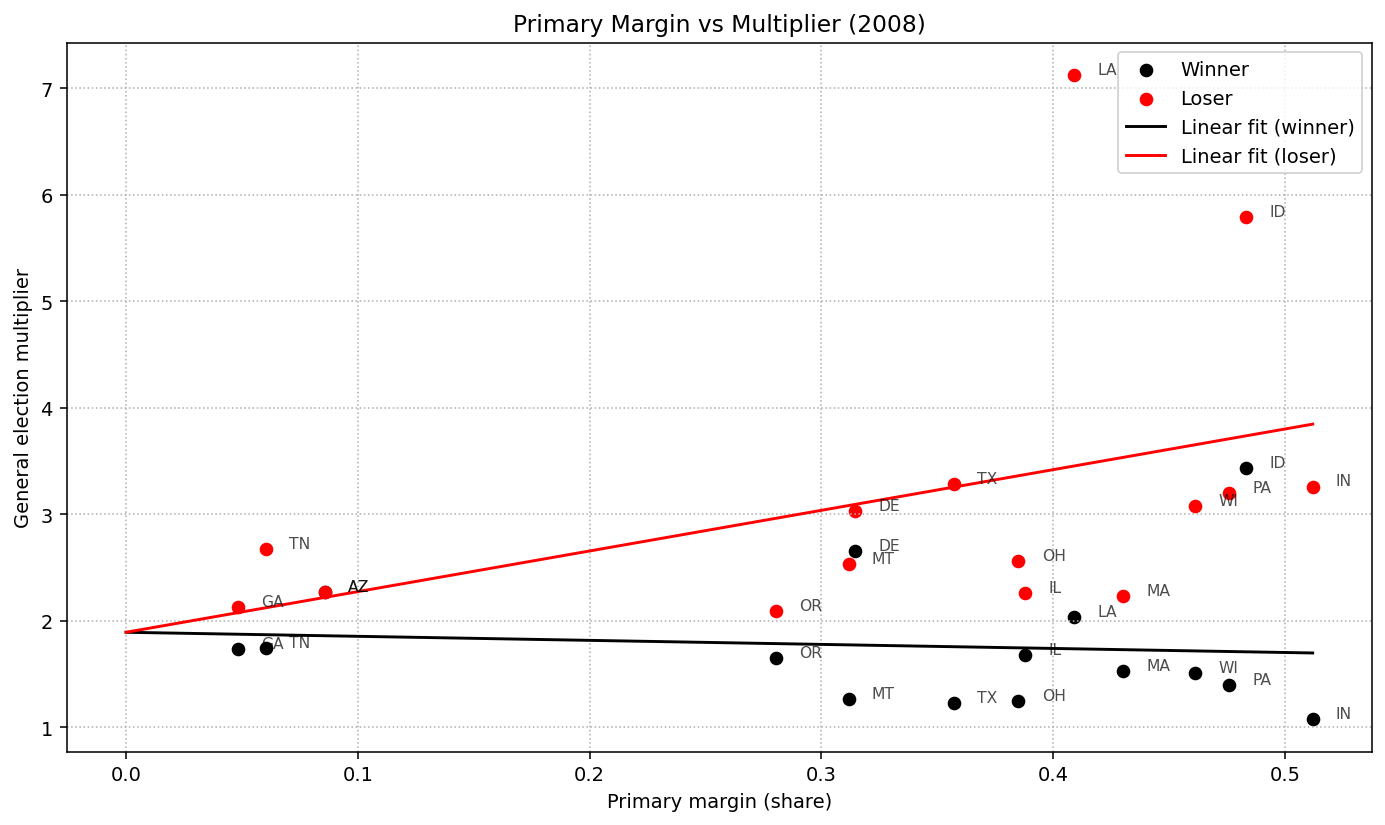

In [43]:
# Plot fitted lines for 2008
xs_2008 = np.linspace(0.0, x_2008.max(), 200)
fit_win_2008 = a_2008 + slope_win_2008 * xs_2008
fit_lose_2008 = a_2008 + slope_lose_2008 * xs_2008

plt.figure()
plt.scatter(x_2008, r_win_2008, label='Winner', color = "black")
plt.scatter(x_2008, r_lose_2008, label='Loser', color = "red")

# Add labels
for x, y, s in zip(x_2008, r_win_2008, state_names_2008):
    plt.text(x + 0.01, y + 0.01, s, fontsize=8, alpha=0.7)

for x, y, s in zip(x_2008, r_lose_2008, state_names_2008):
    plt.text(x + 0.01, y + 0.01, s, fontsize=8, alpha=0.7)
    
plt.plot(xs_2008, fit_win_2008, label='Linear fit (winner)', color = "black")
plt.plot(xs_2008, fit_lose_2008, label='Linear fit (loser)', color = "red")
plt.xlabel('Primary margin (share)')
plt.ylabel('General election multiplier')
plt.title('Primary Margin vs Multiplier (2008)')
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

Adding labels makes it clear that a couple of states sit far above the rest on the loser side. In this plot, **LA** and **ID** are the clearest examples: their loser multipliers are so large that they can heavily influence the red fitted line.

Even with those outliers, the qualitative separation between the black and red fitted lines is meaningful. The loser line rises with margin, while the winner line is flat-to-slightly-down. So the “average” pattern in 2008 is: **as the primary becomes more lopsided, the primary-loser party tends to scale up more from primary to general than the primary-winner party does.**


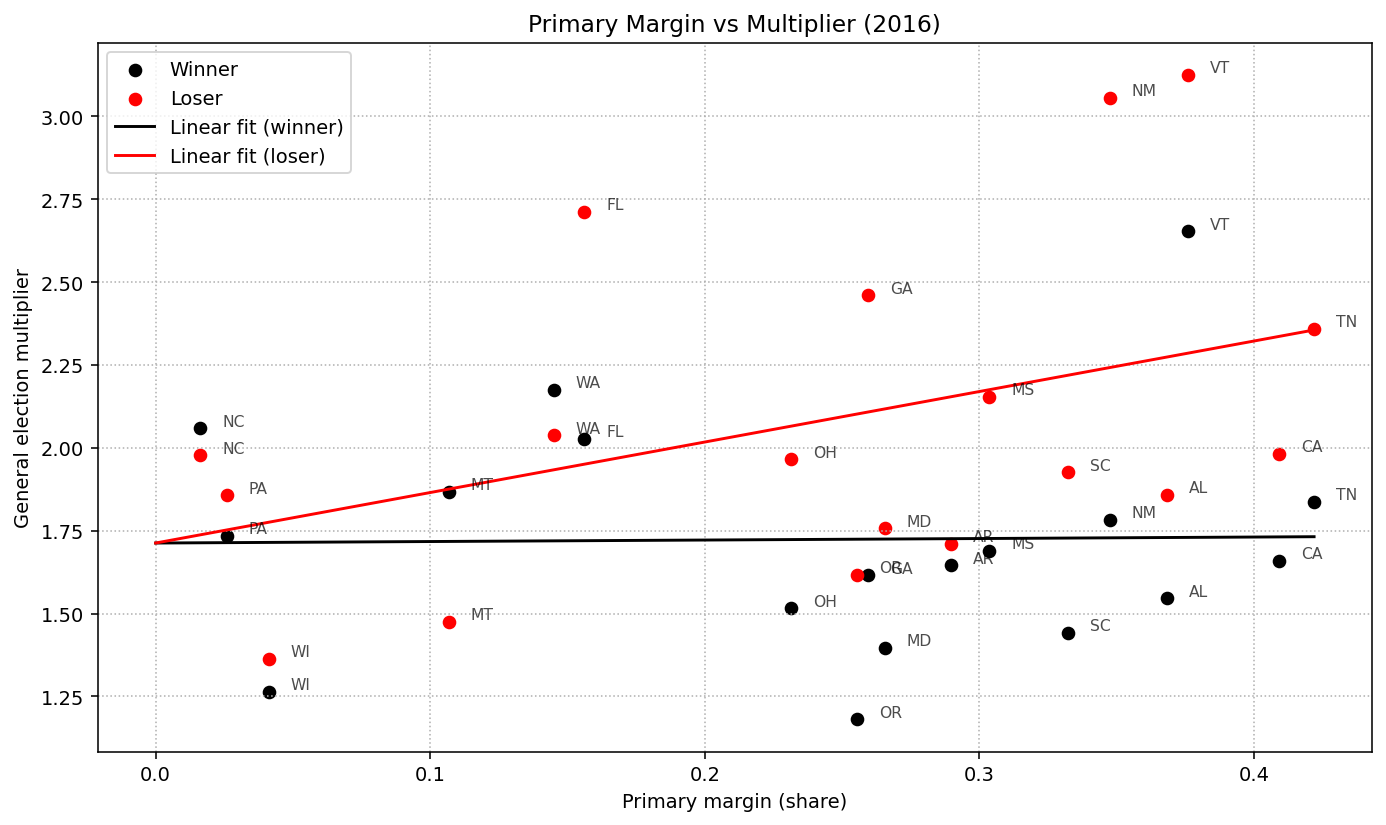

In [42]:
# Plot fitted lines for 2016
xs_2016 = np.linspace(0.0, x_2016.max(), 200)
fit_win_2016 = a_2016 + slope_win_2016 * xs_2016
fit_lose_2016 = a_2016 + slope_lose_2016 * xs_2016

plt.figure()
plt.scatter(x_2016, r_win_2016, label='Winner', color = "black")
plt.scatter(x_2016, r_lose_2016, label='Loser', color = "red")

# Add labels
for x, y, s in zip(x_2016, r_win_2016, state_names_2016):
    plt.text(x + 0.008, y + 0.008, s, fontsize=8, alpha=0.7)

for x, y, s in zip(x_2016, r_lose_2016, state_names_2016):
    plt.text(x + 0.008, y + 0.008, s, fontsize=8, alpha=0.7)

plt.plot(xs_2016, fit_win_2016, label='Linear fit (winner)', color = "black")
plt.plot(xs_2016, fit_lose_2016, label='Linear fit (loser)', color = "red")
plt.xlabel('Primary margin (share)')
plt.ylabel('General election multiplier')
plt.title('Primary Margin vs Multiplier (2016)')
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

The labeled plot reinforces that 2016 is “compressed”: most states sit between multipliers of roughly 1.3 and 2.3, with only a few pushing above 3. Two loser-side states stand out at the high end (**VT** and **NM**), and the winner-side dispersion is still moderate (for example, **OR** is relatively low on the winner side compared to many others).

The fitted lines summarize this well: the loser line slopes upward, but less steeply than 2008, while the winner line is nearly horizontal. Substantively, this looks like a year where “primary dominance” does not translate into a decreasing winner multiplier the way it does in 2008/2020; the loser scaling effect remains, but winner complacency is not as visually strong in this linear summary.


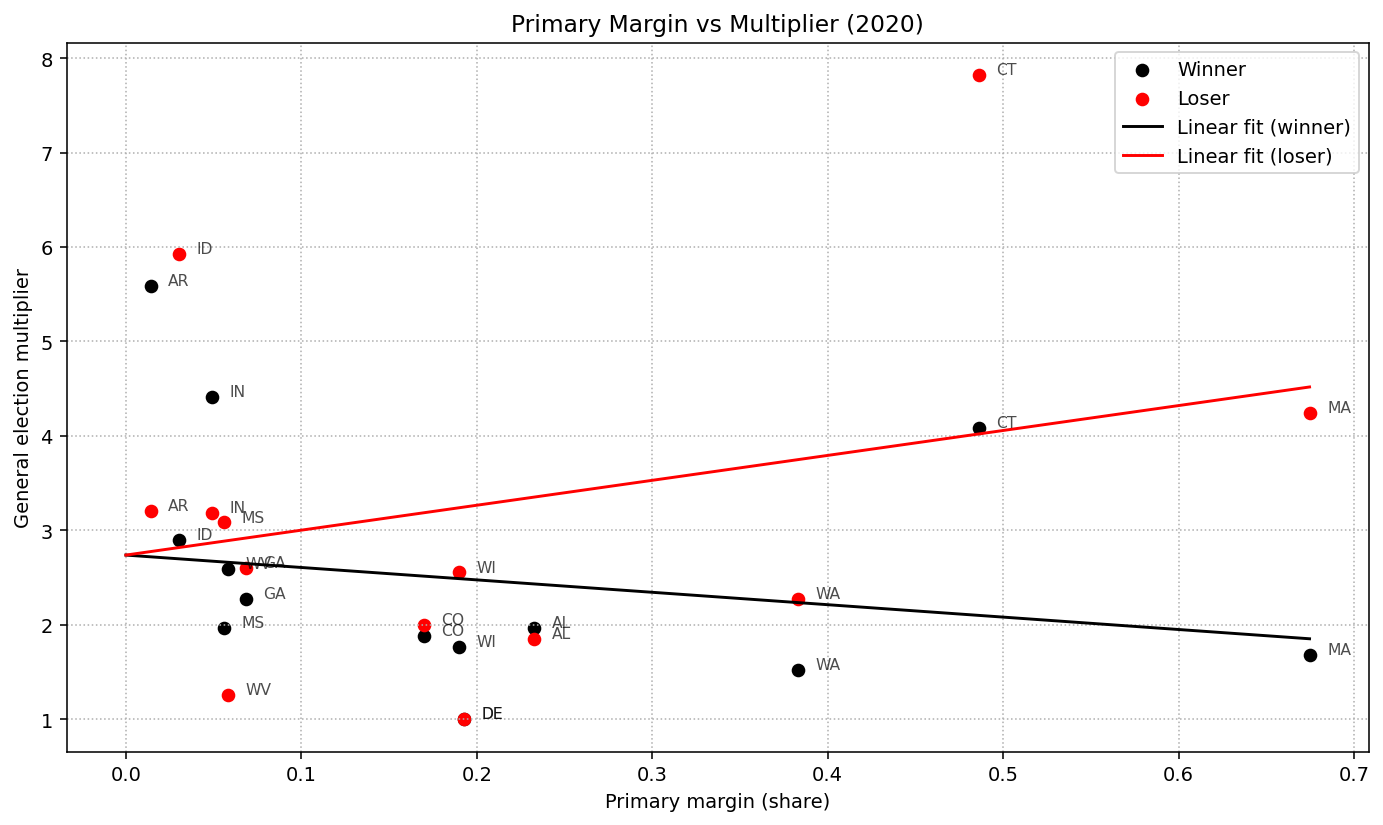

In [41]:
# Plot fitted lines for 2020
xs_2020 = np.linspace(0.0, x_2020.max(), 200)
fit_win_2020 = a_2020 + slope_win_2020 * xs_2020
fit_lose_2020 = a_2020 + slope_lose_2020 * xs_2020

plt.figure()
plt.scatter(x_2020, r_win_2020, label='Winner', color = "black")
plt.scatter(x_2020, r_lose_2020, label='Loser', color = "red")

# Add labels
for x, y, s in zip(x_2020, r_win_2020, state_names_2020):
    plt.text(x + 0.01, y + 0.01, s, fontsize=8, alpha=0.7)

for x, y, s in zip(x_2020, r_lose_2020, state_names_2020):
    plt.text(x + 0.01, y + 0.01, s, fontsize=8, alpha=0.7)

plt.plot(xs_2020, fit_win_2020, label='Linear fit (winner)', color = "black")
plt.plot(xs_2020, fit_lose_2020, label='Linear fit (loser)', color = "red")
plt.xlabel('Primary margin (share)')
plt.ylabel('General election multiplier')
plt.title('Primary Margin vs Multiplier (2020)')
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

This is the figure where the 2020 coefficient split becomes interpretable. A few states have extremely large loser multipliers: **CT** is the most obvious here, with other large values like **ID** on the loser side and **AR** on the winner side. These are exactly the situations where one party’s primary is close to uncontested (small $P$) while the general election still draws a normal-sized electorate (large $G$), making $G/P$ huge.

At the same time, the downward winner slope is visible: as margin increases, winner multipliers tend to drift downward. In other words, in the most lopsided-primary states, the dominant primary side often does *not* “scale up” as much into the general, while the weaker primary side sometimes scales up dramatically. If I interpret this through the complacency lens, 2020 gives the strongest visual separation between winner and loser trends.

Because 2020 is unusual (turnout, mail voting, uncontested primaries, etc.), I treat this as evidence of a pattern worth explaining rather than a final causal conclusion. A natural next robustness step is to re-fit on $\log r$ or to winsorize extreme ratios so that the overall trend is not driven by tiny-primary denominators.
